# Hausse de loyer Équinoxe : notebook de départ

**Votre tâche : estimer la hausse de loyer d'Équinoxe pour 2026.**

### CodeML 2026 - Yummy crunch

## 1. Charger les données

## 1b. Lire les colonnes : champs `h` et champs `s`

Chaque colonne de ce jeu commence par **`h`** ou **`s`**. C'est la convention de Yardi, et
se tromper là-dessus est la façon la plus courante de corrompre une requête de gestion immobilière.

| préfixe | signification | exemple | à quoi ça sert |
|---|---|---|---|
| **`h`** | **handle** (identifiant) - une clé numérique | `hUnit`, `hProperty`, `hBuilding` | **les jointures**. Opaque, stable, unique. |
| **`s`** | **stored value** (valeur stockée) - ce qu'un humain lit | `sUnitCode`, `sRent`, `sBuilding` | **l'affichage et le regroupement**. |

Yardi conserve les deux moitiés d'une même information côte à côte - `hAgent` à côté de `sAgent`,
`hProperty` à côté de `sPropCode`. Elles ne sont **pas interchangeables** :

> **Joindre sur `h`. Étiqueter avec `s`.**

Ce n'est pas du pinaillage, c'est tout l'objet de la section 4 ci-dessous. `sUnitCode` vaut `"0203"` - et
trois appartements différents sur un même site portent cette même chaîne. `hUnit` est unique par
construction. Si vous associez une unité à elle-même du côté `s`, vous fusionnez des appartements sans le savoir;
si vous associez sur `hUnit`, c'est impossible.

**Deux mises en garde sur `s`, qui reflètent toutes deux le vrai comportement de Yardi, pas des particularités de ce jeu :**

1. **`s` ne veut pas dire « string ».** La table `UNIT` de Yardi stocke `SRENT` et `DSQFT` comme
   *valeurs numériques*. Ici, `sRent` et `sSqft` sont des nombres. Ne déduisez pas un type d'un préfixe -
   vérifiez-le.
2. **Le vrai Yardi subdivise davantage le côté `s`** - `dt*` pour les dates (`dtLeaseFrom`), `d*`
   pour les doubles (`dSqft`), `i*` pour les entiers, `b*` pour les indicateurs. Ce jeu les ramène tous
   à `s` pour garder l'attention sur la distinction `h` / `s`. Quand vous ouvrirez la vraie base de données, attendez-vous
   à un alphabet plus long.

### Les codes de frais

`sChargeCode` dans le fichier des concessions correspond au plan comptable de Yardi. Les codes semblent abîmés
parce que `sCode` est un `nchar(8)` - « Free other » devient `Freeothe`, « Referencing » devient
`Referenc`. Huit caractères, tronqués, avec une casse incohérente. C'est à ça que ressemblent les vrais.

| `sChargeCode` | `sChargeDesc` | ce que c'est réellement |
|---|---|---|
| `PromoPay` | Promo - Payable in the future | Un rabais promotionnel. **Lisez la mise en garde ci-dessous.** |
| `freerent` | Free rent | Loyer annulé pour une partie du bail. |
| `freepark` | Free Parking | Frais de stationnement annulés. Un avantage *accessoire*, pas du loyer. |
| `freelock` | Free Locker | Casier de rangement offert. Accessoire. |
| `freeappl` | Free Appliances | Frais d'électroménagers annulés. Accessoire. |
| `Freeothe` | Free other | Tout ce qui n'est pas catégorisé. À traiter avec méfiance. |
| `Indem` | Client indemnity | Un paiement versé au résident, par exemple pour régler un différend. |
| `Referenc` | Referencing program | Un crédit de référencement. |

**Celui qu'il faut examiner avant de s'y fier :** `PromoPay` est décrit comme un frais
mensuel. Ce n'en est pas un. Il est très majoritairement inscrit sur un seul mois, pour un montant proche d'un mois
de loyer complet. Prenez la description au pied de la lettre et vous conclurez que les résidents habitent
presque gratuitement. Comparez `sMonths` et la taille de `sAmount` à `sRent` avant de le modéliser -
et décidez vous-même comment l'étaler sur la durée du bail.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

listings   = pd.read_csv("equinoxe_listings.csv")
leases     = pd.read_csv("equinoxe_lease_history.csv")
concessions= pd.read_csv("equinoxe_concessions.csv")
asking     = pd.read_csv("equinoxe_asking_history.csv")

for name, df in [("listings", listings), ("leases", leases),
                 ("concessions", concessions), ("asking", asking)]:
    print(f"{name:<12} {len(df):>6,} lignes   {df.shape[1]:>2} colonnes")

listings      1,061 lignes   29 colonnes
leases        4,302 lignes   35 colonnes
concessions   3,560 lignes   18 colonnes
asking        3,857 lignes   14 colonnes


In [2]:
# Convertir les dates une seule fois, dès le départ.
for col in ["sLeaseFrom", "sLeaseTo", "sSignDate", "sAvailable"]:
    if col in leases.columns:
        leases[col] = pd.to_datetime(leases[col], errors="coerce")

leases["year"] = leases.sLeaseFrom.dt.year
asking["date"] = pd.to_datetime(asking.sMonth + "-01")

leases.head(3)

,hProperty,hUnit,hBuilding,sPropCode,sUnitCode,sBuilding,sCity,sState,sAddr1,sLatitude,sLongitude,sLeaseTerm,sPropType,sRent,sBeds,sBaths,sSqft,sLink,sFurnishing,sAvailable,sSmoking,sCats,sDogs,sRentEffective,sConcession,sSite,sUnitSubtype,sUnitType,sSignDate,sLeaseFrom,sLeaseTo,sTermMonths,sTermSeq,sRenewal,sFloor,year
0,100,4001,11,carlyle,0102,Le Carlyle,Mont-Royal,Quebec,815 Av. Plymouth,45.505554,-73.661842,Long Term,Apartment,1070,1,1.0,530,/rental/qc/mont-royal/carlyle/0102,Unfurnished,2023-04-01,Non-Smoking,True,True,993.08,1,le-carlyle,1 Bed,1_1d,2023-01-24,2023-04-01,2024-03-30,12.0,1,0,1,2023
1,100,4001,11,carlyle,0102,Le Carlyle,Mont-Royal,Quebec,815 Av. Plymouth,45.505554,-73.661842,Long Term,Apartment,1110,1,1.0,530,/rental/qc/mont-royal/carlyle/0102,Unfurnished,2024-05-27,Non-Smoking,True,True,1020.93,1,le-carlyle,1 Bed,1_1d,2024-05-09,2024-05-27,2025-05-26,12.0,2,1,1,2024
2,100,4001,11,carlyle,0102,Le Carlyle,Mont-Royal,Quebec,815 Av. Plymouth,45.505554,-73.661842,Negotiable,Apartment,1180,1,1.0,530,/rental/qc/mont-royal/carlyle/0102,Unfurnished,2025-05-27,Non-Smoking,True,True,1048.12,1,le-carlyle,1 Bed,1_1d,2025-04-26,2025-05-27,2026-05-26,12.0,3,1,1,2025


## 2. Ce que vous avez sous les yeux

Six immeubles répartis entre Laval, Mont-Royal, Ottawa et Pointe-Claire. Tout est en date du **2025-12-31**;
il n'y a pas de 2026 dans ce jeu, parce que 2026 est justement ce que vous prédisez.

Cinq sont au Québec et un, The Met, est en Ontario. Ce n'est pas
un détail : les deux provinces encadrent les hausses de loyer selon des régimes différents, et
les traiter comme un seul portefeuille est un choix de modélisation que vous devrez défendre.

**Une chose à bien comprendre avant de commencer.** Il s'agit d'un *extrait publié*, pas du
portefeuille. Il contient une part fixe des unités de chaque immeuble et de chaque type de chambre - la
répartition est représentative, les volumes ne le sont pas. Donc tout ce qui nécessite un dénominateur d'unités
réelles est hors de portée ici : **l'occupation, l'inoccupation, l'absorption et le rôle de loyers total du portefeuille
ne peuvent pas être calculés à partir de ce jeu, et un chiffre que vous en tireriez serait un artefact de
l'extrait plutôt qu'un fait sur l'entreprise.** C'est la *variation* des loyers que ces données permettent de mesurer,
et c'est la variation des loyers qu'on vous demande.

In [3]:
print(listings.groupby(["sState", "sCity", "sBuilding"]).size().to_string())
print()
print(listings.groupby(["sBeds", "sBaths"])
      .agg(units=("sRent", "size"),
           median_rent=("sRent", "median"),
           median_sqft=("sSqft", "median"))
      .to_string())

sState   sCity          sBuilding     
Ontario  Ottawa         The Met           124
Quebec   Laval          Daniel-Johnson    134
                        Levesque           84
                        Saint-Elzear      361
         Mont-Royal     Le Carlyle        192
         Pointe-Claire  Westpark          166

              units  median_rent  median_sqft
sBeds sBaths                                 
0     1.0        49       2565.0        550.0
1     1.0       350       1380.0        600.0
2     1.0       358       2440.0       1150.0
      2.0       281       2605.0       1265.0
3     1.0         2       2687.5       1597.5
      2.0        20       3237.5       1545.0
      3.0         1       4115.0       1905.0


## 3. L'approche évidente

Le premier réflexe naturel : le loyer médian par année.

In [4]:
naive = (leases[leases.year.between(2019, 2025)]
         .groupby("year")
         .agg(leases=("sRent", "size"), median_rent=("sRent", "median")))
naive["yoy_pct"] = (naive.median_rent.pct_change() * 100).round(2)
naive

,leases,median_rent,yoy_pct
year,,,
2019,328,1730.0,NaN
2020,373,1775.0,2.60
2021,361,1850.0,4.23
2022,422,1912.5,3.38
2023,693,2120.0,10.85
2024,902,2215.0,4.48
2025,958,2305.0,4.06


Selon ce tableau, les loyers auraient augmenté de **10,8 % en 2023**. Ce n'est pas le cas.

La médiane bouge dès que la *composition* bouge, et la composition a beaucoup bougé. Plusieurs
immeubles ont été mis en service en 2023 et 2024. Regardez ce qui se passe sous la
médiane :

In [5]:
window = leases[leases.year.between(2019, 2025)]
mix = window.groupby("year").agg(
    leases=("sRent", "size"),
    median_sqft=("sSqft", "median"),
    pct_2bed_plus=("sBeds", lambda s: (s >= 2).mean() * 100),
    buildings=("sBuilding", "nunique"))
mix["rent_per_sqft"] = (window.assign(psf=window.sRent / window.sSqft)
                        .groupby("year").psf.median())
mix.round(2)

,leases,median_sqft,pct_2bed_plus,buildings,rent_per_sqft
year,,,,,
2019,328,1177.5,78.66,3,1.48
2020,373,1180.0,77.75,3,1.53
2021,361,1175.0,78.39,3,1.60
2022,422,1160.0,72.51,3,1.71
2023,693,1095.0,62.63,5,2.04
2024,902,1045.0,62.20,6,2.20
2025,958,1025.0,60.23,6,2.33


In [6]:
# À partir de quand chaque sBuilding a-t-il commencé à générer des baux?
print(window.groupby("sBuilding").year.min().sort_values().to_string())
print()
# Et combien demandent-ils? (baux de 2024)
print(window[window.year == 2024].groupby("sBuilding")
      .agg(leases=("sRent", "size"), median_rent=("sRent", "median"))
      .sort_values("median_rent").to_string())

sBuilding
Daniel-Johnson    2019
Levesque          2019
Saint-Elzear      2019
Le Carlyle        2023
The Met           2023
Westpark          2024

                leases  median_rent
sBuilding                          
Levesque            84       1672.5
Daniel-Johnson     136       1870.0
Saint-Elzear       215       2145.0
Westpark           144       2202.5
Le Carlyle         195       2350.0
The Met            128       2752.5


Les unités louées en 2024 sont **plus petites** que celles louées en 2021 : la superficie
médiane est passée de 1 175 à 1 045 pi², et pourtant le loyer médian a fortement augmenté. C'est
le contraire de ce que la taille seule laisserait prévoir. La part des baux de 2 chambres et plus
est passée de 78 % à 62 % sur la même période.

Ce qui s'est réellement passé : Le Carlyle, The Met et Westpark ont été mis en service en 2023 et 2024. Ce sont des
immeubles haut de gamme, qui louent des unités plus petites, davantage axées sur les 1 chambre, à des tarifs au pied carré
bien plus élevés - la médiane 2024 de The Met est de 2 752 $, contre 1 672 $ pour Lévesque.
Le loyer au pied carré est passé de 1,71 $ à 2,20 $ en deux ans, et presque rien de
cela ne vient d'un locataire existant qui paie plus.


## 4. La méthode qui fonctionne : comparer une unité à elle-même

Associez les baux consécutifs de chaque unité et annualisez la variation. Même appartement,
même immeuble, tout pareil : ce qui reste, c'est le prix.

**La seule chose à ne pas rater :** associez sur `sPropCode` + `sUnitCode`.
Pas sur `sSite` + `sUnitCode`. Plusieurs sites regroupent plus d'un code de propriété avec
des numéros d'unité qui se chevauchent, et **248 des 1 061 unités entrent en collision** si vous utilisez
le site comme clé. Exécutez la cellule suivante pour le constater, puis utilisez `sPropCode` + `sUnitCode`, ou
la colonne `sLink`, qui est construite sur la clé sûre.

In [7]:
# Pourquoi sSite + sUnitCode n'est pas une clé : un site, un numéro d'unité, plusieurs appartements.
# (hUnit est l'identifiant qui EST unique - voir le dictionnaire de données plus haut.)
dupes = listings[listings.duplicated(["sSite", "sUnitCode"], keep=False)]
print(f"{len(dupes):,} unités sur {len(listings):,} entrent en collision sur sSite + sUnitCode")
print()
print(listings[(listings.sSite == "saint-elzear") & (listings.sUnitCode == "0203")]
      [["hUnit", "sSite", "sPropCode", "sUnitCode", "sBeds", "sBaths", "sSqft", "sRent"]]
      .to_string(index=False))

248 unités sur 1,061 entrent en collision sur sSite + sUnitCode

 hUnit        sSite sPropCode sUnitCode  sBeds  sBaths  sSqft  sRent
  5194 saint-elzear    stelz1      0203      2     1.0   1150   2415
  5350 saint-elzear    stelz2      0203      2     1.0   1245   2315
  5527 saint-elzear    stelz3      0203      2     1.0   1295   2385


In [8]:
UNIT_KEY = ["sPropCode", "sUnitCode"]      # <-- pas ["sSite", "sUnitCode"]

def same_unit_growth(df, price_col="sRent", date_col="sLeaseFrom",
                     min_gap=0.5, max_gap=2.5):
    """Variation annualisée du loyer, en comparant chaque unité à son propre bail précédent.

    Conserve les écarts entre `min_gap` et `max_gap` années : plus court signifie
    généralement le même bail enregistré deux fois, plus long est trop ancien pour une comparaison équivalente.
    """
    d = df.sort_values(UNIT_KEY + [date_col]).copy()
    d["prev_price"] = d.groupby(UNIT_KEY)[price_col].shift(1)
    d["prev_date"]  = d.groupby(UNIT_KEY)[date_col].shift(1)
    d = d.dropna(subset=["prev_price", "prev_date"])

    d["gap_years"] = (d[date_col] - d.prev_date).dt.days / 365.25
    d = d[d.gap_years.between(min_gap, max_gap, inclusive="neither")]
    d = d[(d.prev_price > 0) & (d[price_col] > 0)]

    d["growth_pct"] = ((d[price_col] / d.prev_price) ** (1 / d.gap_years) - 1) * 100
    return d

pairs = same_unit_growth(leases)
print(f"{len(pairs):,} paires utilisables sur {pairs.groupby(UNIT_KEY).ngroups:,} unités")

honest = (pairs[pairs.year.between(2021, 2025)]
          .groupby("year")
          .growth_pct.agg(pairs="size", median="median").round(2))
honest

3,179 paires utilisables sur 890 unités


,pairs,median
year,,
2021,355,4.46
2022,352,5.40
2023,416,2.29
2024,698,3.39
2025,780,7.04


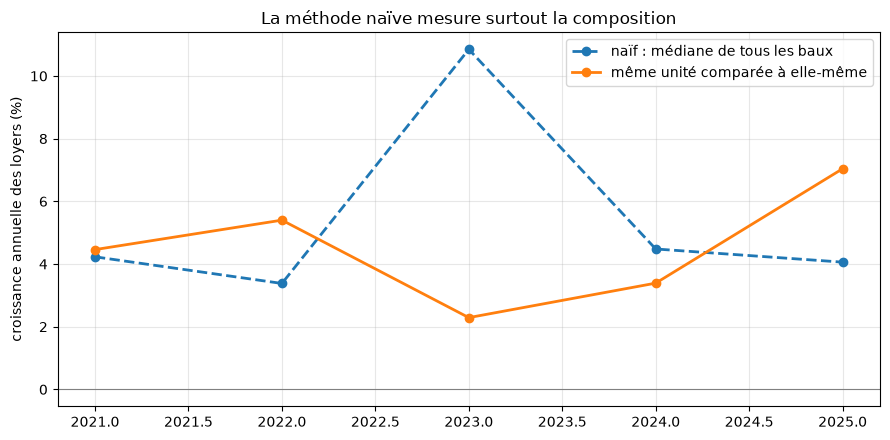

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
yrs = range(2021, 2026)
ax.plot(yrs, naive.loc[yrs, "yoy_pct"], "o--", label="naïf : médiane de tous les baux", lw=2)
ax.plot(yrs, honest.loc[yrs, "median"], "o-", label="même unité comparée à elle-même", lw=2)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("croissance annuelle des loyers (%)")
ax.set_title("La méthode naïve mesure surtout la composition")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 5. Loyer contractuel n'est pas loyer perçu

`sRent` est ce que le bail indique. `sRentEffective` est ce qu'Équinoxe a réellement
perçu après les mois gratuits, le stationnement gratuit et les casiers gratuits. Les concessions sont maintenant
la norme, et elles progressent.

In [10]:
conc = (leases[leases.year.between(2021, 2025)]
        .groupby("year")
        .agg(leases=("sRent", "size"),
             pct_with_concession=("sConcession", lambda s: s.mean() * 100),
             median_contracted=("sRent", "median"),
             median_effective=("sRentEffective", "median")))
conc["gap_pct"] = ((conc.median_effective / conc.median_contracted - 1) * 100)
conc.round(2)

,leases,pct_with_concession,median_contracted,median_effective,gap_pct
year,,,,,
2021,361,54.02,1850.0,1785.00,-3.51
2022,422,57.35,1912.5,1835.00,-4.05
2023,693,54.26,2120.0,2025.40,-4.46
2024,902,73.06,2215.0,2084.46,-5.89
2025,958,85.39,2305.0,2105.59,-8.65


In [11]:
# La concession change-t-elle l'évolution, ou seulement le niveau?
eff = same_unit_growth(leases, price_col="sRentEffective")
compare = pd.DataFrame({
    "contracted": honest["median"],
    "effective":  eff[eff.year.between(2021, 2025)].groupby("year").growth_pct.median(),
}).round(2)
compare

,contracted,effective
year,,
2021,4.46,3.54
2022,5.40,4.59
2023,2.29,2.02
2024,3.39,1.77
2025,7.04,3.58


Ces deux colonnes évoluent de près jusqu'en 2023 - à moins
d'un point l'une de l'autre - puis elles divergent : en 2025, la croissance contractuelle est de
7,0 % alors que la croissance effective est de 3,6 %. L'écart de *niveau* du tableau précédent
se creuse tout au long de la période.

Elles répondent à des questions différentes, et l'année où elles se séparent est celle où les concessions
deviennent plus importantes plutôt que simplement plus fréquentes. Si vous pouvez expliquer ce que cette séparation signifie pour un
propriétaire - et laquelle des deux vous citeriez à un propriétaire - vous comprenez les données
mieux que la plupart des équipes.

## 6. Les renouvellements ne se comportent pas comme les relocations

`sRenewal = 1`, c'est un locataire en place qui renouvelle. `sRenewal = 0`, c'est une unité
qui se libère et qui est relouée au prix du marché. Au Québec, ces deux cas sont régis par
des règles différentes, et l'écart entre les deux est toute la raison pour laquelle un propriétaire s'intéresse
à ce chiffre. Remarquez que l'écart change de camp au cours de la période : les renouvellements mènent en 2022, les relocations en 2025.

In [12]:
split = (pairs[pairs.year.between(2022, 2025)]
         .groupby(["year", "sRenewal"])
         .growth_pct.agg(pairs="size", median="median").round(2)
         .unstack("sRenewal"))
split.columns = [f"{a}_{'renewal' if b else 'turnover'}" for a, b in split.columns]
split

,pairs_turnover,pairs_renewal,median_turnover,median_renewal
year,,,,
2022,126,226,4.22,5.69
2023,177,239,1.85,2.58
2024,276,422,4.85,2.94
2025,307,473,8.98,6.41


## 7. À vous de jouer

Tout ce qui précède est descriptif. Rien de tout ça n'est une prévision, et 2026 n'est pas dans
ce jeu. Ce qui reste, c'est le vrai travail :

**a) Décidez à quelle question vous répondez.** « La hausse de loyer de l'année », ce sont en fait
plusieurs chiffres différents : même unité contractuel, même unité effectif, renouvellements
seulement, relocations seulement, portefeuille combiné. Ils ne concordent pas. Choisissez-en un, nommez-le dans
votre rapport et justifiez votre choix.

**b) Intégrez des données publiques.**

- **Enquête sur les logements locatifs de la SCHL** : loyers et taux d'inoccupation par nombre de chambres pour les
  RMR de Montréal et d'Ottawa, ainsi que la répartition entre logements ayant changé de locataire ou non, qui correspond
  directement à `sRenewal`
- **IPC de Statistique Canada**, composante loyers, Québec et Ontario
- **Tribunal administratif du logement** : les paramètres annuels d'augmentation de loyer au Québec.
  Cinq des six immeubles y sont assujettis
- **Taux légal d'augmentation des loyers en Ontario** : s'applique à l'immeuble The Met, selon
  des règles différentes. N'appliquez pas le plafond d'une province à l'autre

Utilisez la série externe sur l'inoccupation comme *contexte* pour l'orientation des loyers. N'essayez pas
de la transposer en taux d'occupation propre à ce portefeuille - voir la note de la section 2.

**c) Faites une prévision.** Une extrapolation de tendance est un point de départ légitime. Une approche
qui concilie la tendance interne avec le marché externe est meilleure. Énoncez
vos hypothèses.

**e) Misez sur le raisonnement et faites de votre mieux.** Si votre méthode atteint une précision de 95 % et que quelqu'un d'autre obtient 96 %, ça ne veut pas dire que l'autre a gagné. Vous êtes évalué davantage sur la technique que sur le résultat. Les résultats comptent, mais sans un raisonnement constamment démontré derrière chaque choix, même 99 % ne veut rien dire. Nous devons voir une logique claire derrière vos décisions. Note : vous devez **TOUJOURS** expliquer une étape importante, même si ça vous semble inutile ou peu naturel.

## 8. Définition de la hausse

> **Hausse 2026** : **médiane**, sur les baux débutant en 2026, de la variation du **loyer effectif** (`sRentEffective`) entre chaque bail et le **bail précédent de 12 mois de la même unité** (`sPropCode` + `sUnitCode`).

Précisions :
- **Année** : celle de `sLeaseFrom`, date d'entrée en vigueur du nouveau loyer.
- **Variation par bail, non annualisée.** Une hausse s'applique à chaque nouveau bail, pas au prorata du temps : annualiser après un bail de 6 mois doublerait la hausse, après 24 mois la diviserait par deux. Avec un bail précédent de 12 mois (environ 95 % des paires), les deux mesures coïncident (10.4).
- **Périmètre** : renouvellements et relocations des six immeubles.

**Pourquoi ce choix :**
1. **Le loyer effectif est ce que le propriétaire encaisse**, donc le bon chiffre pour budgéter les revenus. Avec des concessions passées de moins de 4 % à plus de 9 % du loyer entre 2023 et 2025, le loyer contractuel surestime la hausse réelle (section 12).
2. **L'unité constante neutralise l'effet de composition**, responsable de la fausse hausse de 10,8 % en 2023 (section 11).
3. **La médiane résiste aux paires atypiques** ; la moyenne pondérée par le loyer sert de contrôle (12.5).

**Règle d'usage des mesures**, appliquée dans tout le notebook :

| Usage | Mesure |
|---|---|
| **Réponse** : hausse 2026 pour budgéter les revenus | Loyer effectif, **concessions accessoires comprises** |
| Réconciliation avec le marché et la réglementation (TAL, Ontario, IPC, SCHL) | Loyer contractuel : les séries publiques portent sur le loyer, pas sur les incitatifs |
| Décomposition | Renouvellements vs relocations (`sRenewal`), lus selon le TAL au Québec et la règle ontarienne pour The Met |
| Scénario alternatif | Loyer effectif « loyer seulement » (rabais de loyer seulement) |

Les concessions accessoires (stationnement, casier, électroménagers) sont incluses : ce sont des incitatifs accordés pour signer le bail, donc des revenus auxquels le propriétaire renonce. Leur poids est chiffré en 12.5 et 12.6.

In [13]:
# Paramètres de la définition retenue (section 8).
# Toutes les étapes suivantes s'y réfèrent : aucun nombre magique dans le reste du notebook.
# Les noms de colonnes sont ceux des copies de travail créées en 9.6 (la clé d'appariement y devient UNIT_KEY_CLEAN).

FORECAST_YEAR = 2026                    # année de la hausse à estimer
EFFECTIVE_RENT_COL = "effective_rent"   # mesure principale : loyer effectivement perçu (sRentEffective)
CONTRACT_RENT_COL = "contract_rent"     # mesure secondaire : loyer inscrit au bail (sRent)
LEASE_START_COL = "lease_start"         # l'année d'une hausse = année d'entrée en vigueur du nouveau loyer (sLeaseFrom)
COMPARABLE_PREV_TERM_MONTHS = 12        # durée exigée du bail précédent pour une paire comparable
GROWTH_STATISTIC = "median"             # statistique principale (moyenne pondérée en contrôle)

## 9. Dictionnaire des données

Les descriptions des colonnes ne correspondent pas toujours aux données (consignes). Pour chaque table, on donne la signification **réelle** de chaque colonne, son nouveau nom et son statut ; chaque affirmation non évidente est prouvée par la cellule de code qui suit.

| Statut | Sens |
|---|---|
| **Clé** | Sert aux jointures ou à l'appariement des baux. |
| **Utile** | Entre dans le calcul de la hausse ou dans sa décomposition. |
| **Contexte** | Sert à l'affichage ou au regroupement, pas au calcul. |
| **Redondante** | Information déjà portée par une autre colonne : retirée des copies de travail. |
| **À ignorer** | Constante ou non fiable : retirée des copies de travail. |

Les sections 1 à 6 utilisent les noms d'origine : on ne modifie donc jamais les tables brutes. Le renommage se fait en 9.6 sur des **copies de travail** (`units`, `leases_clean`, `concessions_clean`, `asking_clean`), à partir d'un dictionnaire de correspondance par table (anglais, `snake_case`).

### 9.1 Colonnes communes : identifiants et attributs d'unité

Les quatre tables répètent les mêmes attributs d'unité. La table `listings` (1 061 unités, une ligne par unité) sert de référence.

| Colonne Yardi | Nouveau nom | Signification réelle | Statut |
|---|---|---|---|
| `hUnit` | `unit_id` | Identifiant unique de l'unité, en correspondance 1:1 avec `sPropCode` + `sUnitCode`. | Clé (jointures) |
| `sPropCode` | `prop_code` | Code de propriété. Un immeuble peut en avoir plusieurs : Saint-Elzéar a `stelz1` à `stelz3`, Daniel-Johnson a `dj1` et `dj2`. | Clé (appariement) |
| `sUnitCode` | `unit_code` | Numéro d'unité. C'est une **chaîne** : zéros initiaux (`0102`) et codes non numériques (`0151R`, `PH1903`, `2702PH2`…). Il est unique seulement à l'intérieur d'un `sPropCode`. | Clé (appariement) |
| `sBuilding` | `building` | Nom de l'immeuble. | Contexte (regroupement) |
| `sState` | `province` | Province. Elle détermine le régime applicable : TAL au Québec, ligne directrice en Ontario. | Utile |
| `sCity` | `city` | Ville. | Contexte |
| `sBeds` | `bedrooms` | Nombre de chambres (0 = studio). | Utile |
| `sBaths` | `bathrooms` | Nombre de salles de bain. | Utile |
| `sSqft` | `sqft` | Superficie en pi². | Utile |
| `sFloor` | `floor` | Étage, égal au préfixe numérique du numéro d'unité (`0203` → 2, `PH1903` → 19). | Utile |
| `sUnitType` | `unit_type_code` | Code `<chambres>_<salles de bain>[d]`. Le suffixe `d` indique un **den**, une information absente des autres colonnes numériques. | Utile (décodé en `has_den`) |
| `hProperty` | — | Identifiant numérique de `sPropCode` (1:1). | Redondante |
| `hBuilding` | — | Identifiant numérique de `sBuilding` (1:1). | Redondante |
| `sSite` | — | Identifiant texte de l'immeuble (1:1 avec `sBuilding`). **Jamais une clé d'unité** : voir section 4. | Redondante |
| `sAddr1`, `sLatitude`, `sLongitude` | — | Adresse et coordonnées de l'immeuble (1:1 avec `sBuilding`). | Redondantes |
| `sUnitSubtype` | — | Libellé du nombre de chambres (« 2 Bed »). | Redondante (`bedrooms`) |
| `sUnitDesc` | — | Description texte (« 1 bed, 1 bath, den »). | Redondante (`unit_type_code`) |
| `sLink` | — | URL construite sur `sPropCode` + `sUnitCode`. | Redondante (clé) |
| `sPropType`, `sFurnishing`, `sSmoking`, `sCats`, `sDogs` | — | Constantes : une seule valeur dans tout le jeu. | À ignorer |

Comme ces attributs sont identiques d'une table à l'autre pour une même unité (vérifié ci-dessous), on les garde dans `units` et `leases_clean`. On les retire de `concessions_clean` et `asking_clean`, qu'on peut joindre par `unit_id`.

In [14]:
# Preuves 9.1 : clés, cohérence des attributs entre tables, colonnes constantes ou 1:1 avec l'immeuble, décodage de sUnitType.
print(f"sPropCode + sUnitCode unique dans listings : {not listings.duplicated(UNIT_KEY).any()}")
print(f"hUnit unique dans listings                : {listings.hUnit.is_unique}")

UNIT_ATTRIBUTE_COLS = ["sPropCode", "sUnitCode", "sBuilding", "sSite", "sBeds", "sBaths", "sSqft", "sFloor", "sUnitType"]
reference_units = listings.set_index("hUnit")[UNIT_ATTRIBUTE_COLS]
for table_name, table in [("leases", leases), ("concessions", concessions), ("asking", asking)]:
    shared_cols = [c for c in UNIT_ATTRIBUTE_COLS if c in table.columns]
    joined = table[["hUnit"] + shared_cols].join(reference_units, on="hUnit", rsuffix="_ref")
    consistent = all((joined[c] == joined[f"{c}_ref"]).all() for c in shared_cols)
    print(f"Attributs d'unité identiques à listings dans {table_name:<11} : {consistent}")

print("\nColonnes constantes dans leases   :", [c for c in leases.columns if leases[c].nunique() == 1])
print("Colonnes constantes dans listings :", [c for c in listings.columns if listings[c].nunique() == 1])
BUILDING_LEVEL_COLS = ["hBuilding", "sSite", "sAddr1", "sLatitude", "sLongitude", "sCity", "sState"]
print("Une seule valeur par immeuble pour", BUILDING_LEVEL_COLS, ":",
      bool((listings.groupby("sBuilding")[BUILDING_LEVEL_COLS].nunique() == 1).all().all()))
print("hProperty 1:1 avec sPropCode :",
      listings.groupby("sPropCode").hProperty.nunique().max() == 1 and listings.groupby("hProperty").sPropCode.nunique().max() == 1)

UNIT_TYPE_PATTERN = r"^(?P<beds>\d)_(?P<baths>\d)(?P<den>d?)$"
decoded_unit_type = listings.sUnitType.str.extract(UNIT_TYPE_PATTERN)
decoding_matches = ((decoded_unit_type.beds.astype(int) == listings.sBeds)
                    & (decoded_unit_type.baths.astype(float) == listings.sBaths)).all()
print(f"\nsUnitType = <chambres>_<sdb>[d] pour toutes les unités : {decoding_matches}"
      f" | unités avec den : {(decoded_unit_type.den == 'd').sum()}")
print("Codes d'unité non numériques :", sorted(listings.loc[~listings.sUnitCode.str.isdigit(), "sUnitCode"]))

sPropCode + sUnitCode unique dans listings : True
hUnit unique dans listings                : True
Attributs d'unité identiques à listings dans leases      : True
Attributs d'unité identiques à listings dans concessions : True
Attributs d'unité identiques à listings dans asking      : True

Colonnes constantes dans leases   : ['sPropType', 'sFurnishing', 'sSmoking', 'sCats', 'sDogs']
Colonnes constantes dans listings : ['sLeaseTerm', 'sPropType', 'sFurnishing', 'sSmoking', 'sCats', 'sDogs']
Une seule valeur par immeuble pour ['hBuilding', 'sSite', 'sAddr1', 'sLatitude', 'sLongitude', 'sCity', 'sState'] : True
hProperty 1:1 avec sPropCode : True

sUnitType = <chambres>_<sdb>[d] pour toutes les unités : True | unités avec den : 131
Codes d'unité non numériques : ['0151R', '0253R', '0255R', '0351R', '0352R', '0353R', '0354R', '2702PH2', 'PH1903', 'PH1905', 'PH1906', 'PH2001', 'PH2002', 'PH2005']


### 9.2 Baux (`equinoxe_lease_history.csv`)

Une ligne par bail. En plus des attributs d'unité de 9.1 :

| Colonne Yardi | Nouveau nom | Signification réelle | Statut |
|---|---|---|---|
| `sRent` | `contract_rent` | Loyer mensuel inscrit au bail. | Utile (mesure secondaire) |
| `sRentEffective` | `effective_rent` | Loyer mensuel net des concessions du bail, étalées sur sa durée. Il **inclut les concessions accessoires** (stationnement, casier…). Formule prouvée en 10.2. | Utile (mesure principale) |
| `sConcession` | `has_concession` | **Indicateur** 0/1 : le bail a au moins une concession. Ce n'est pas un montant. | Utile |
| `sLeaseFrom` | `lease_start` | Début du bail, soit l'entrée en vigueur du nouveau loyer. | Utile (définit l'année, section 8) |
| `sLeaseTo` | `lease_end` | Fin contractuelle. Elle peut dépasser 2025. | Contexte |
| `sSignDate` | `sign_date` | Date de signature, de 0 à 75 jours avant le début. | Contexte |
| `sTermMonths` | `term_months` | Durée **réelle** du bail (5,9, 12, 17,9 ou 23,9 mois), cohérente avec les dates. | Utile |
| `sTermSeq` | `unit_lease_seq` | **Nom trompeur.** C'est le rang chronologique du bail *pour l'unité*. Il ne repart pas à 1 quand le locataire change. | Utile (renommée) |
| `sRenewal` | `is_renewal` | Vrai pour un locataire en place qui renouvelle, faux pour une relocation. Il vaut **toujours 0 au premier bail** de chaque unité dans l'extrait, puisque ce bail n'a pas de bail précédent connu. | Utile |
| `year` | `lease_start_year` | Année de `lease_start`, ajoutée à la section 1. | Utile |
| `sLeaseTerm` | — | **Nom trompeur.** C'est une étiquette d'annonce, contredite par `sTermMonths` : des baux étiquetés « 6 Months » durent 12 mois. | À ignorer |
| `sAvailable` | — | Identique à `sLeaseFrom` pour 100 % des baux. | Redondante |

In [15]:
# Preuves 9.2 : sTermSeq, sRenewal, sAvailable, durée réelle vs étiquette, signature, sConcession.
DAYS_PER_YEAR = 365.25
MONTHS_PER_YEAR = 12
AVG_DAYS_PER_MONTH = DAYS_PER_YEAR / MONTHS_PER_YEAR

leases_by_unit = leases.sort_values(UNIT_KEY + ["sLeaseFrom"])
chronological_rank = leases_by_unit.groupby(UNIT_KEY).cumcount() + 1
print(f"sTermSeq == rang chronologique du bail dans l'unité : {(leases_by_unit.sTermSeq == chronological_rank).mean():.1%}")
print("sRenewal au premier bail de chaque unité :", leases_by_unit.loc[chronological_rank == 1, "sRenewal"].value_counts().to_dict())
print(f"sAvailable == sLeaseFrom : {(leases.sAvailable == leases.sLeaseFrom).mean():.1%}")

term_months_from_dates = ((leases.sLeaseTo - leases.sLeaseFrom).dt.days + 1) / AVG_DAYS_PER_MONTH
print(f"Écart max entre la durée calculée par les dates et sTermMonths : {(term_months_from_dates - leases.sTermMonths).abs().max():.2f} mois")
print("\nsLeaseTerm (étiquette) vs sTermMonths (durée réelle) :")
print(pd.crosstab(leases.sLeaseTerm, leases.sTermMonths).to_string())

sign_lead_days = (leases.sLeaseFrom - leases.sSignDate).dt.days
print(f"\nJours entre signature et début du bail : de {sign_lead_days.min()} à {sign_lead_days.max()}")
print(f"Valeurs de sConcession : {sorted(leases.sConcession.unique().tolist())}")
print(f"Baux dont la fin dépasse l'horizon des données : {(leases.sLeaseTo > leases.sLeaseFrom.max()).sum():,}")

sTermSeq == rang chronologique du bail dans l'unité : 100.0%
sRenewal au premier bail de chaque unité : {0: 1061}
sAvailable == sLeaseFrom : 100.0%
Écart max entre la durée calculée par les dates et sTermMonths : 0.08 mois

sLeaseTerm (étiquette) vs sTermMonths (durée réelle) :
sTermMonths  5.9   12.0  17.9  23.9
sLeaseTerm                         
6 Months       76   100     0     0
Long Term       0  2578    93    66
Negotiable      0  1287     0     0
Short Term      0   102     0     0

Jours entre signature et début du bail : de 0 à 75
Valeurs de sConcession : [0, 1]
Baux dont la fin dépasse l'horizon des données : 963


### 9.3 Concessions (`equinoxe_concessions.csv`)

Une ligne par concession. La table **ne contient pas d'identifiant de bail** : le rattachement à un bail se fait en 10.2. En plus de la clé d'unité de 9.1 :

| Colonne Yardi | Nouveau nom | Signification réelle | Statut |
|---|---|---|---|
| `sChargeCode` | `charge_code` | Code comptable tronqué à 8 caractères (voir la section 1b). | Utile |
| `sChargeDesc` | `charge_desc` | Libellé du code. | Contexte |
| `sAmount` | `monthly_amount` | **Montant mensuel**, négatif (rabais). Le montant total vaut `monthly_amount × charge_months`. PromoPay est la seule exception de forme : un rabais **ponctuel** de 1 ou 2 mois, d'environ un mois de loyer, et non un rabais mensuel sur toute la durée du bail. | Utile |
| `sDateFrom` | `charge_start` | **Trompeuse.** Elle est toujours ramenée au **1er du mois**, et peut donc précéder `lease_start` de quelques jours. Il faut rattacher au *mois*, pas à la date. | Utile |
| `sDateTo` | `charge_end` | Fin de la concession. Elle peut dépasser 2025. | Contexte |
| `sMonths` | `charge_months` | Nombre de mois couverts, cohérent avec les dates. | Utile |

In [16]:
# Preuves 9.3 : début au 1er du mois, sMonths cohérent avec les dates, signe et forme des montants par code.
concession_start = pd.to_datetime(concessions.sDateFrom)
concession_end = pd.to_datetime(concessions.sDateTo)
print(f"sDateFrom tombe le 1er du mois : {(concession_start.dt.day == 1).mean():.1%}")
months_from_dates = ((concession_end - concession_start).dt.days + 1) / AVG_DAYS_PER_MONTH
print(f"Écart max entre mois couverts (dates) et sMonths : {(months_from_dates - concessions.sMonths).abs().max():.2f} mois")
print(f"Montants tous négatifs : {(concessions.sAmount < 0).all()}\n")
print(concessions.groupby("sChargeCode")
      .agg(n=("sAmount", "size"),
           median_monthly_amount=("sAmount", "median"),
           median_months=("sMonths", "median"),
           max_months=("sMonths", "max"))
      .round(2).to_string())
print("\nDurée des concessions PromoPay (mois) :", concessions.loc[concessions.sChargeCode == "PromoPay", "sMonths"].value_counts().to_dict())

sDateFrom tombe le 1er du mois : 100.0%
Écart max entre mois couverts (dates) et sMonths : 0.03 mois
Montants tous négatifs : True

                n  median_monthly_amount  median_months  max_months
sChargeCode                                                        
Freeothe      570                -153.49           12.0        12.0
Indem          69                -149.26           12.0        17.0
PromoPay     1494               -1356.60            1.0         2.0
Referenc       36                -148.26           12.0        17.0
freeappl       44                -143.58           12.0        12.0
freelock      175                -139.35           12.0        12.0
freepark     1006                -150.50           12.0        23.0
freerent      166                -129.30           12.0        12.0

Durée des concessions PromoPay (mois) : {1.0: 1318, 2.0: 176}


### 9.4 Loyers affichés (`equinoxe_asking_history.csv`)

Une ligne par unité et par mois d'affichage. En plus de la clé d'unité de 9.1 :

| Colonne Yardi | Nouveau nom | Signification réelle | Statut |
|---|---|---|---|
| `sMonth` | `asking_month` | Mois de l'affichage, converti en date au 1er du mois (colonne `date` de la section 1). | Utile |
| `sAskingRent` | `asking_rent` | Loyer demandé. Un affichage **précède chaque nouveau bail** de 0 à 4 mois, *y compris les renouvellements*. Le loyer signé vaut environ 98 % du loyer affiché. | Utile |

Le loyer affiché **anticipe** donc le loyer des baux qui commencent dans les mois suivants. Aucun affichage ne concerne un bail de 2026, il n'y a donc pas de fuite d'information sur la cible. En backtest, il faudra respecter ce décalage pour ne pas utiliser un affichage postérieur à la date de prévision.

In [17]:
# Preuve 9.4 : lien entre chaque affichage et le bail suivant de la même unité.
asking_to_next_lease = pd.merge_asof(
    asking.sort_values("date"),
    leases[["hUnit", "sLeaseFrom", "sRent", "sRenewal"]].sort_values("sLeaseFrom"),
    left_on="date", right_on="sLeaseFrom", by="hUnit", direction="forward")
lead_months = ((asking_to_next_lease.sLeaseFrom.dt.year - asking_to_next_lease.date.dt.year) * MONTHS_PER_YEAR
               + (asking_to_next_lease.sLeaseFrom.dt.month - asking_to_next_lease.date.dt.month))
print(f"Affichages suivis d'un bail de la même unité : {asking_to_next_lease.sLeaseFrom.notna().mean():.1%}")
print("Mois entre l'affichage et le début du bail suivant :", lead_months.value_counts().sort_index().to_dict())
signed_to_asking = asking_to_next_lease.sRent / asking_to_next_lease.sAskingRent
print("Loyer signé / loyer affiché (médiane), par sRenewal du bail suivant :",
      signed_to_asking.groupby(asking_to_next_lease.sRenewal).median().round(3).to_dict())
print(f"Dernier mois affiché : {asking.date.max():%Y-%m} | dernier début de bail : {leases.sLeaseFrom.max():%Y-%m}")

Affichages suivis d'un bail de la même unité : 100.0%
Mois entre l'affichage et le début du bail suivant : {0: 511, 1: 1472, 2: 1382, 3: 449, 4: 43}
Loyer signé / loyer affiché (médiane), par sRenewal du bail suivant : {0: 0.977, 1: 0.979}
Dernier mois affiché : 2025-12 | dernier début de bail : 2025-12


### 9.5 Unités (`equinoxe_listings.csv`)

Une ligne par unité. Cette table devient la table de référence `units`. En plus des attributs de 9.1 :

| Colonne Yardi | Nouveau nom | Signification réelle | Statut |
|---|---|---|---|
| `sRent` | `snapshot_asking_rent` | **Nom trompeur : ce n'est pas le loyer en cours.** C'est un loyer affiché à la date `sAsOf` (en 2025), environ 2,5 % au-dessus du loyer du dernier bail, et différent du dernier affichage de `asking`. | Contexte (une seule date, donc inutilisable en backtest) |
| `sAsOf` | `snapshot_month` | Mois de l'instantané (janvier à décembre 2025). | Contexte |
| `sAvailable` | — | Date de disponibilité annoncée. Elle ne correspond pas à la fin du dernier bail. | À ignorer (non fiable) |
| `sLeaseTerm` | — | Constante (« Long Term »). | À ignorer |

In [18]:
# Preuve 9.5 : listings.sRent n'est ni le loyer du dernier bail, ni le dernier loyer affiché ; sAvailable ne suit pas les baux.
listing_by_unit = listings.set_index("hUnit")
last_lease = leases.sort_values("sLeaseFrom").groupby("hUnit").tail(1).set_index("hUnit").reindex(listing_by_unit.index)
last_asking = asking.sort_values("date").groupby("hUnit").tail(1).set_index("hUnit").reindex(listing_by_unit.index)

print(f"sRent == loyer du dernier bail          : {(listing_by_unit.sRent == last_lease.sRent).mean():.1%}")
print(f"sRent == dernier loyer affiché           : {(listing_by_unit.sRent == last_asking.sAskingRent).mean():.1%}")
print(f"sRent / loyer du dernier bail (médiane)  : {(listing_by_unit.sRent / last_lease.sRent).median():.3f}")
print(f"sAsOf : de {listings.sAsOf.min()} à {listings.sAsOf.max()}")
days_after_lease_end = (pd.to_datetime(listing_by_unit.sAvailable) - last_lease.sLeaseTo).dt.days
print(f"sAvailable == lendemain de la fin du dernier bail : {(days_after_lease_end == 1).mean():.1%}")

sRent == loyer du dernier bail          : 2.7%
sRent == dernier loyer affiché           : 2.8%
sRent / loyer du dernier bail (médiane)  : 1.025
sAsOf : de 2025-01 à 2025-12
sAvailable == lendemain de la fin du dernier bail : 1.8%


### 9.6 Renommage et copies de travail

On applique maintenant les tableaux 9.1 à 9.5. Chaque table a un dictionnaire de correspondance **colonne Yardi → nom de travail**. **Toute colonne absente d'un dictionnaire est retirée** de la copie : elle a été classée redondante ou à ignorer ci-dessus. Les tables d'origine restent intactes pour les sections 1 à 6.

On en profite pour trois conversions de type :
- les dates des concessions et de l'instantané deviennent des `datetime` ;
- `has_concession` et `is_renewal` deviennent des booléens ;
- le den est décodé de `unit_type_code` en une colonne `has_den`.

In [19]:
# Dictionnaires de correspondance : colonne Yardi -> nom de travail (voir les tableaux 9.1 à 9.5).
UNIT_KEY_RENAMES = {"hUnit": "unit_id", "sPropCode": "prop_code", "sUnitCode": "unit_code"}
UNIT_ATTRIBUTE_RENAMES = {
    **UNIT_KEY_RENAMES,
    "sBuilding": "building",
    "sCity": "city",
    "sState": "province",
    "sBeds": "bedrooms",
    "sBaths": "bathrooms",
    "sSqft": "sqft",
    "sFloor": "floor",
    "sUnitType": "unit_type_code",
}
UNITS_RENAMES = {
    **UNIT_ATTRIBUTE_RENAMES,
    "sRent": "snapshot_asking_rent",
    "sAsOf": "snapshot_month",
}
LEASES_RENAMES = {
    **UNIT_ATTRIBUTE_RENAMES,
    "sRent": "contract_rent",
    "sRentEffective": "effective_rent",
    "sConcession": "has_concession",
    "sLeaseFrom": "lease_start",
    "sLeaseTo": "lease_end",
    "sSignDate": "sign_date",
    "sTermMonths": "term_months",
    "sTermSeq": "unit_lease_seq",
    "sRenewal": "is_renewal",
    "year": "lease_start_year",
}
CONCESSIONS_RENAMES = {
    **UNIT_KEY_RENAMES,
    "sChargeCode": "charge_code",
    "sChargeDesc": "charge_desc",
    "sAmount": "monthly_amount",
    "sDateFrom": "charge_start",
    "sDateTo": "charge_end",
    "sMonths": "charge_months",
}
ASKING_RENAMES = {
    **UNIT_KEY_RENAMES,
    "date": "asking_month",       # sMonth déjà converti en date à la section 1
    "sAskingRent": "asking_rent",
}

UNIT_KEY_CLEAN = [UNIT_KEY_RENAMES[col] for col in UNIT_KEY]   # équivalent de UNIT_KEY après renommage


def to_working_copy(raw_table, renames):
    # Copie de travail : seulement les colonnes documentées, sous leur nouveau nom.
    missing = set(renames) - set(raw_table.columns)
    if missing:
        raise KeyError(f"Colonnes attendues absentes : {sorted(missing)}")
    return raw_table[list(renames)].rename(columns=renames).copy()


units = to_working_copy(listings, UNITS_RENAMES)
leases_clean = to_working_copy(leases, LEASES_RENAMES)
concessions_clean = to_working_copy(concessions, CONCESSIONS_RENAMES)
asking_clean = to_working_copy(asking, ASKING_RENAMES)

# Conversions de type.
concessions_clean["charge_start"] = pd.to_datetime(concessions_clean.charge_start)
concessions_clean["charge_end"] = pd.to_datetime(concessions_clean.charge_end)
units["snapshot_month"] = pd.to_datetime(units.snapshot_month, format="%Y-%m")
leases_clean["has_concession"] = leases_clean.has_concession.astype(bool)
leases_clean["is_renewal"] = leases_clean.is_renewal.astype(bool)

# Information cachée : le den, décodé de unit_type_code (motif vérifié en 9.1).
units["has_den"] = units.unit_type_code.str.extract(UNIT_TYPE_PATTERN)["den"].eq("d")
leases_clean = leases_clean.merge(units[["unit_id", "has_den"]], on="unit_id", how="left", validate="many_to_one")

for table_name, table in [("units", units), ("leases_clean", leases_clean),
                          ("concessions_clean", concessions_clean), ("asking_clean", asking_clean)]:
    print(f"{table_name:<18} {len(table):>5,} lignes  {table.shape[1]:>2} colonnes : {', '.join(table.columns)}")

units              1,061 lignes  14 colonnes : unit_id, prop_code, unit_code, building, city, province, bedrooms, bathrooms, sqft, floor, unit_type_code, snapshot_asking_rent, snapshot_month, has_den
leases_clean       4,302 lignes  22 colonnes : unit_id, prop_code, unit_code, building, city, province, bedrooms, bathrooms, sqft, floor, unit_type_code, contract_rent, effective_rent, has_concession, lease_start, lease_end, sign_date, term_months, unit_lease_seq, is_renewal, lease_start_year, has_den
concessions_clean  3,560 lignes   9 colonnes : unit_id, prop_code, unit_code, charge_code, charge_desc, monthly_amount, charge_start, charge_end, charge_months
asking_clean       3,857 lignes   5 colonnes : unit_id, prop_code, unit_code, asking_month, asking_rent


**Bilan de la section 9.** Quatre copies de travail sont prêtes (`units`, `leases_clean`, `concessions_clean`, `asking_clean`), avec `UNIT_KEY_CLEAN = ["prop_code", "unit_code"]` comme clé d'appariement. Les colonnes trompeuses sont renommées (`sTermSeq`, `sLeaseTerm`, `sDateFrom`, `sAmount`, `listings.sRent`), et les colonnes constantes, redondantes ou non fiables sont retirées.

## 10. Tables de travail : baux enrichis et paires comparables

Cette section construit, à partir des copies de la section 9, les deux tables sur lesquelles reposent toutes les analyses suivantes :

1. **`leases_enriched`** : une ligne par bail, avec la valeur de ses concessions ventilée par catégorie, son intensité de concession et le loyer effectif « loyer seulement » prévu en sensibilité (section 8).
2. **`comparable_pairs`** : une ligne par paire *(bail, bail précédent de la même unité)* qui respecte la définition de la section 8, avec la variation du loyer pour chaque mesure.

La table de toutes les paires consécutives, `lease_pairs`, est conservée pour les analyses de sensibilité.

### 10.1 Catégories de concessions

Les huit codes de concession ne mesurent pas la même chose. On les regroupe en trois catégories, selon ce qu'ils réduisent réellement :

| Catégorie | Codes | Raison |
|---|---|---|
| `rent_discount` | `freerent`, `PromoPay` | Rabais sur **le loyer lui-même** : mois gratuits ou promotion. |
| `ancillary` | `freepark`, `freelock`, `freeappl` | Services **accessoires** offerts (stationnement, casier, électroménagers). Ce sont des revenus perdus, mais pas du loyer. |
| `other` | `Freeothe`, `Indem`, `Referenc` | Non catégorisé (« à traiter avec méfiance », section 1b), **indemnité** versée au résident pour régler un différend, ou **crédit de référencement**, qui relève du marketing. |

`sRentEffective` inclut les trois catégories (section 10.2). Le loyer effectif « loyer seulement » ne retient que `rent_discount`. Cette étape ajoute la colonne `concession_category` à `concessions_clean`.

In [20]:
# Regroupement des codes de concession par catégorie économique.
CONCESSION_CATEGORIES = {
    "freerent": "rent_discount",
    "PromoPay": "rent_discount",
    "freepark": "ancillary",
    "freelock": "ancillary",
    "freeappl": "ancillary",
    "Freeothe": "other",
    "Indem": "other",
    "Referenc": "other",
}
CONCESSION_CATEGORY_ORDER = ["rent_discount", "ancillary", "other"]

unmapped_codes = set(concessions_clean.charge_code) - set(CONCESSION_CATEGORIES)
if unmapped_codes:
    raise ValueError(f"Codes de concession sans catégorie : {sorted(unmapped_codes)}")
concessions_clean["concession_category"] = concessions_clean.charge_code.map(CONCESSION_CATEGORIES)

print(concessions_clean.groupby("concession_category")
      .agg(concessions=("charge_code", "size"),
           codes=("charge_code", lambda codes: ", ".join(sorted(codes.unique()))))
      .reindex(CONCESSION_CATEGORY_ORDER).to_string())

                     concessions                         codes
concession_category                                           
rent_discount               1660            PromoPay, freerent
ancillary                   1225  freeappl, freelock, freepark
other                        675     Freeothe, Indem, Referenc


### 10.2 Baux enrichis (`leases_enriched`)

La table des concessions n'a pas d'identifiant de bail. On rattache donc chaque concession au bail le plus récent de la même unité dont le **mois de début** précède `charge_start` (`merge_asof`). Rattacher sur la date exacte serait une erreur : `charge_start` est toujours au 1er du mois (9.3), si bien qu'une concession datée du 2024-05-01 pour un bail commençant le 2024-05-27 irait au bail *précédent*.

On calcule ensuite, pour chaque bail (valeurs **en dollars positifs**) :

| Colonne ajoutée | Calcul |
|---|---|
| `rent_discount_value`, `ancillary_value`, `other_value` | Valeur totale des concessions du bail, par catégorie, **en dollars positifs** : `−monthly_amount × charge_months`. |
| `concession_value` | Somme des trois catégories. |
| `concession_share` | `concession_value / (contract_rent × term_months)` : part du loyer contractuel du bail cédée en concessions. |
| `rent_discount_share` | Même calcul, en ne gardant que les rabais de loyer. |
| `rent_only_effective_rent` | `contract_rent − rent_discount_value / term_months` : loyer effectif sans les accessoires (sensibilité). |
| `effective_rent_matches_concessions` | Vrai si `effective_rent` correspond aux concessions rattachées, à `RECONSTRUCTION_TOLERANCE` près. |
| `has_promopay` | Vrai si le bail a au moins une concession PromoPay. |

On vérifie au passage l'hypothèse sur `sRentEffective` : `effective_rent = contract_rent − concession_value / term_months`. `effective_rent` reste la valeur fournie par le CRM : on ne la remplace pas.

In [21]:
# Rattachement de chaque concession au bail de la même unité dont le mois de début est le plus récent.
RECONSTRUCTION_TOLERANCE = 1.0   # $ d'écart toléré sur le total des concessions d'un bail (arrondis)
leases_clean["lease_start_month"] = leases_clean.lease_start.dt.to_period("M").dt.to_timestamp()

concessions_by_lease = pd.merge_asof(
    concessions_clean.sort_values("charge_start"),
    leases_clean[["unit_id", "unit_lease_seq", "lease_start_month", LEASE_START_COL, "lease_end", CONTRACT_RENT_COL]].sort_values("lease_start_month"),
    left_on="charge_start", right_on="lease_start_month", by="unit_id", direction="backward")
if concessions_by_lease.unit_lease_seq.isna().any() or (concessions_by_lease.charge_start > concessions_by_lease.lease_end).any():
    raise ValueError("Concession sans bail ou commençant après la fin du bail rattaché")
concessions_by_lease["concession_value"] = -concessions_by_lease.monthly_amount * concessions_by_lease.charge_months

# Valeur des concessions par bail et par catégorie.
value_by_category = (concessions_by_lease
                     .pivot_table(index=["unit_id", "unit_lease_seq"], columns="concession_category",
                                  values="concession_value", aggfunc="sum", fill_value=0)
                     .reindex(columns=CONCESSION_CATEGORY_ORDER, fill_value=0)
                     .rename_axis(columns=None)
                     .add_suffix("_value"))
CONCESSION_VALUE_COLS = list(value_by_category.columns)

leases_enriched = leases_clean.join(value_by_category, on=["unit_id", "unit_lease_seq"])
leases_enriched[CONCESSION_VALUE_COLS] = leases_enriched[CONCESSION_VALUE_COLS].fillna(0)
leases_enriched["concession_value"] = leases_enriched[CONCESSION_VALUE_COLS].sum(axis=1)

contract_rent_over_term = leases_enriched[CONTRACT_RENT_COL] * leases_enriched.term_months
leases_enriched["concession_share"] = leases_enriched.concession_value / contract_rent_over_term
leases_enriched["rent_discount_share"] = leases_enriched.rent_discount_value / contract_rent_over_term
leases_enriched["rent_only_effective_rent"] = (leases_enriched[CONTRACT_RENT_COL]
                                               - leases_enriched.rent_discount_value / leases_enriched.term_months)

implied_concession_value = (leases_enriched[CONTRACT_RENT_COL] - leases_enriched[EFFECTIVE_RENT_COL]) * leases_enriched.term_months
leases_enriched["effective_rent_matches_concessions"] = (
    (implied_concession_value - leases_enriched.concession_value).abs() < RECONSTRUCTION_TOLERANCE)

promopay_concessions = concessions_by_lease[concessions_by_lease.charge_code == "PromoPay"]
promopay_lease_keys = pd.MultiIndex.from_frame(promopay_concessions[["unit_id", "unit_lease_seq"]])
leases_enriched["has_promopay"] = pd.MultiIndex.from_frame(leases_enriched[["unit_id", "unit_lease_seq"]]).isin(promopay_lease_keys)

print(f"leases_enriched : {len(leases_enriched):,} baux (attendu : {len(leases_clean):,})")
print(f"Concessions commençant avant la date exacte de début du bail (mal rattachées sans le rattachement au mois) : "
      f"{(concessions_by_lease.charge_start < concessions_by_lease[LEASE_START_COL]).mean():.1%}")
print(f"has_concession == (valeur de concessions > 0) : {(leases_enriched.has_concession == (leases_enriched.concession_value > 0)).mean():.1%}")
print(f"effective_rent cohérent avec les concessions rattachées : {leases_enriched.effective_rent_matches_concessions.mean():.1%}")
print(leases_enriched.groupby("has_promopay").effective_rent_matches_concessions.agg(leases="size", formula_holds="mean").round(3).to_string())
print(f"PromoPay : {promopay_concessions.charge_months.value_counts().to_dict()} (mois couverts) ; "
      f"montant total médian = {(promopay_concessions.concession_value / promopay_concessions[CONTRACT_RENT_COL]).median():.2f} mois de loyer")

leases_enriched : 4,302 baux (attendu : 4,302)
Concessions commençant avant la date exacte de début du bail (mal rattachées sans le rattachement au mois) : 26.2%
has_concession == (valeur de concessions > 0) : 100.0%
effective_rent cohérent avec les concessions rattachées : 90.8%
              leases  formula_holds
has_promopay                       
False           2967          0.994
True            1335          0.718
PromoPay : {1.0: 1318, 2.0: 176} (mois couverts) ; montant total médian = 0.87 mois de loyer


**Ce que confirme le rattachement.**
- **Rattacher au mois est indispensable** : environ un quart des concessions commencent avant la date exacte de début de leur bail. Avec ce rattachement, `has_concession` concorde à 100 % avec la présence d'une concession.
- **La formule de `sRentEffective` est confirmée** : loyer contractuel moins les concessions du bail, **étalées linéairement sur sa durée**, accessoires compris. Cela répond à la question de la section 1b : PromoPay, bien que ponctuel (environ un mois de loyer), est étalé sur tout le bail, et on garde cette convention.
- **Limite documentée** : la formule se vérifie pour la quasi-totalité des baux sans PromoPay, mais pour environ 72 % de ceux qui en ont un. On garde `sRentEffective` tel que fourni (section 8) ; l'effet de cette limite est mesuré en 12.5.

In [22]:
# Contrôle : intensité des concessions par année de début de bail, en % du loyer contractuel du bail.
TO_PERCENT = 100
SHARE_COLS = {f"{category}_pct": f"{category}_value" for category in CONCESSION_CATEGORY_ORDER}

concession_intensity = leases_enriched.assign(
    **{pct_col: leases_enriched[value_col] / contract_rent_over_term * TO_PERCENT for pct_col, value_col in SHARE_COLS.items()},
    total_pct=leases_enriched.concession_share * TO_PERCENT,
    with_concession_pct=leases_enriched.has_concession * TO_PERCENT,
).groupby("lease_start_year")[["with_concession_pct", *SHARE_COLS, "total_pct"]].mean()
print("Moyenne par bail (%) selon l'année de début :")
print(concession_intensity.round(2).to_string())

Moyenne par bail (%) selon l'année de début :
                  with_concession_pct  rent_discount_pct  ancillary_pct  other_pct  total_pct
lease_start_year                                                                             
2017                            38.71               0.67           0.62       0.20       1.49
2018                            38.37               0.80           0.56       0.27       1.63
2019                            44.21               1.25           0.51       0.28       2.04
2020                            48.79               1.21           0.69       0.44       2.34
2021                            54.02               1.86           0.78       0.44       3.08
2022                            57.35               1.75           1.17       0.69       3.62
2023                            54.26               1.82           1.41       0.59       3.82
2024                            73.06               2.85           1.96       1.15       5.96
2025          

Le tableau confirme ce que la section 5 laissait voir. Les concessions passent d'environ 4 % du loyer contractuel pour les baux commençant en 2023 à plus de 9 % pour ceux de 2025. Les **rabais de loyer** (surtout PromoPay) en sont la plus grosse part, mais les **accessoires** progressent aussi. C'est la source de la divergence entre croissance contractuelle et croissance effective, analysée en section 12.

### 10.3 Paires de baux consécutifs (`lease_pairs`)

Chaque bail est apparié au **bail immédiatement précédent de la même unité**, sur `UNIT_KEY_CLEAN` (`prop_code` + `unit_code`), dans l'ordre de `lease_start`. Le premier bail d'une unité n'a pas de bail précédent et ne forme donc pas de paire.

Pour chaque paire, on calcule la **variation par bail**, non annualisée (section 8), pour les trois mesures de loyer : contractuel, effectif et « loyer seulement ». La variation effective annualisée est aussi calculée, mais seulement pour montrer en 10.4 pourquoi on ne l'utilise pas.

Une paire est **comparable** (`is_comparable`) si le bail précédent durait `COMPARABLE_PREV_TERM_MONTHS` (12 mois). Le type de paire vient du **nouveau** bail : renouvellement (`renewal`) ou relocation (`turnover`).

In [23]:
# Construction des paires (bail, bail précédent de la même unité).
RENT_MEASURES = {"contract": CONTRACT_RENT_COL, "effective": EFFECTIVE_RENT_COL, "rent_only": "rent_only_effective_rent"}
PREVIOUS_LEASE_COLS = [*RENT_MEASURES.values(), LEASE_START_COL, "term_months", "concession_share"]


def build_lease_pairs(lease_table):
    # Associe chaque bail au bail précédent de la même unité et calcule la variation de chaque mesure de loyer.
    ordered = lease_table.sort_values(UNIT_KEY_CLEAN + [LEASE_START_COL])
    previous_lease = ordered.groupby(UNIT_KEY_CLEAN)[PREVIOUS_LEASE_COLS].shift().add_prefix("prev_")
    pairs_table = ordered.join(previous_lease)
    pairs_table = pairs_table[pairs_table[f"prev_{LEASE_START_COL}"].notna()].copy()

    pairs_table["gap_years"] = (pairs_table[LEASE_START_COL] - pairs_table[f"prev_{LEASE_START_COL}"]).dt.days / DAYS_PER_YEAR
    for measure, rent_col in RENT_MEASURES.items():
        pairs_table[f"{measure}_growth_pct"] = (pairs_table[rent_col] / pairs_table[f"prev_{rent_col}"] - 1) * TO_PERCENT
    effective_ratio = pairs_table[EFFECTIVE_RENT_COL] / pairs_table[f"prev_{EFFECTIVE_RENT_COL}"]
    pairs_table["effective_growth_annualized_pct"] = (effective_ratio ** (1 / pairs_table.gap_years) - 1) * TO_PERCENT

    pairs_table["pair_type"] = np.where(pairs_table.is_renewal, "renewal", "turnover")
    pairs_table["is_comparable"] = pairs_table.prev_term_months == COMPARABLE_PREV_TERM_MONTHS
    return pairs_table


lease_pairs = build_lease_pairs(leases_enriched)
comparable_pairs = lease_pairs[lease_pairs.is_comparable].copy()

print(f"Baux : {len(leases_enriched):,} | unités : {leases_enriched.groupby(UNIT_KEY_CLEAN).ngroups:,} "
      f"| paires consécutives : {len(lease_pairs):,} (= baux - unités : {len(lease_pairs) == len(leases_enriched) - leases_enriched.groupby(UNIT_KEY_CLEAN).ngroups})")
print(f"Paires comparables : {len(comparable_pairs):,} ({len(comparable_pairs) / len(lease_pairs):.1%} des paires)")
print("Paires exclues, par durée du bail précédent (mois) :",
      lease_pairs.loc[~lease_pairs.is_comparable, "prev_term_months"].value_counts().sort_index().to_dict())

Baux : 4,302 | unités : 1,061 | paires consécutives : 3,241 (= baux - unités : True)
Paires comparables : 3,076 (94.9% des paires)
Paires exclues, par durée du bail précédent (mois) : {5.9: 72, 17.9: 60, 23.9: 33}


### 10.4 Contrôles des paires

Trois vérifications avant d'utiliser `comparable_pairs` :

1. **Pourquoi exiger un bail précédent de 12 mois.** La variation par bail est semblable quelle que soit la durée du bail précédent, alors que l'annualisation la gonfle ou l'écrase. Exiger 12 mois rend les deux mesures équivalentes.
2. **Assez de paires par année et par type** pour des médianes stables.
3. **Distribution plausible** des variations, sans valeurs aberrantes à retirer.

In [24]:
# 1. Variation par bail vs variation annualisée (médianes, mesure effective), selon la durée du bail précédent.
print(lease_pairs.groupby("prev_term_months")
      .agg(pairs=("effective_growth_pct", "size"),
           median_gap_years=("gap_years", "median"),
           median_growth_per_lease=("effective_growth_pct", "median"),
           median_growth_annualized=("effective_growth_annualized_pct", "median"))
      .round(2).to_string())
print(f"\nPaires comparables : écart médian entre variation par bail et annualisée = "
      f"{(comparable_pairs.effective_growth_pct - comparable_pairs.effective_growth_annualized_pct).abs().median():.2f} point")

# 2. Nombre de paires comparables par année de début du nouveau bail et par type.
print("\nPaires comparables par année et par type :")
print(pd.crosstab(comparable_pairs.lease_start_year, comparable_pairs.pair_type, margins=True, margins_name="total").to_string())

# 3. Distribution des variations par bail (%) dans les paires comparables.
GROWTH_COLS = [f"{measure}_growth_pct" for measure in RENT_MEASURES]
DISTRIBUTION_QUANTILES = [0.01, 0.25, 0.5, 0.75, 0.99]
print("\nQuantiles des variations par bail (%), paires comparables :")
print(comparable_pairs[GROWTH_COLS].quantile(DISTRIBUTION_QUANTILES).round(2).to_string())

                  pairs  median_gap_years  median_growth_per_lease  median_growth_annualized
prev_term_months                                                                            
5.9                  72               0.5                     3.29                      6.43
12.0               3076               1.0                     2.93                      2.86
17.9                 60               1.5                     3.09                      2.05
23.9                 33               2.0                     2.93                      1.46

Paires comparables : écart médian entre variation par bail et annualisée = 0.00 point

Paires comparables par année et par type :
pair_type         renewal  turnover  total
lease_start_year                          
2018                   46        38     84
2019                   89        66    155
2020                  193       128    321
2021                  216       132    348
2022                  217       122    339
2023      

**Bilan de la section 10.** `leases_enriched` (4 302 baux) porte la valeur des concessions par catégorie et le loyer « loyer seulement » ; `comparable_pairs` (3 076 paires, 95 %) respecte la définition de la section 8, et `lease_pairs` garde toutes les paires pour la sensibilité. Deux points à garder en tête :
- **Les baisses de loyer effectif ne sont pas des anomalies.** Environ un quart des paires en montrent une, contre environ 10 % des relocations et moins de 1 % des renouvellements en contractuel : l'intensité des concessions varie d'un bail à l'autre. Aucun filtrage n'est nécessaire, et la médiane y est robuste.
- **Les premières années comptent peu de paires**, et les immeubles récents n'en apportent qu'à partir de 2024. `is_renewal` est pris tel quel, bien que l'écart de jours entre deux baux soit distribué de la même façon pour les deux types.

## 11. Effet de composition (mix)

Une statistique globale, comme la médiane de tous les baux d'une année, varie pour deux raisons mêlées : **l'effet prix** (un même appartement se loue plus cher) et **l'effet de composition** (les appartements loués ne sont pas les mêmes d'une année à l'autre). C'est ce qui produit la fausse hausse de **10,8 % en 2023** de la section 3. On le montre en quatre temps : qui compose les baux (11.1), le paradoxe taille/loyer (11.2), une décomposition chiffrée (11.3) et une vérification sur les immeubles stables (11.4).

On travaille sur le **loyer contractuel**, pour comparer directement avec la médiane naïve de la section 3 ; l'effet joue de la même façon sur le loyer effectif.

### 11.1 Qui compose les baux de chaque année ?

On retient la même période que la section 3 (2019 à 2025). Cette étape crée `analysis_leases`, une copie filtrée de `leases_enriched` à laquelle on ajoute le loyer contractuel au pi². Elle fixe aussi une couleur par immeuble, réutilisée dans tous les graphiques de la section.

In [25]:
# Périmètre de l'analyse de composition et palette commune aux graphiques de la section.
FIRST_ANALYSIS_YEAR = 2019                 # première année retenue par la médiane naïve de la section 3
LAST_OBSERVED_YEAR = FORECAST_YEAR - 1     # dernière année de données (2025)
ANALYSIS_YEARS = list(range(FIRST_ANALYSIS_YEAR, LAST_OBSERVED_YEAR + 1))

analysis_leases = leases_enriched[leases_enriched.lease_start_year.between(FIRST_ANALYSIS_YEAR, LAST_OBSERVED_YEAR)].copy()
analysis_leases["contract_rent_per_sqft"] = analysis_leases[CONTRACT_RENT_COL] / analysis_leases.sqft

BUILDING_ORDER = leases_enriched.groupby("building")[LEASE_START_COL].min().sort_values().index.tolist()
BUILDING_COLORS = dict(zip(BUILDING_ORDER, plt.get_cmap("tab10").colors))

La figure 11.1 met côte à côte deux choses : à gauche, **la part de chaque immeuble** dans les baux de l'année ; à droite, **le niveau de loyer** de chaque immeuble.

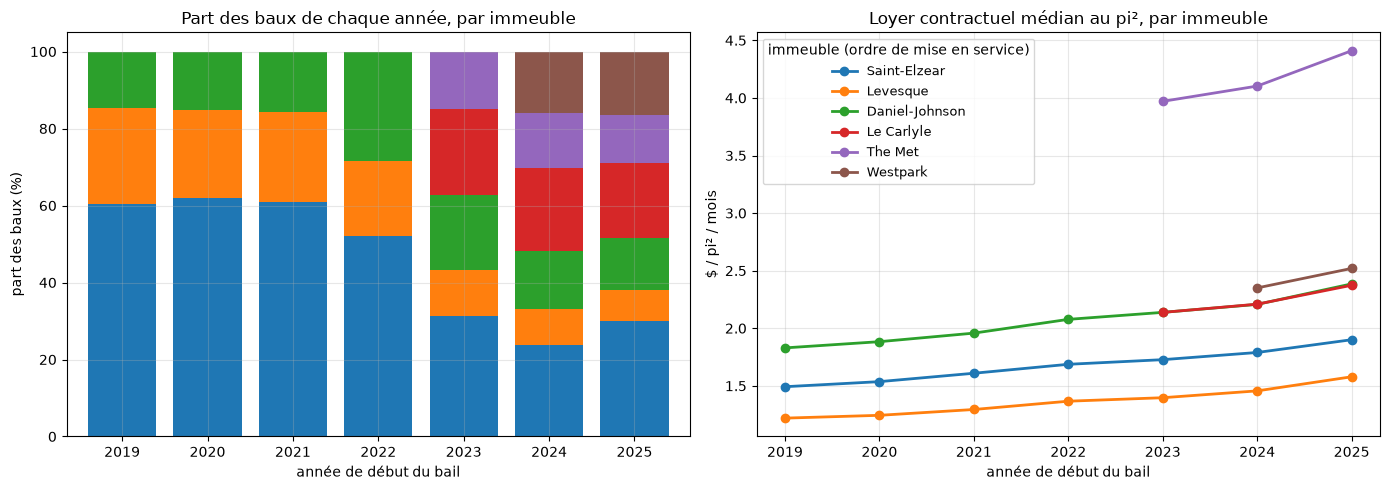

Part des baux par immeuble (%) :
building          Saint-Elzear  Levesque  Daniel-Johnson  Le Carlyle  The Met  Westpark
lease_start_year                                                                       
2019                      60.4      25.0            14.6         0.0      0.0       0.0
2020                      61.9      22.8            15.3         0.0      0.0       0.0
2021                      60.9      23.3            15.8         0.0      0.0       0.0
2022                      52.1      19.4            28.4         0.0      0.0       0.0
2023                      31.3      12.0            19.3        22.4     15.0       0.0
2024                      23.8       9.3            15.1        21.6     14.2      16.0
2025                      30.1       8.0            13.6        19.3     12.5      16.5


In [26]:
# Figure 11.1 : part des baux par immeuble et loyer contractuel médian au pi², par année.
lease_share_by_building = (pd.crosstab(analysis_leases.lease_start_year, analysis_leases.building, normalize="index")
                           .reindex(columns=BUILDING_ORDER, fill_value=0) * TO_PERCENT)
rent_per_sqft_by_building = analysis_leases.pivot_table(index="lease_start_year", columns="building",
                                                        values="contract_rent_per_sqft", aggfunc="median")[BUILDING_ORDER]

fig, (ax_share, ax_psf) = plt.subplots(1, 2, figsize=(14, 5))
lease_share_by_building.plot.bar(stacked=True, ax=ax_share, width=0.8, legend=False,
                                 color=[BUILDING_COLORS[b] for b in BUILDING_ORDER])
ax_share.set(title="Part des baux de chaque année, par immeuble", xlabel="année de début du bail", ylabel="part des baux (%)")
ax_share.tick_params(axis="x", rotation=0)

for building in BUILDING_ORDER:
    ax_psf.plot(rent_per_sqft_by_building.index, rent_per_sqft_by_building[building], "o-", lw=2,
                color=BUILDING_COLORS[building], label=building)
ax_psf.set(title="Loyer contractuel médian au pi², par immeuble", xlabel="année de début du bail", ylabel="$ / pi² / mois")
ax_psf.legend(title="immeuble (ordre de mise en service)", fontsize=9)
for ax in (ax_share, ax_psf):
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Part des baux par immeuble (%) :")
print(lease_share_by_building.round(1).to_string())

**Lecture de la figure 11.1.**

- **De 2019 à 2021, la composition est stable** : environ 60 % des baux viennent de Saint-Elzéar, 23 % de Lévesque et 15 % de Daniel-Johnson.
- **En 2022, la part de Daniel-Johnson double** (de 16 % à 28 %), avec l'arrivée de sa deuxième phase, `dj2`.
- **En 2023, Le Carlyle et The Met représentent d'un coup 37 % des baux.** En 2024, Westpark ajoute 16 %. Plus de la moitié des baux de 2024 viennent d'immeubles absents en 2022.
- **En 2025, la part de Saint-Elzéar remonte** (de 24 % à 30 %), avec la mise en service de sa troisième phase, `stelz3`.
- **À droite, dans chaque immeuble, le loyer au pi² progresse régulièrement**, sans saut en 2023. Les nouveaux immeubles se louent en revanche beaucoup plus cher au pi² que les immeubles de Laval : environ 4 $ pour The Met, contre 1,2 $ à 1,9 $ à Laval.

Aucun immeuble n'augmente de 10 % en 2023. Le saut de la médiane globale ne peut donc venir que des **poids** : l'arrivée massive de baux chers.

### 11.2 Le paradoxe : des unités plus petites, un loyer médian plus élevé

Si la hausse de la médiane reflétait une vraie hausse de prix, les caractéristiques des appartements loués resteraient à peu près les mêmes. La figure 11.2 suit, année par année et tous baux confondus, le loyer médian, la superficie médiane et le loyer médian au pi². Les lignes pointillées rouges marquent la mise en service d'un immeuble.

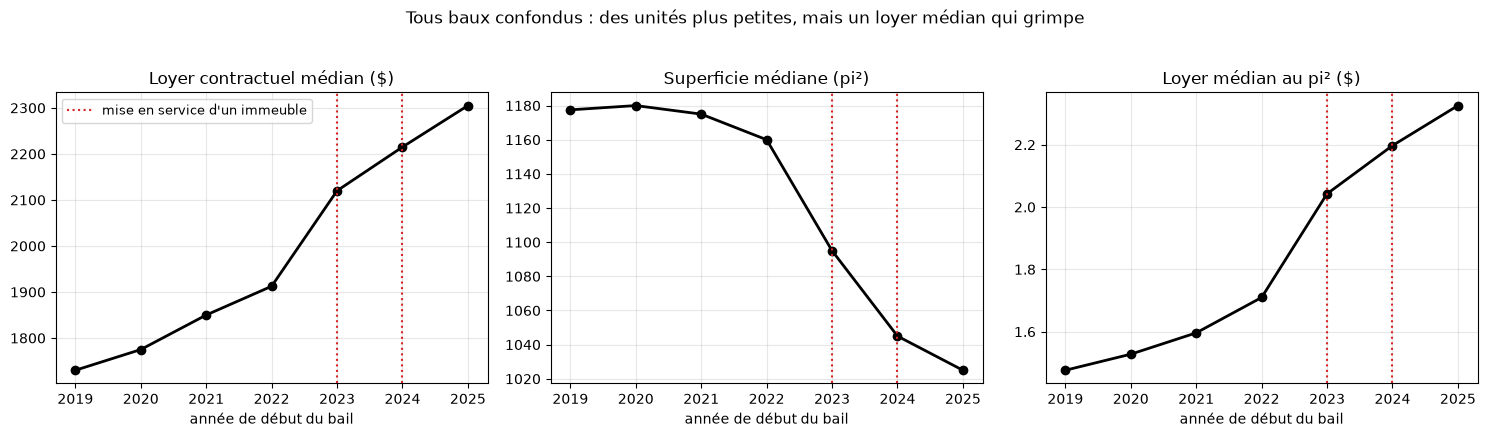

                  median_contract_rent  median_sqft  median_rent_per_sqft  share_two_bedrooms_plus
lease_start_year                                                                                  
2019                            1730.0       1177.5                  1.48                    78.66
2020                            1775.0       1180.0                  1.53                    77.75
2021                            1850.0       1175.0                  1.60                    78.39
2022                            1912.5       1160.0                  1.71                    72.51
2023                            2120.0       1095.0                  2.04                    62.63
2024                            2215.0       1045.0                  2.20                    62.20
2025                            2305.0       1025.0                  2.33                    60.23


In [27]:
# Figure 11.2 : ce que font la taille des unités, le loyer médian et le loyer au pi² d'une année à l'autre.
yearly_profile = analysis_leases.groupby("lease_start_year").agg(
    median_contract_rent=(CONTRACT_RENT_COL, "median"),
    median_sqft=("sqft", "median"),
    median_rent_per_sqft=("contract_rent_per_sqft", "median"),
    share_two_bedrooms_plus=("bedrooms", lambda beds: (beds >= 2).mean() * TO_PERCENT))
PREMIUM_ENTRY_YEARS = sorted(leases_enriched.groupby("building")[LEASE_START_COL].min().dt.year.loc[lambda y: y > FIRST_ANALYSIS_YEAR].unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [("median_contract_rent", "Loyer contractuel médian ($)"),
          ("median_sqft", "Superficie médiane (pi²)"),
          ("median_rent_per_sqft", "Loyer médian au pi² ($)")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(yearly_profile.index, yearly_profile[col], "o-", lw=2, color="black")
    for entry_year in PREMIUM_ENTRY_YEARS:
        ax.axvline(entry_year, color="tab:red", ls=":", lw=1.5,
                   label="mise en service d'un immeuble" if entry_year == PREMIUM_ENTRY_YEARS[0] else None)
    ax.set(title=title, xlabel="année de début du bail")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle("Tous baux confondus : des unités plus petites, mais un loyer médian qui grimpe", y=1.03)
plt.tight_layout()
plt.show()

print(yearly_profile.round(2).to_string())

**Lecture de la figure 11.2.** De 2019 à 2025, la superficie médiane des unités louées **baisse d'environ 13 %** (de 1 178 à 1 025 pi²), et la part des 2 chambres et plus passe de 79 % à 60 %. Pourtant, le loyer médian **augmente d'environ 33 %**. Le loyer au pi² casse sa tendance précisément en 2023 et en 2024, les années de mise en service.

Une hausse de prix ne rend pas les appartements plus petits. La médiane compare des appartements **différents** d'une année à l'autre : elle mesure d'abord *quels* appartements ont été loués.

### 11.3 Décomposition chiffrée : effet prix et effet de composition

Pour chiffrer les deux effets, on construit un **indice à composition fixe** (de type Laspeyres) :

1. On découpe les baux en **cellules** `prop_code × bedrooms`. Par exemple, une cellule regroupe tous les 2 chambres de `stelz2`.
2. Pour l'année *t*, on calcule le loyer moyen de chaque cellule. On le pondère par le **nombre de baux de l'année *t − 1*** dans cette cellule. On compare avec le même calcul pour *t − 1*. Seules les cellules présentes les deux années entrent dans le calcul.
3. L'**effet prix** est la variation de ce loyer moyen à composition fixe. L'**effet de composition** est ce qui reste de la variation naïve : `(1 + naïve) / (1 + prix) − 1`.

**Pourquoi ces choix.**

- **Des cellules par code de propriété plutôt que par immeuble.** C'est la même clé que l'appariement des baux. Les phases ajoutées à un immeuble existant (`dj2` en 2022, `stelz3` en 2025) deviennent ainsi des cellules nouvelles, au lieu d'être mélangées aux anciennes. Un essai avec des cellules par immeuble donnait un accord moins bon avec la mesure à unité constante.
- **La moyenne plutôt que la médiane.** Seule la moyenne se décompose proprement. La médiane naïve est affichée à titre de référence.

La colonne `leases_in_new_cells_pct` indique la part des baux de l'année qui tombent dans une cellule absente l'année précédente. On ajoute enfin, pour comparaison, la médiane à unité constante des paires comparables (section 10).

In [28]:
# Décomposition de la variation naïve : effet prix (composition fixe) et effet de composition.
MIX_CELL_COLS = ["prop_code", "bedrooms"]   # une cellule = un code de propriété × un nombre de chambres


def decompose_mix(lease_table, rent_col, cell_cols, years):
    # Pour chaque année : variation naïve (moyenne et médiane) et variation à composition fixe (pondération de l'année précédente).
    rows = []
    for year in years[1:]:
        previous = lease_table[lease_table.lease_start_year == year - 1]
        current = lease_table[lease_table.lease_start_year == year]
        previous_cells = previous.groupby(cell_cols)[rent_col].agg(["mean", "size"])
        current_cells = current.groupby(cell_cols)[rent_col].mean()
        common_cells = previous_cells.index.intersection(current_cells.index)
        base_weights = previous_cells.loc[common_cells, "size"] / previous_cells.loc[common_cells, "size"].sum()

        fixed_composition = ((base_weights * current_cells.loc[common_cells]).sum()
                             / (base_weights * previous_cells.loc[common_cells, "mean"]).sum() - 1)
        naive_mean = current[rent_col].mean() / previous[rent_col].mean() - 1
        naive_median = current[rent_col].median() / previous[rent_col].median() - 1
        in_new_cells = ~current.set_index(cell_cols).index.isin(previous_cells.index)
        rows.append({"year": year,
                     "naive_median_pct": naive_median * TO_PERCENT,
                     "naive_mean_pct": naive_mean * TO_PERCENT,
                     "fixed_composition_pct": fixed_composition * TO_PERCENT,
                     "composition_effect_pct": ((1 + naive_mean) / (1 + fixed_composition) - 1) * TO_PERCENT,
                     "leases_in_new_cells_pct": in_new_cells.mean() * TO_PERCENT})
    return pd.DataFrame(rows).set_index("year")


mix_decomposition = decompose_mix(analysis_leases, CONTRACT_RENT_COL, MIX_CELL_COLS, ANALYSIS_YEARS)
mix_decomposition["same_unit_median_contract_pct"] = (comparable_pairs.groupby("lease_start_year")
                                                      .contract_growth_pct.median().reindex(mix_decomposition.index))
print(mix_decomposition.round(2).to_string())

      naive_median_pct  naive_mean_pct  fixed_composition_pct  composition_effect_pct  leases_in_new_cells_pct  same_unit_median_contract_pct
year                                                                                                                                         
2020              2.60            3.64                   3.30                    0.33                     0.00                           3.31
2021              4.23            4.61                   4.53                    0.08                     0.00                           4.60
2022              3.38            4.67                   5.28                   -0.58                    15.40                           5.64
2023             10.85           11.93                   1.92                    9.83                    37.37                           2.33
2024              4.48            3.90                   3.77                    0.12                    15.96                           3.49
2025  

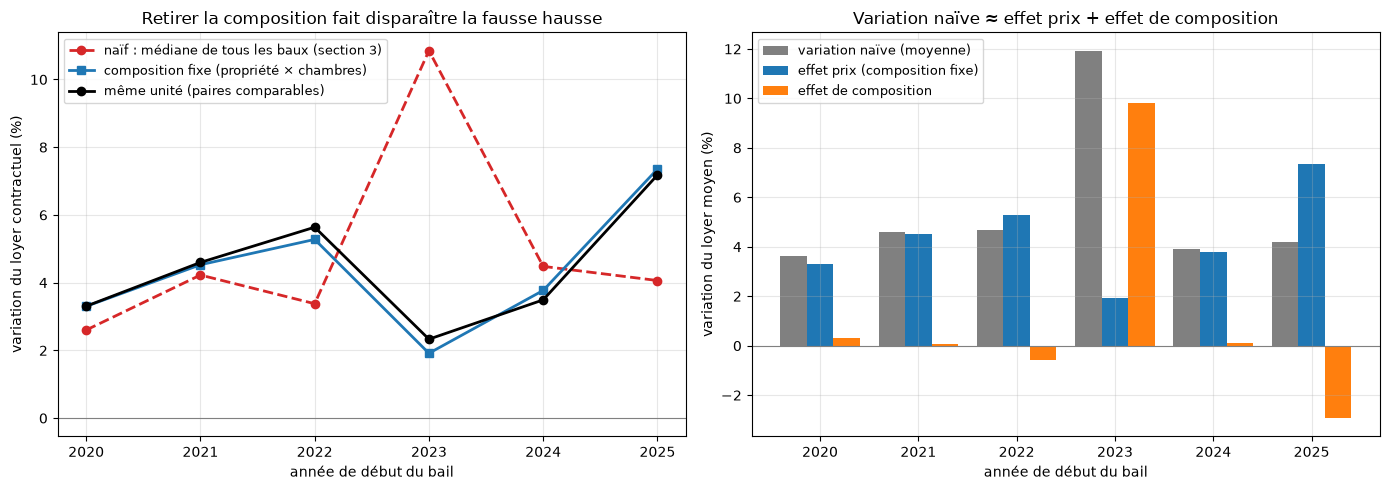

In [29]:
# Figure 11.3 : trois façons de mesurer la hausse, et décomposition de la variation naïve.
fig, (ax_lines, ax_bars) = plt.subplots(1, 2, figsize=(14, 5))
years = mix_decomposition.index

ax_lines.plot(years, mix_decomposition.naive_median_pct, "o--", lw=2, color="tab:red", label="naïf : médiane de tous les baux (section 3)")
ax_lines.plot(years, mix_decomposition.fixed_composition_pct, "s-", lw=2, color="tab:blue", label="composition fixe (propriété × chambres)")
ax_lines.plot(years, mix_decomposition.same_unit_median_contract_pct, "o-", lw=2, color="black", label="même unité (paires comparables)")
ax_lines.axhline(0, color="grey", lw=0.8)
ax_lines.set(title="Retirer la composition fait disparaître la fausse hausse", xlabel="année de début du bail",
             ylabel="variation du loyer contractuel (%)")
ax_lines.legend(fontsize=9)

BAR_WIDTH = 0.27
bar_specs = [("naive_mean_pct", "variation naïve (moyenne)", "grey"),
             ("fixed_composition_pct", "effet prix (composition fixe)", "tab:blue"),
             ("composition_effect_pct", "effet de composition", "tab:orange")]
for offset, (col, label, color) in zip((-BAR_WIDTH, 0, BAR_WIDTH), bar_specs):
    ax_bars.bar(years + offset, mix_decomposition[col], width=BAR_WIDTH, color=color, label=label)
ax_bars.axhline(0, color="grey", lw=0.8)
ax_bars.set(title="Variation naïve ≈ effet prix + effet de composition", xlabel="année de début du bail", ylabel="variation du loyer moyen (%)")
ax_bars.legend(fontsize=9)
for ax in (ax_lines, ax_bars):
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 11.3.**
- **En 2023, la variation naïve est presque entièrement un effet de composition** : environ 10 points sur 12, l'effet prix n'étant que d'environ 2 %. Plus du tiers des baux de 2023 tombent dans des cellules absentes en 2022.
- **Deux méthodes indépendantes donnent le même résultat** : l'indice à composition fixe (moyennes de cellules) et la mesure à unité constante (chaque appartement comparé à lui-même) se suivent à moins d'un point chaque année.
- **La composition joue dans les deux sens.** En 2025, l'arrivée de `stelz3` donne plus de poids à Saint-Elzéar, moins cher : la médiane naïve affiche environ 4 % pour une vraie hausse contractuelle d'environ 7 %. L'erreur de la médiane naïve change donc de signe, ce qui la rend inutilisable pour prévoir.

### 11.4 Vérification : sans nouveaux immeubles, que devient la médiane naïve ?

Dernier test : on recalcule la médiane naïve sur les seuls **codes de propriété présents depuis 2019**. La liste est déterminée par le code, à partir de la date du premier bail. Si l'arrivée des nouveaux immeubles explique la fausse hausse de 2023, celle-ci doit disparaître sur ce sous-ensemble.

Codes de propriété présents depuis 2019 : ['dj1', 'levesque', 'stelz1', 'stelz2']
                  naive_median_all_pct  naive_median_stable_pct  same_unit_median_stable_pct
lease_start_year                                                                            
2020                              2.60                     2.60                         3.31
2021                              4.23                     4.23                         4.60
2022                              3.38                     4.86                         5.64
2023                             10.85                     0.77                         2.40
2024                              4.48                     3.32                         3.56
2025                              4.06                     4.21                         7.35


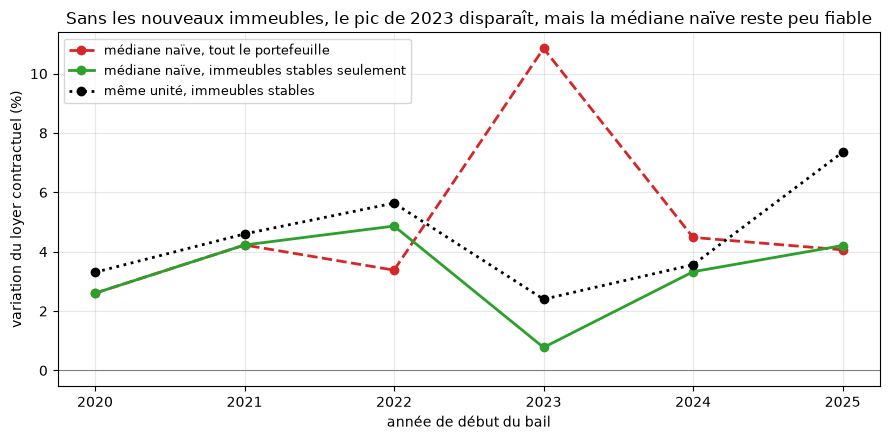

In [30]:
# Vérification : la médiane naïve, recalculée sur les seuls codes de propriété présents depuis le début de la période.
first_lease_year_by_prop = leases_enriched.groupby("prop_code").lease_start_year.min()
STABLE_PROP_CODES = first_lease_year_by_prop[first_lease_year_by_prop <= FIRST_ANALYSIS_YEAR].index.tolist()
stable_leases = analysis_leases[analysis_leases.prop_code.isin(STABLE_PROP_CODES)]
stable_pairs = comparable_pairs[comparable_pairs.prop_code.isin(STABLE_PROP_CODES)]

stable_panel_check = pd.DataFrame({
    "naive_median_all_pct": analysis_leases.groupby("lease_start_year")[CONTRACT_RENT_COL].median().pct_change() * TO_PERCENT,
    "naive_median_stable_pct": stable_leases.groupby("lease_start_year")[CONTRACT_RENT_COL].median().pct_change() * TO_PERCENT,
    "same_unit_median_stable_pct": stable_pairs.groupby("lease_start_year").contract_growth_pct.median(),
}).loc[ANALYSIS_YEARS[1:]]

print("Codes de propriété présents depuis", FIRST_ANALYSIS_YEAR, ":", STABLE_PROP_CODES)
print(stable_panel_check.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(stable_panel_check.index, stable_panel_check.naive_median_all_pct, "o--", lw=2, color="tab:red", label="médiane naïve, tout le portefeuille")
ax.plot(stable_panel_check.index, stable_panel_check.naive_median_stable_pct, "o-", lw=2, color="tab:green", label="médiane naïve, immeubles stables seulement")
ax.plot(stable_panel_check.index, stable_panel_check.same_unit_median_stable_pct, "o:", lw=2, color="black", label="même unité, immeubles stables")
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Sans les nouveaux immeubles, le pic de 2023 disparaît, mais la médiane naïve reste peu fiable",
       xlabel="année de début du bail", ylabel="variation du loyer contractuel (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 11.4.**

- **Le pic de 2023 disparaît.** Sur les immeubles stables, la médiane naïve passe de +10,8 % à moins de 1 %. C'est la confirmation directe que la fausse hausse venait de l'arrivée de Le Carlyle et de The Met.
- **La médiane naïve reste toutefois éloignée de la mesure à unité constante**, même sur les immeubles stables, pour deux raisons :
  - **La composition bouge aussi à l'intérieur des immeubles stables.** En 2025, la part des baux de `stelz1` passe d'environ 27 % à 12 %, parce que moins de ses unités arrivent en fin de bail cette année-là.
  - **La médiane d'une population hétérogène fait des sauts.** Elle dépend de l'appartement qui se trouve au milieu du classement. En 2023, sur les immeubles stables, elle n'augmente que de 0,8 %, alors que le loyer moyen augmente d'environ 2 % et que la mesure à unité constante donne 2,4 %.

Il ne suffit donc pas d'exclure les nouveaux immeubles. Seule la comparaison d'un appartement **à lui-même** neutralise complètement la composition.

**Bilan de la section 11.** La médiane annuelle de tous les baux mesure surtout *quels* appartements ont été loués : sa hausse de 2023 vient à plus de 80 % de l'arrivée de Le Carlyle et de The Met, et son erreur change de signe selon les immeubles qui entrent (négative en 2022 et en 2025). Deux méthodes indépendantes qui neutralisent la composition, l'indice à composition fixe et la mesure à unité constante, s'accordent à moins d'un point chaque année : c'est l'argument central de la définition de la section 8.

## 12. Croissance à unité constante

La section 11 a montré que seule la comparaison d'un appartement à lui-même mesure le prix. Cette section étudie cette mesure en détail :

1. **12.1** : les séries annuelles, en loyer contractuel, effectif et « loyer seulement » ;
2. **12.2** : pourquoi la croissance contractuelle et la croissance effective divergent à partir de 2024 ;
3. **12.3** : les renouvellements et les relocations ;
4. **12.4** : The Met et les règles de l'Ontario ;
5. **12.5** : la robustesse de la mesure retenue face aux choix de la section 8 ;
6. **12.6** : le pont entre la hausse contractuelle et la hausse effective, catégorie de concession par catégorie.

On utilise les paires comparables de la section 10, sur la période 2019 à 2025.

### 12.1 Séries annuelles à unité constante

Pour chaque année de début du nouveau bail, on calcule la **médiane** de la variation par bail (`GROWTH_STATISTIC`) pour les trois mesures de loyer. On ajoute comme contrôle la **moyenne pondérée par le loyer**, soit la variation du total des loyers des paires, plus proche d'une logique de revenus. Cette étape crée `growth_pairs`, les paires comparables limitées à la période d'analyse.

In [31]:
# Séries annuelles à unité constante (paires comparables), pour les trois mesures de loyer.
growth_pairs = comparable_pairs[comparable_pairs.lease_start_year.between(FIRST_ANALYSIS_YEAR, LAST_OBSERVED_YEAR)].copy()


def rent_weighted_growth_pct(pairs_table, rent_col):
    # Variation du total des loyers des paires : chaque paire pèse selon son loyer précédent (contrôle de la médiane).
    return (pairs_table[rent_col].sum() / pairs_table[f"prev_{rent_col}"].sum() - 1) * TO_PERCENT


same_unit_growth = growth_pairs.groupby("lease_start_year").agg(
    pairs=("effective_growth_pct", "size"),
    contract_median_pct=("contract_growth_pct", GROWTH_STATISTIC),
    effective_median_pct=("effective_growth_pct", GROWTH_STATISTIC),
    rent_only_median_pct=("rent_only_growth_pct", GROWTH_STATISTIC))
same_unit_growth["effective_weighted_pct"] = growth_pairs.groupby("lease_start_year").apply(
    rent_weighted_growth_pct, rent_col=EFFECTIVE_RENT_COL)
same_unit_growth["contract_minus_effective_pts"] = same_unit_growth.contract_median_pct - same_unit_growth.effective_median_pct
print(same_unit_growth.round(2).to_string())

                  pairs  contract_median_pct  effective_median_pct  rent_only_median_pct  effective_weighted_pct  contract_minus_effective_pts
lease_start_year                                                                                                                              
2019                155                 2.26                  1.63                  1.77                    1.55                          0.63
2020                321                 3.31                  3.12                  3.37                    2.90                          0.18
2021                348                 4.60                  3.65                  4.02                    3.76                          0.95
2022                339                 5.64                  4.72                  5.47                    4.71                          0.92
2023                397                 2.33                  2.08                  2.35                    2.17                          0.25

/tmp/ipykernel_171208/2747284062.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  same_unit_growth["effective_weighted_pct"] = growth_pairs.groupby("lease_start_year").apply(


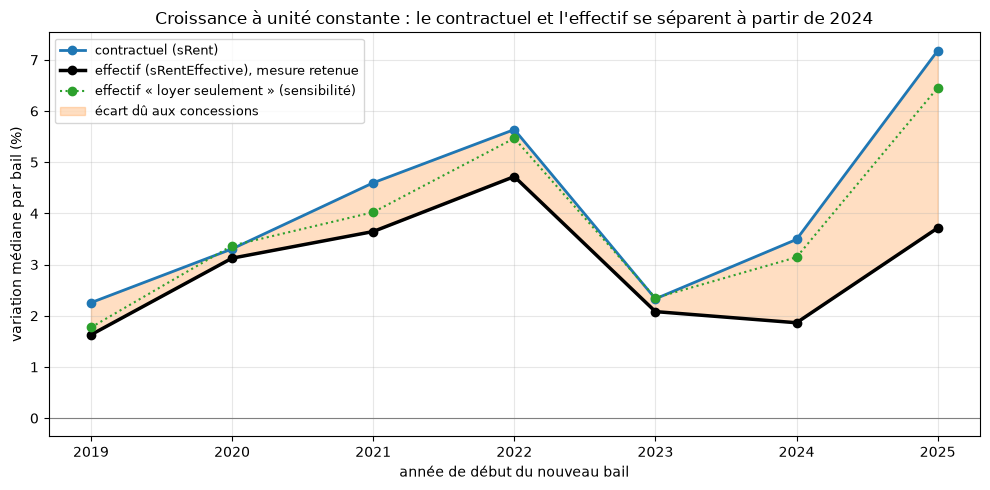

In [32]:
# Figure 12.1 : croissance à unité constante, loyer contractuel vs loyer effectif.
fig, ax = plt.subplots(figsize=(10, 5))
years = same_unit_growth.index
ax.plot(years, same_unit_growth.contract_median_pct, "o-", lw=2, color="tab:blue", label="contractuel (sRent)")
ax.plot(years, same_unit_growth.effective_median_pct, "o-", lw=2.5, color="black", label="effectif (sRentEffective), mesure retenue")
ax.plot(years, same_unit_growth.rent_only_median_pct, "o:", lw=1.5, color="tab:green", label="effectif « loyer seulement » (sensibilité)")
ax.fill_between(years, same_unit_growth.effective_median_pct, same_unit_growth.contract_median_pct,
                color="tab:orange", alpha=0.25, label="écart dû aux concessions")
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Croissance à unité constante : le contractuel et l'effectif se séparent à partir de 2024",
       xlabel="année de début du nouveau bail", ylabel="variation médiane par bail (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 12.1.**

- **Jusqu'en 2023, les deux mesures évoluent ensemble.** L'écart reste inférieur à un point par an.
- **En 2024 et en 2025, elles se séparent nettement.** En 2025, la hausse contractuelle est d'environ 7,2 %, mais la hausse effective n'est que d'environ 3,7 %. Les concessions absorbent donc près de la moitié de la hausse affichée.
- **La moyenne pondérée par le loyer confirme la médiane** à 0,2 point près chaque année. La mesure ne dépend donc ni de quelques paires atypiques, ni du choix de la statistique.
- **2023 est un creux** : environ 2 %, en contractuel comme en effectif, entre deux années plus fortes.
- **La variante « loyer seulement » reste proche du contractuel**, ce qui veut dire que les rabais de loyer proprement dits pèsent peu sur la croissance. On y revient en 12.5.

### 12.2 Pourquoi la croissance contractuelle et la croissance effective divergent à partir de 2024

Notons *s* la part du loyer contractuel cédée en concessions, déduite de `effective_rent` : `s = 1 − effective_rent / contract_rent`. Par construction, `effective_rent = contract_rent × (1 − s)`. Pour une paire, on a donc l'**identité exacte** :

$$1 + g_{\text{effectif}} = (1 + g_{\text{contractuel}}) \times \frac{1 - s_{\text{nouveau}}}{1 - s_{\text{précédent}}}$$

Ce qui fait diverger les deux croissances n'est donc pas le *niveau* des concessions, mais leur **variation entre l'ancien et le nouveau bail**. Si les deux baux cèdent la même part, les deux croissances sont égales, même avec beaucoup de concessions. Cette étape ajoute à `growth_pairs` la part implicite de chaque bail de la paire, ainsi que l'écart entre les deux croissances.

On vérifie aussi si les concessions sont devenues plus **fréquentes** ou plus **grosses** : la section 5 suggérait que c'est leur taille qui change la donne.

In [33]:
# Identité exacte : 1 + croissance effective = (1 + croissance contractuelle) × (1 − s_nouveau) / (1 − s_précédent),
# où s = 1 − effective_rent / contract_rent est la part du loyer contractuel cédée en concessions (implicite dans effective_rent).
for prefix in ("", "prev_"):
    growth_pairs[f"{prefix}implied_concession_share"] = 1 - growth_pairs[f"{prefix}{EFFECTIVE_RENT_COL}"] / growth_pairs[f"{prefix}{CONTRACT_RENT_COL}"]
growth_pairs["concession_share_change_pts"] = (growth_pairs.implied_concession_share - growth_pairs.prev_implied_concession_share) * TO_PERCENT
growth_pairs["concession_drag_pts"] = growth_pairs.effective_growth_pct - growth_pairs.contract_growth_pct

identity_check = ((1 + growth_pairs.contract_growth_pct / TO_PERCENT)
                  * (1 - growth_pairs.implied_concession_share) / (1 - growth_pairs.prev_implied_concession_share)
                  - (1 + growth_pairs.effective_growth_pct / TO_PERCENT)).abs().max()
print(f"Écart max à l'identité : {identity_check:.2e}")

concession_dynamics = growth_pairs.groupby("lease_start_year").agg(
    prev_share_pct=("prev_implied_concession_share", lambda s: s.mean() * TO_PERCENT),
    new_share_pct=("implied_concession_share", lambda s: s.mean() * TO_PERCENT),
    mean_share_change_pts=("concession_share_change_pts", "mean"),
    mean_contract_pct=("contract_growth_pct", "mean"),
    mean_effective_pct=("effective_growth_pct", "mean"),
    mean_drag_pts=("concession_drag_pts", "mean"))
print(concession_dynamics.round(2).to_string())

# Fréquence ou taille ? Tous les baux, par année de début.
leases_by_year = leases_enriched[leases_enriched.lease_start_year.between(FIRST_ANALYSIS_YEAR, LAST_OBSERVED_YEAR)]
implied_share = 1 - leases_by_year[EFFECTIVE_RENT_COL] / leases_by_year[CONTRACT_RENT_COL]
frequency_vs_size = pd.DataFrame({
    "with_concession_pct": leases_by_year.groupby("lease_start_year").has_concession.mean() * TO_PERCENT,
    "share_when_granted_pct": implied_share[leases_by_year.has_concession].groupby(leases_by_year.lease_start_year).mean() * TO_PERCENT,
})
print("\nFréquence et taille des concessions (tous les baux) :")
print(frequency_vs_size.round(2).to_string())

Écart max à l'identité : 2.22e-16
                  prev_share_pct  new_share_pct  mean_share_change_pts  mean_contract_pct  mean_effective_pct  mean_drag_pts
lease_start_year                                                                                                            
2019                        1.32           1.80                   0.47               2.04                1.58          -0.46
2020                        1.75           2.06                   0.30               3.13                2.85          -0.28
2021                        2.01           2.66                   0.65               4.51                3.87          -0.64
2022                        2.75           3.38                   0.64               5.44                4.82          -0.62
2023                        3.22           3.26                   0.04               2.12                2.16           0.04
2024                        3.66           5.48                   1.83               3.83  

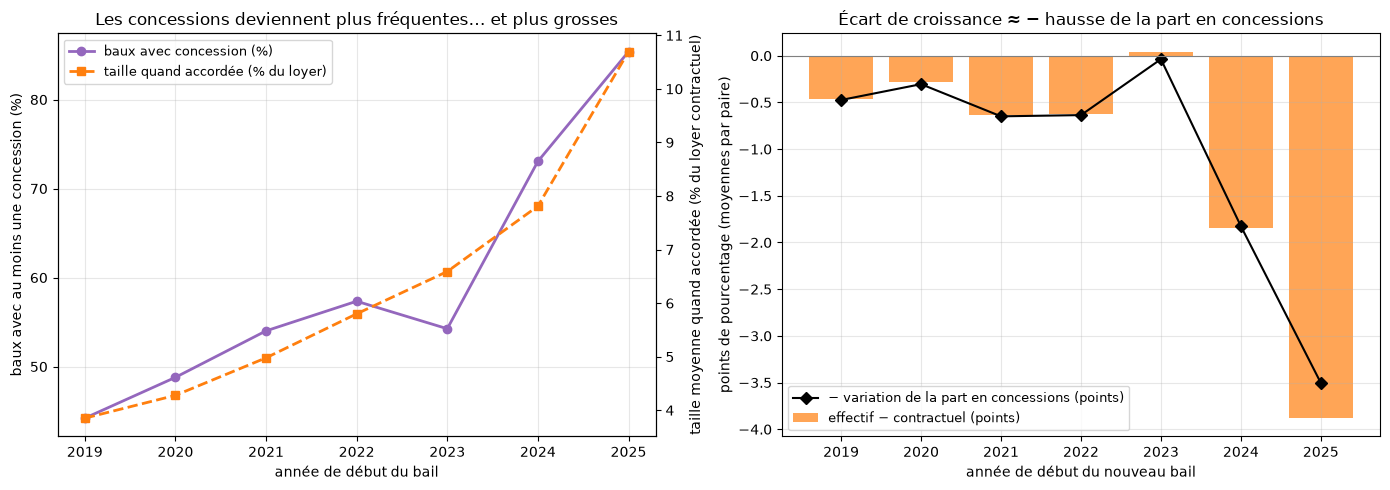

In [34]:
# Figure 12.2 : la divergence s'explique par la hausse de la part cédée en concessions entre l'ancien et le nouveau bail.
fig, (ax_share, ax_drag) = plt.subplots(1, 2, figsize=(14, 5))
years = concession_dynamics.index

ax_share.plot(years, frequency_vs_size.with_concession_pct, "o-", lw=2, color="tab:purple", label="baux avec concession (%)")
ax_share.set(xlabel="année de début du bail", ylabel="baux avec au moins une concession (%)",
             title="Les concessions deviennent plus fréquentes… et plus grosses")
ax_size = ax_share.twinx()
ax_size.plot(years, frequency_vs_size.share_when_granted_pct, "s--", lw=2, color="tab:orange", label="taille quand accordée (% du loyer)")
ax_size.set_ylabel("taille moyenne quand accordée (% du loyer contractuel)")
handles = ax_share.get_legend_handles_labels()[0] + ax_size.get_legend_handles_labels()[0]
ax_share.legend(handles, [h.get_label() for h in handles], fontsize=9, loc="upper left")

ax_drag.bar(years, concession_dynamics.mean_drag_pts, color="tab:orange", alpha=0.7, label="effectif − contractuel (points)")
ax_drag.plot(years, -concession_dynamics.mean_share_change_pts, "kD-", label="− variation de la part en concessions (points)")
ax_drag.axhline(0, color="grey", lw=0.8)
ax_drag.set(title="Écart de croissance ≈ − hausse de la part en concessions", xlabel="année de début du nouveau bail",
            ylabel="points de pourcentage (moyennes par paire)")
ax_drag.legend(fontsize=9)
for ax in (ax_share, ax_drag):
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 12.2.**
- **L'identité est exacte** (écart de l'ordre de 10⁻¹⁶) : à droite, l'écart entre croissance effective et croissance contractuelle suit point pour point la hausse de la part cédée en concessions.
- **Jusqu'en 2023, cette part progresse d'environ un demi-point par an ; en 2024 et en 2025, elle bondit** d'environ 1,8 puis 3,5 points, et la croissance effective perd autant.
- **Les concessions deviennent à la fois plus fréquentes et plus grosses** (à gauche) : 85 % des baux en ont une en 2025, contre 54 % en 2023, et elles valent alors en moyenne près de 11 % du loyer, contre 6,6 %.

**Pour un propriétaire**, le loyer contractuel est la base des hausses futures, et le loyer effectif ce qui est encaissé : on cite l'effectif pour budgéter (section 8). Comme une concession est ponctuelle, la croissance effective de 2026 dépend d'une hypothèse sur leur évolution : elle rejoindrait le contractuel si leur intensité se stabilisait, et le *dépasserait* si elle reculait.

### 12.3 Renouvellements vs relocations

Un **renouvellement** (`is_renewal`) est un locataire en place qui reste. Une **relocation** est un appartement libéré puis reloué à un nouveau locataire, au prix du marché. Les deux n'obéissent pas aux mêmes règles :

- **Au Québec**, la hausse au renouvellement s'appuie sur les paramètres du TAL. Ce sont des références, pas des plafonds : les parties peuvent s'entendre, et sinon le propriétaire peut demander au TAL de fixer le loyer. À la relocation, le loyer est libre en pratique, mais le nouveau locataire peut contester un loyer supérieur au plus bas loyer payé dans les 12 mois précédents.
- **En Ontario**, la ligne directrice encadre le renouvellement, et le loyer est libre à la relocation.

Les paramètres annuels du TAL sont intégrés en section 13. Ici, on compare les deux séries internes.

                 contract_growth_pct          effective_growth_pct         
pair_type                    renewal turnover              renewal turnover
lease_start_year                                                           
2019                            2.60     1.37                 1.98     1.39
2020                            3.59     2.19                 3.37     2.40
2021                            4.84     3.63                 4.05     2.43
2022                            5.86     4.33                 5.27     3.53
2023                            2.59     1.84                 2.30     1.63
2024                            3.03     5.02                 1.47     2.96
2025                            6.56     9.24                 3.03     6.02

Part des renouvellements dans les paires (%) : {2019: 57.4, 2020: 60.1, 2021: 62.1, 2022: 64.0, 2023: 57.4, 2024: 60.1, 2025: 61.2}


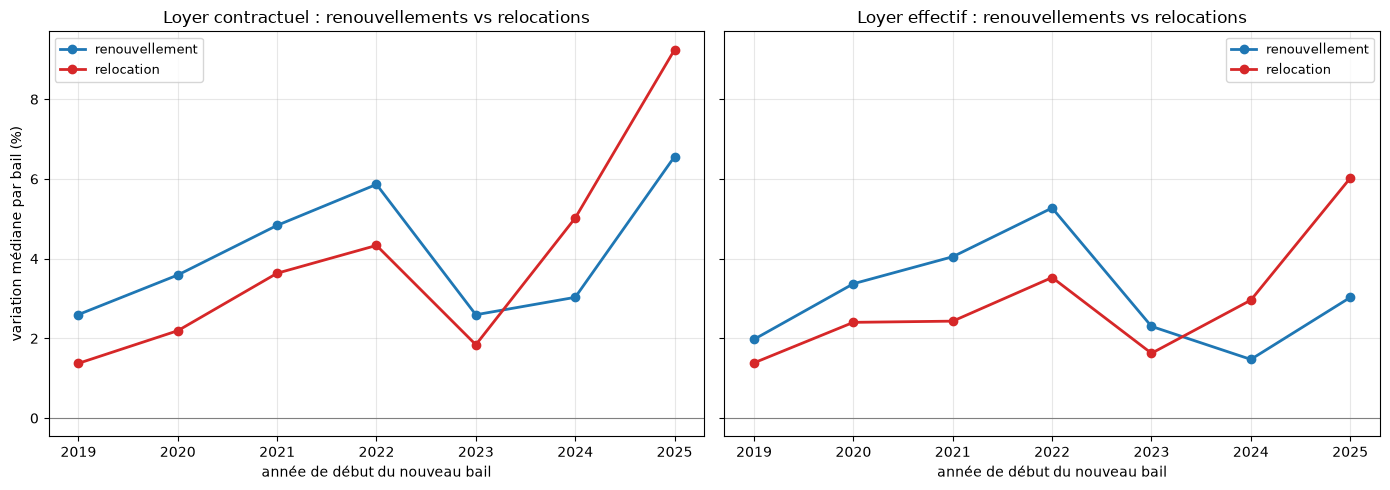

In [35]:
# Renouvellements vs relocations : médianes par année et par type de paire.
PAIR_TYPE_LABELS = {"renewal": "renouvellement", "turnover": "relocation"}
PAIR_TYPE_COLORS = {"renewal": "tab:blue", "turnover": "tab:red"}

growth_by_type = growth_pairs.pivot_table(index="lease_start_year", columns="pair_type",
                                          values=["contract_growth_pct", "effective_growth_pct"], aggfunc=GROWTH_STATISTIC)
renewal_share_pct = growth_pairs.groupby("lease_start_year").is_renewal.mean() * TO_PERCENT
print(growth_by_type.round(2).to_string())
print("\nPart des renouvellements dans les paires (%) :", renewal_share_pct.round(1).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (measure, title) in zip(axes, [("contract_growth_pct", "Loyer contractuel"), ("effective_growth_pct", "Loyer effectif")]):
    for pair_type, label in PAIR_TYPE_LABELS.items():
        ax.plot(growth_by_type.index, growth_by_type[(measure, pair_type)], "o-", lw=2,
                color=PAIR_TYPE_COLORS[pair_type], label=label)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set(title=f"{title} : renouvellements vs relocations", xlabel="année de début du nouveau bail")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
axes[0].set_ylabel("variation médiane par bail (%)")
plt.tight_layout()
plt.show()

**Lecture de la figure 12.3.**

- **De 2019 à 2023, les renouvellements augmentent plus que les relocations.** Les locataires en place reçoivent des hausses régulières, alors que les relocations se font à des loyers de marché qui progressent moins vite.
- **En 2024, l'écart change de camp, puis se creuse en 2025.** En contractuel, les relocations atteignent environ 9,2 %, contre 6,6 % pour les renouvellements. Le marché progresse plus vite que les hausses consenties aux locataires en place : chaque départ permet de rattraper l'écart.
- **Les concessions touchent les deux types de façon comparable.** En 2025, elles retirent environ 3,5 points aux renouvellements et 3,2 points aux relocations. En effectif, l'écart entre les deux types reste donc le même.
- **La part des renouvellements est stable**, entre 57 % et 64 % des paires selon l'année. Les variations de la hausse globale ne viennent donc pas d'un changement de proportion entre les deux types. Une prévision par type, recombinée avec une part d'environ 60 % de renouvellements, est une piste pour la section 14.

### 12.4 The Met et les règles de l'Ontario

The Met est le seul immeuble ontarien. Ses locataires en place relèvent de la **ligne directrice ontarienne**, et non du TAL : on ne transpose donc pas le cadre d'une province à l'autre. Cette ligne directrice vaut 2,5 % en 2023, 2024 et 2025 (ontario.ca). Elle ne s'applique **pas aux unités occupées pour la première fois après le 15 novembre 2018**.

Les premiers baux de The Met datent de 2023, donc ses premiers renouvellements datent de 2024. On compare la distribution de ses hausses au renouvellement à la ligne directrice, avec les cinq immeubles québécois comme repère. Le seuil de 2,5 % n'a évidemment aucune valeur réglementaire au Québec.

                                       renewals  median_contract_pct  above_ontario_guideline_pct
region               lease_start_year                                                            
Québec (5 immeubles) 2023                   228                  2.6                         52.6
                     2024                   340                  3.0                         64.7
                     2025                   399                  6.6                        100.0
The Met (Ontario)    2024                    67                  3.0                         64.2
                     2025                    63                  6.4                        100.0

Premier bail de The Met : 2023-01-01


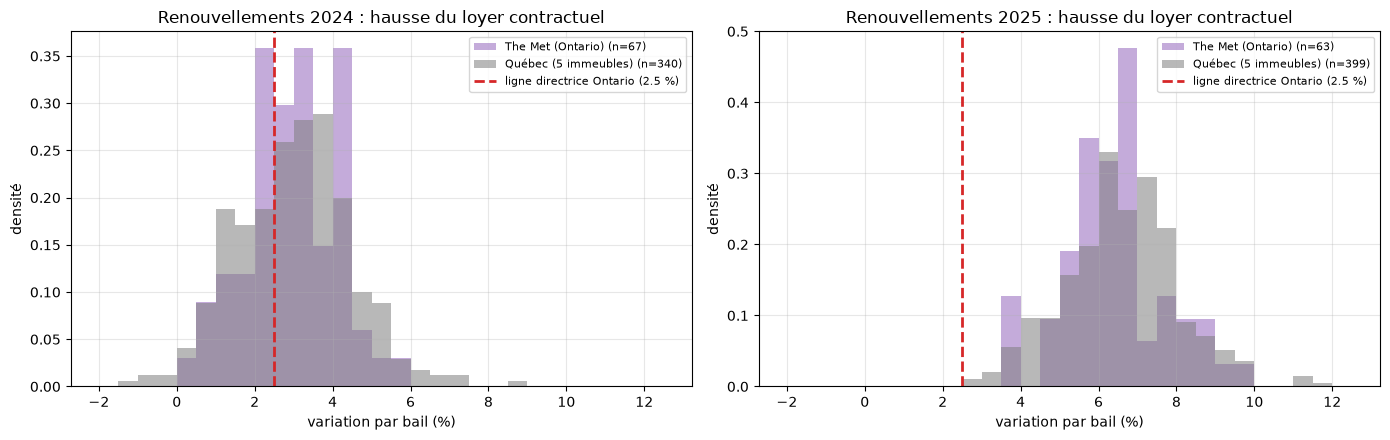

In [36]:
# The Met (Ontario) : les renouvellements respectent-ils la ligne directrice ontarienne ?
# Source : ontario.ca/page/rent-increase-guideline (2,5 % en 2023, 2024 et 2025). La série complète est intégrée en section 13.
ONTARIO_GUIDELINE_PCT = {2023: 2.5, 2024: 2.5, 2025: 2.5}
ONTARIO_PROVINCE = "Ontario"

renewal_pairs = growth_pairs[growth_pairs.is_renewal & growth_pairs.lease_start_year.isin(ONTARIO_GUIDELINE_PCT)].copy()
renewal_pairs["ontario_guideline_pct"] = renewal_pairs.lease_start_year.map(ONTARIO_GUIDELINE_PCT)
renewal_pairs["above_guideline"] = renewal_pairs.contract_growth_pct > renewal_pairs.ontario_guideline_pct
renewal_pairs["region"] = np.where(renewal_pairs.province == ONTARIO_PROVINCE, "The Met (Ontario)", "Québec (5 immeubles)")

print(renewal_pairs.groupby(["region", "lease_start_year"])
      .agg(renewals=("contract_growth_pct", "size"),
           median_contract_pct=("contract_growth_pct", "median"),
           above_ontario_guideline_pct=("above_guideline", lambda s: s.mean() * TO_PERCENT))
      .round(1).to_string())
print("\nPremier bail de The Met :", leases_enriched.loc[leases_enriched.province == ONTARIO_PROVINCE, LEASE_START_COL].min().date())

HISTOGRAM_BINS = np.arange(-2, 13, 0.5)
REGION_COLORS = {"The Met (Ontario)": "tab:purple", "Québec (5 immeubles)": "tab:grey"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
MET_RENEWAL_YEARS = sorted(renewal_pairs.loc[renewal_pairs.province == ONTARIO_PROVINCE, "lease_start_year"].unique())
for ax, year in zip(axes, MET_RENEWAL_YEARS):
    for region, color in REGION_COLORS.items():
        values = renewal_pairs.loc[(renewal_pairs.lease_start_year == year) & (renewal_pairs.region == region), "contract_growth_pct"]
        ax.hist(values, bins=HISTOGRAM_BINS, density=True, alpha=0.55, color=color, label=f"{region} (n={len(values)})")
    ax.axvline(ONTARIO_GUIDELINE_PCT[year], color="tab:red", lw=2, ls="--", label=f"ligne directrice Ontario ({ONTARIO_GUIDELINE_PCT[year]} %)")
    ax.set(title=f"Renouvellements {year} : hausse du loyer contractuel", xlabel="variation par bail (%)", ylabel="densité")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 12.4.**
- **Les renouvellements de The Met dépassent largement la ligne directrice** : 64 % d'entre eux en 2024 et **100 %** en 2025 (médiane d'environ 6,4 %). Sous la ligne directrice, ce serait incompatible avec les règles, sauf autorisations du Tribunal à une échelle peu plausible.
- **L'explication la plus cohérente est l'exemption des immeubles récents** : The Met loue ses premières unités en 2023, bien après le 15 novembre 2018. Ses hausses ont d'ailleurs la même distribution que celles des immeubles québécois : il suit la politique de prix du portefeuille, pas un plafond.

**Hypothèse retenue, énoncée comme telle** (l'extrait ne contient pas la date de première occupation) : The Met est exempté de la ligne directrice. On ne le plafonne donc pas à 2,1 % en 2026 ; on le prévoit au rythme du marché ontarien (section 14).

### 12.5 Robustesse de la mesure retenue

La section 8 a fixé trois choix : la médiane, des paires dont le bail précédent dure 12 mois, et `sRentEffective` tel que fourni. On recalcule la série annuelle en changeant un choix à la fois. Cette étape ajoute aussi à `growth_pairs` un indicateur de cohérence du bail précédent avec ses concessions, pour isoler la limite PromoPay de la section 10.2.

In [37]:
# Robustesse de la mesure retenue (médiane effective, paires comparables) face aux choix de la section 8.
# On ajoute d'abord, pour chaque paire, si le bail précédent est lui aussi cohérent avec ses concessions (limite PromoPay, 10.2).
lease_consistency = leases_enriched.set_index(["unit_id", "unit_lease_seq"]).effective_rent_matches_concessions
previous_lease_key = pd.MultiIndex.from_arrays([growth_pairs.unit_id, growth_pairs.unit_lease_seq - 1])
growth_pairs["prev_effective_rent_matches_concessions"] = lease_consistency.reindex(previous_lease_key).to_numpy()
both_leases_consistent = growth_pairs[growth_pairs.effective_rent_matches_concessions
                                      & growth_pairs.prev_effective_rent_matches_concessions]
all_pairs_in_window = lease_pairs[lease_pairs.lease_start_year.between(FIRST_ANALYSIS_YEAR, LAST_OBSERVED_YEAR)]

robustness = pd.DataFrame({
    "retenue : médiane effective": same_unit_growth.effective_median_pct,
    "moyenne pondérée par le loyer": same_unit_growth.effective_weighted_pct,
    "toutes durées de bail précédent": all_pairs_in_window.groupby("lease_start_year").effective_growth_pct.median(),
    "baux cohérents avec leurs concessions": both_leases_consistent.groupby("lease_start_year").effective_growth_pct.median(),
    "loyer seulement (sans accessoires)": same_unit_growth.rent_only_median_pct,
})
print(robustness.round(2).to_string())
print("\nÉcart maximal à la mesure retenue, par variante (points) :")
print(robustness.sub(robustness.iloc[:, 0], axis=0).abs().max().round(2).to_string())

                  retenue : médiane effective  moyenne pondérée par le loyer  toutes durées de bail précédent  baux cohérents avec leurs concessions  loyer seulement (sans accessoires)
lease_start_year                                                                                                                                                                        
2019                                     1.63                           1.55                             1.74                                   1.62                                1.77
2020                                     3.12                           2.90                             3.16                                   3.04                                3.37
2021                                     3.65                           3.76                             3.64                                   3.70                                4.02
2022                                     4.72                           4.7

**Lecture du tableau de robustesse.**
- **Trois choix techniques changent la série de 0,2 point au plus** : la moyenne pondérée au lieu de la médiane, l'inclusion des paires après un bail de 6, 18 ou 24 mois, et l'exclusion des baux touchés par la limite PromoPay (10.2).
- **Le seul choix qui compte est l'inclusion des concessions accessoires** : sans elles, la hausse de 2025 serait d'environ 6,5 % au lieu de 3,7 %. Ce choix est assumé (section 8), décomposé en 12.6 et présenté comme scénario alternatif en section 14.

### 12.6 De la hausse contractuelle à la hausse effective, catégorie par catégorie

La section 12.5 a montré que l'inclusion des concessions accessoires est le choix qui pèse le plus. Pour le rendre visible, on décompose l'écart entre hausse contractuelle et hausse effective en **retirant les concessions une catégorie à la fois** :

1. **hausse contractuelle** : aucune concession retirée ;
2. moins les **rabais de loyer** : on obtient la mesure « loyer seulement » ;
3. moins les **accessoires** : mesure intermédiaire, calculée par bail ici ;
4. moins les **autres** concessions : on arrive à la **hausse effective** (`sRentEffective`).

Chaque effet est la différence entre les médianes de deux étapes successives. Les effets s'additionnent donc exactement jusqu'à la hausse effective. La dernière étape absorbe aussi le petit écart entre `sRentEffective` et la reconstruction par les concessions (limite PromoPay, 10.2). Cet écart ne dépasse pas 0,2 point par année. Cette étape ajoute à `growth_pairs` la croissance de la mesure intermédiaire.

In [38]:
# Pont entre la hausse contractuelle et la hausse effective : on retire les concessions une catégorie à la fois.
# Mesure intermédiaire : loyer net des rabais de loyer ET des accessoires (calculée par bail, puis appariée comme en 12.5).
LEASE_KEY = ["unit_id", "unit_lease_seq"]
rent_and_ancillary_rent = (leases_enriched[CONTRACT_RENT_COL]
                           - (leases_enriched.rent_discount_value + leases_enriched.ancillary_value) / leases_enriched.term_months)
rent_and_ancillary_by_lease = pd.Series(rent_and_ancillary_rent.to_numpy(), index=pd.MultiIndex.from_frame(leases_enriched[LEASE_KEY]))
current_lease_key = pd.MultiIndex.from_frame(growth_pairs[LEASE_KEY])
growth_pairs["rent_and_ancillary_growth_pct"] = (
    rent_and_ancillary_by_lease.reindex(current_lease_key).to_numpy()
    / rent_and_ancillary_by_lease.reindex(previous_lease_key).to_numpy() - 1) * TO_PERCENT

bridge_medians = growth_pairs.groupby("lease_start_year")[
    ["contract_growth_pct", "rent_only_growth_pct", "rent_and_ancillary_growth_pct", "effective_growth_pct"]].median()
concession_bridge = pd.DataFrame({
    "contract_pct": bridge_medians.contract_growth_pct,
    "rent_discount_effect_pts": bridge_medians.rent_only_growth_pct - bridge_medians.contract_growth_pct,
    "ancillary_effect_pts": bridge_medians.rent_and_ancillary_growth_pct - bridge_medians.rent_only_growth_pct,
    "other_effect_pts": bridge_medians.effective_growth_pct - bridge_medians.rent_and_ancillary_growth_pct,
    "effective_pct": bridge_medians.effective_growth_pct,
})
print(concession_bridge.round(2).to_string())

                  contract_pct  rent_discount_effect_pts  ancillary_effect_pts  other_effect_pts  effective_pct
lease_start_year                                                                                               
2019                      2.26                     -0.48                 -0.06             -0.08           1.63
2020                      3.31                      0.07                  0.02             -0.26           3.12
2021                      4.60                     -0.57                 -0.42              0.04           3.65
2022                      5.64                     -0.17                 -0.16             -0.58           4.72
2023                      2.33                      0.02                 -0.21             -0.06           2.08
2024                      3.49                     -0.35                 -0.52             -0.76           1.86
2025                      7.18                     -0.72                 -1.91             -0.83        

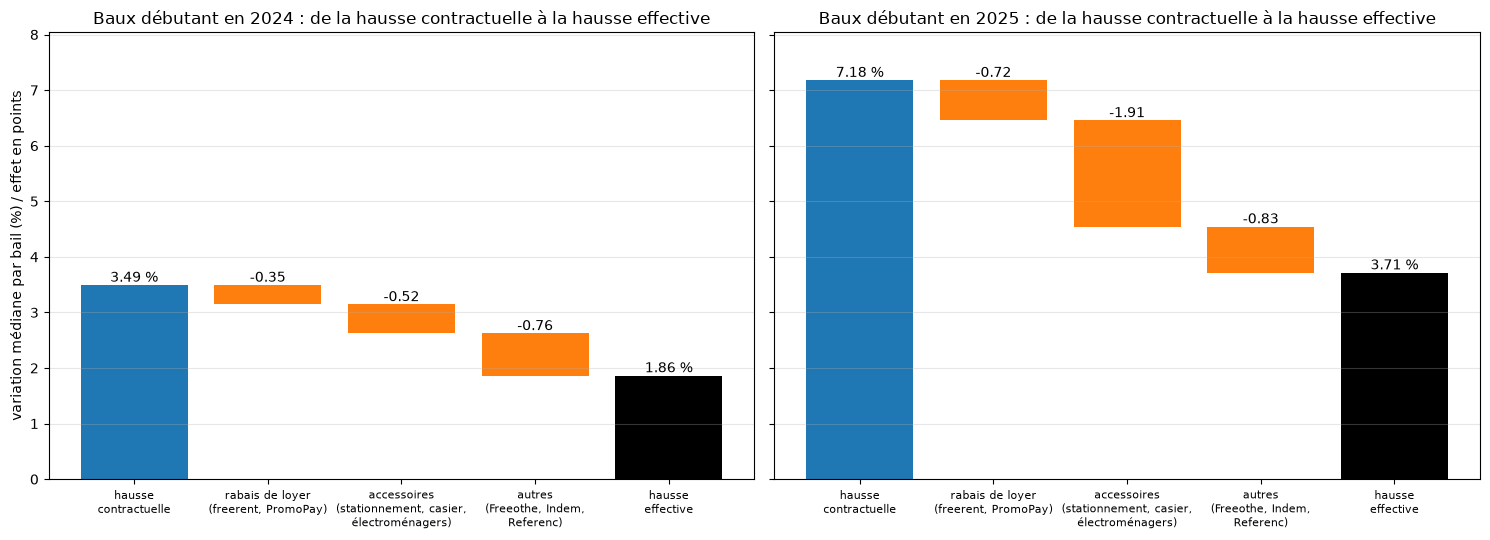

In [39]:
# Figure 12.6 : de la hausse contractuelle à la hausse effective, pour les deux dernières années.
BRIDGE_YEARS = [LAST_OBSERVED_YEAR - 1, LAST_OBSERVED_YEAR]
BRIDGE_STEPS = [("rent_discount_effect_pts", "rabais de loyer\n(freerent, PromoPay)"),
                ("ancillary_effect_pts", "accessoires\n(stationnement, casier,\nélectroménagers)"),
                ("other_effect_pts", "autres\n(Freeothe, Indem,\nReferenc)")]
BRIDGE_LABELS = ["hausse\ncontractuelle", *[label for _, label in BRIDGE_STEPS], "hausse\neffective"]
LABEL_HEADROOM_FACTOR = 1.12   # marge au-dessus de la plus haute barre pour afficher les étiquettes

fig, axes = plt.subplots(1, len(BRIDGE_YEARS), figsize=(15, 5.5), sharey=True)
for ax, year in zip(axes, BRIDGE_YEARS):
    row = concession_bridge.loc[year]
    running_total = row.contract_pct
    ax.bar(0, running_total, color="tab:blue")
    ax.text(0, running_total, f"{running_total:.2f} %", ha="center", va="bottom", fontsize=10)
    for position, (col, _) in enumerate(BRIDGE_STEPS, start=1):
        step = row[col]
        ax.bar(position, step, bottom=running_total, color="tab:orange" if step < 0 else "tab:green")
        ax.text(position, max(running_total, running_total + step), f"{step:+.2f}", ha="center", va="bottom", fontsize=10)
        running_total += step
    final_position = len(BRIDGE_STEPS) + 1
    ax.bar(final_position, running_total, color="black")
    ax.text(final_position, running_total, f"{running_total:.2f} %", ha="center", va="bottom", fontsize=10)
    ax.set_xticks(range(len(BRIDGE_LABELS)))
    ax.set_xticklabels(BRIDGE_LABELS, fontsize=8)
    ax.set(title=f"Baux débutant en {year} : de la hausse contractuelle à la hausse effective")
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("variation médiane par bail (%) / effet en points")
axes[0].set_ylim(top=concession_bridge.loc[BRIDGE_YEARS, "contract_pct"].max() * LABEL_HEADROOM_FACTOR)
plt.tight_layout()
plt.show()

**Lecture de la figure 12.6.**
- **En 2025, la hausse contractuelle de 7,2 % devient une hausse effective de 3,7 %** : les rabais de loyer en retirent environ 0,7 point, les accessoires 1,9 point et les autres concessions 0,8 point. En 2024, les trois catégories se partageaient l'écart (environ 0,4, 0,5 et 0,8 point).
- **Les accessoires sont devenus le principal levier de concession.** Équinoxe semble avoir préféré offrir des services plutôt que baisser le loyer inscrit au bail, ce qui protège la base des hausses futures.
- **La catégorie « autres » est surtout `Freeothe`** (environ 85 % de sa valeur), une concession non catégorisée qu'il serait utile de faire préciser par Équinoxe. `Indem`, une indemnité et non une incitation commerciale, n'en représente qu'environ 9 % : l'exclure ne changerait rien.

Ce pont justifie la règle d'usage de la section 8 : l'effectif pour budgéter, le contractuel pour comparer au marché, l'écart entre les deux étant entièrement expliqué par les concessions.

**Bilan de la section 12.**
- **Hausse effective à unité constante** : environ 1,9 % en 2024 et 3,7 % en 2025, contre 3,5 % et 7,2 % en contractuel. L'écart s'explique exactement par la hausse de la part cédée en concessions, surtout accessoires en 2025 (12.6) ; la prévision devra faire une hypothèse explicite sur leur évolution.
- **Renouvellements et relocations ont changé de camp en 2024** ; la part des renouvellements reste stable, autour de 60 %.
- **The Met dépasse la ligne directrice ontarienne** pour tous ses renouvellements de 2025, ce qui est cohérent avec l'exemption des immeubles récents : on ne le plafonne pas en 2026.

La section 13 réconcilie la série **contractuelle** avec les données publiques (règle d'usage de la section 8).

## 13. Données publiques et réconciliation avec la tendance interne

| Source | Contenu | Rôle |
|---|---|---|
| **SCHL**, Enquête sur les logements locatifs (2019 à 2025) | Variation du loyer à échantillon constant, loyers moyens, inoccupation, roulement, loyers des unités vacantes et occupées, pour les RMR de Montréal et d'Ottawa | Tendance du marché, comparable à notre mesure à unité constante |
| **Statistique Canada**, IPC, tableau 18-10-0004-01 | IPC d'ensemble et composante loyers, Québec et Ontario | Tendance des loyers et de l'inflation ; intrant de la méthode du TAL |
| **TAL** | Paramètres annuels d'ajustement des loyers au Québec | Repère des renouvellements dans les cinq immeubles québécois |
| **Ontario** | Ligne directrice annuelle | Repère des renouvellements en Ontario (The Met, section 12.4) |

Les fichiers publics sont dans `data/`, et les fichiers produits par le notebook y sont aussi écrits.

**Deux règles pour toute la section :**
- **Réconcilier en contractuel** (section 8) : les séries publiques portent sur le loyer, pas sur les incitatifs. L'écart dû aux concessions (12.6) permet ensuite de revenir à l'effectif.
- **Respecter la date de coupure** : pour prévoir l'année *t*, on n'utilise que ce qui était publié avant la saison de renouvellement de *t* (enquête SCHL d'octobre *t − 1*, IPC jusqu'en décembre *t − 1*, TAL publié en janvier *t*). La même règle s'applique au backtest.

### 13.1 SCHL : consolidation des classeurs en une seule table

La SCHL publie un classeur Excel par RMR et par année d'enquête (14 fichiers ici), dont la mise en page change d'une année à l'autre : ligne d'en-tête décalée, « Bachelor » devenu « Studio », nombres en texte avec séparateur de milliers. Cette étape lit les tableaux utiles, **filtre** les géographies pertinentes et les **rassemble au format long** dans `schl_market`, écrite dans `data/external_schl_rental_market.csv`.

| Tableau | Mesure | Utilité |
|---|---|---|
| 1.1.5 | `fixed_sample_rent_change_pct` | Variation du loyer moyen **à échantillon constant** : la mesure de la SCHL la plus proche de notre unité constante. |
| 1.1.2 | `average_rent` | Loyer moyen, pour situer les niveaux. |
| 1.1.1 | `vacancy_rate_pct` | Taux d'inoccupation, utilisé **comme contexte seulement** (section 2 : on ne calcule pas d'occupation pour Équinoxe). |
| 1.1.6 | `turnover_rate_pct` | Taux de roulement des locataires. |
| 1.1.9 | `vacant_unit_rent`, `occupied_unit_rent` | Loyers des unités vacantes et occupées. L'écart mesure la prime à la relocation, à comparer avec nos relocations (section 12.3). Disponible à partir de 2020. |

| Immeuble | Sous-marché | Zone candidate |
|---|---|---|
| Daniel-Johnson, Lévesque, Saint-Elzéar (Laval) | Laval (zones 19-24) | Agrégat seulement : les zones de Laval ont de petits échantillons |
| Le Carlyle (Mont-Royal) | Île de Montréal (zones 1-18) | Zone 5, Côte-des-Neiges/**Mont-Royal**/Outremont |
| Westpark (Pointe-Claire) | Île de Montréal (zones 1-18) | Zone 14 ou 15 : le nom des zones ne permet pas de trancher, on garde les deux |
| The Met (Ottawa, rue Metcalfe) | Ancienne ville d'Ottawa (zones 1-9) | Zone 1, Downtown |

L'association des immeubles aux zones repose sur le nom des zones, et les valeurs de zone sont souvent supprimées (`**`) : on s'appuie d'abord sur les RMR et les sous-marchés. Chaque ligne conserve l'année d'enquête et de publication, l'indicateur de qualité de la SCHL (a à d) et le statut de la valeur (`ok`, `suppressed`, `not_significant`).

In [40]:
import importlib.util
import re
from pathlib import Path

DATA_DIR = Path("data")   # données publiques (SCHL, IPC) et fichiers produits ; les données du CRM restent à la racine

# La lecture des classeurs .xlsx par pandas requiert openpyxl (voir requirements.txt).
if importlib.util.find_spec("openpyxl") is None:
    raise ImportError("openpyxl est requis pour lire les classeurs de la SCHL : exécutez "
                      "`%pip install -r requirements.txt`, puis redémarrez le noyau (Kernel > Restart).")

# Consolidation des classeurs de la SCHL (Enquête sur les logements locatifs, appartements d'initiative privée)
# en une seule table au format long : une ligne = une géographie × un type de logement × une mesure × une année d'enquête.
SCHL_FIRST_RELEASE_YEAR = 2019
SCHL_LAST_RELEASE_YEAR = LAST_OBSERVED_YEAR
SCHL_FILE_PATTERN = "rmr-{city}-{year}-en.xlsx"
SCHL_CITIES = {"montreal": "Montréal", "ottawa": "Ottawa"}
SCHL_OUTPUT_PATH = DATA_DIR / "external_schl_rental_market.csv"   # fichier consolidé écrit par le notebook

# Tableaux retenus (appartements d'initiative privée, par zone et nombre de chambres) -> mesure.
SCHL_TABLES = {
    "Table 1.1.1": "vacancy_rate_pct",
    "Table 1.1.2": "average_rent",
    "Table 1.1.5": "fixed_sample_rent_change_pct",
    "Table 1.1.6": "turnover_rate_pct",
    "Table 1.1.9": "vacant_vs_occupied_rent",       # disponible à partir de l'enquête 2020
}
VACANT_OCCUPIED_MEASURES = {"Vacant Units": "vacant_unit_rent", "Occupied Units": "occupied_unit_rent"}

# Géographies retenues : RMR, sous-marchés contenant les immeubles, et zones candidates (voir le Markdown).
SCHL_GEOGRAPHIES = {
    "Montréal CMA": "cma",
    "Ottawa CMA": "cma",
    "Montréal Island (Zones 1-18)": "submarket",
    "Laval (Zones 19-24)": "submarket",
    "Former City of Ottawa (Zones 1-9)": "submarket",
    "Zone 5 - Ct-des-Neiges/Mt-Royal/Outremont": "zone",
    "Zone 14 - Dorval/Lachine/Saint-Pierre": "zone",
    "Zone 15 - Baie-d'Urfé/Beaconsfield etc.": "zone",
    "Zone 1 - Downtown": "zone",                       # Ottawa (le centre-ville de Montréal porte un autre nom)
}
SCHL_BEDROOM_TYPES = {"Bachelor": "studio", "Studio": "studio", "1 Bedroom": "1", "2 Bedroom": "2",
                      "3 Bedroom +": "3+", "Total": "total"}
SCHL_STATUS_CODES = {"**": "suppressed", "++": "not_significant", "-": "not_applicable", "−": "not_applicable"}
TWO_DIGIT_YEAR_BASE = 2000
THOUSANDS_SEPARATOR = ","                            # les loyers sont publiés sous la forme « 1,124 »
OCTOBER_LABEL = re.compile(r"Oct-(\d{2})")


def clean_label(value):
    return "" if pd.isna(value) else " ".join(str(value).split())


def parse_schl_table(path, sheet, measure, release_year, cma):
    # Lit un tableau « par zone et nombre de chambres » et le met au format long.
    raw = pd.read_excel(path, sheet_name=sheet, header=None, dtype=object)
    first_col = raw.iloc[:, 0].map(clean_label)
    header_row = first_col.index[first_col.eq("Zone")][0]
    bedroom_labels = raw.iloc[header_row - 1].map(clean_label).replace("", np.nan).ffill()
    column_labels = raw.iloc[header_row].map(clean_label)
    body = raw.iloc[header_row + 1:]
    body = body[body.iloc[:, 0].map(clean_label).isin(SCHL_GEOGRAPHIES)]

    records = []
    for col in range(1, raw.shape[1]):
        label = column_labels[col]
        if label in ("", "Y/N"):
            continue                                    # colonne de qualité, de tendance ou de test
        if label in VACANT_OCCUPIED_MEASURES:
            row_measure, survey_year = VACANT_OCCUPIED_MEASURES[label], release_year
        else:
            row_measure, survey_year = measure, TWO_DIGIT_YEAR_BASE + int(OCTOBER_LABEL.findall(label)[-1])
        for _, row in body.iterrows():
            raw_value = clean_label(row.iloc[col])
            records.append({
                "cma": cma,
                "geography": clean_label(row.iloc[0]),
                "bedroom_type": SCHL_BEDROOM_TYPES[bedroom_labels[col]],
                "measure": row_measure,
                "survey_year": survey_year,
                "release_year": release_year,
                "value": pd.to_numeric(raw_value.replace(THOUSANDS_SEPARATOR, ""), errors="coerce"),
                "quality": clean_label(row.iloc[col + 1]) or np.nan,
                "status": SCHL_STATUS_CODES.get(raw_value, "ok" if raw_value else "missing"),
                "source_table": sheet.replace("Table ", ""),
                "source_file": Path(path).name,
            })
    return records


schl_records = []
for city, cma in SCHL_CITIES.items():
    for release_year in range(SCHL_FIRST_RELEASE_YEAR, SCHL_LAST_RELEASE_YEAR + 1):
        path = DATA_DIR / SCHL_FILE_PATTERN.format(city=city, year=release_year)
        available_sheets = pd.ExcelFile(path).sheet_names
        for sheet, measure in SCHL_TABLES.items():
            if sheet in available_sheets:
                schl_records += parse_schl_table(path, sheet, measure, release_year, cma)

schl_market = pd.DataFrame(schl_records)
schl_market["geography_level"] = schl_market.geography.map(SCHL_GEOGRAPHIES)
schl_market.to_csv(SCHL_OUTPUT_PATH, index=False)
print(f"{len(schl_market):,} lignes écrites dans {SCHL_OUTPUT_PATH}")

3,060 lignes écrites dans data/external_schl_rental_market.csv


On vérifie la consolidation avant de s'en servir : chaque géographie doit être trouvée dans chaque fichier, sans doublon. On regarde aussi la part des valeurs supprimées et les révisions entre deux publications. Chaque classeur reprend en effet l'année précédente.

In [41]:
# Contrôles de la consolidation SCHL.
# 1. Chaque géographie retenue est trouvée dans chaque fichier.
found = schl_market.groupby(["cma", "release_year"]).geography.nunique().unstack("release_year")
print("Géographies trouvées par fichier :"); print(found.to_string())

# 2. Une seule valeur par (géographie, type, mesure, année d'enquête, publication).
key_cols = ["cma", "geography", "bedroom_type", "measure", "survey_year", "release_year"]
print(f"\nDoublons sur la clé : {schl_market.duplicated(key_cols).sum()}")

# 3. Statuts : valeurs publiées, supprimées, non significatives.
print("\nStatut des valeurs :", schl_market.status.value_counts().to_dict())

# 4. Couverture des mesures (RMR, tous logements) par année d'enquête, dans la publication la plus récente.
latest = (schl_market.sort_values("release_year")
          .drop_duplicates([c for c in key_cols if c != "release_year"], keep="last"))
cma_totals = latest[(latest.geography_level == "cma") & (latest.bedroom_type == "total")]
print("\nRMR, tous logements, publication la plus récente :")
print(cma_totals.pivot_table(index=["cma", "survey_year"], columns="measure", values="value").round(1).to_string())

# 5. Révisions : la variation à échantillon constant d'une année figure dans deux publications successives.
fixed_sample = schl_market[(schl_market.measure == "fixed_sample_rent_change_pct") & (schl_market.geography_level == "cma")
                           & (schl_market.bedroom_type == "total")]
revisions = fixed_sample.pivot_table(index=["cma", "survey_year"], columns="release_year", values="value")
print("\nVariation à échantillon constant (RMR, total) selon l'année de publication :")
print(revisions.round(1).to_string())

Géographies trouvées par fichier :
release_year  2019  2020  2021  2022  2023  2024  2025
cma                                                   
Montréal         6     6     6     6     6     6     6
Ottawa           3     3     3     3     3     3     3

Doublons sur la clé : 0

Statut des valeurs : {'ok': 2649, 'suppressed': 343, 'not_significant': 68}

RMR, tous logements, publication la plus récente :
measure               average_rent  fixed_sample_rent_change_pct  occupied_unit_rent  turnover_rate_pct  vacancy_rate_pct  vacant_unit_rent
cma      survey_year                                                                                                                       
Montréal 2018                796.0                           2.5                 NaN               17.4               1.9               NaN
         2019                841.0                           3.6                 NaN               15.7               1.5               NaN
         2020                89

**Lecture des contrôles.** La consolidation est complète : les neuf géographies sont trouvées dans les 14 fichiers, sans doublon, et toutes les valeurs publiées sont converties. Environ 13 % des valeurs sont supprimées ou non significatives, à 80 % au niveau des zones. Les révisions entre publications ne dépassent pas 0,1 point : on retient la **première publication** de chaque année d'enquête, conformément à la date de coupure.

### 13.2 IPC : composante loyers et inflation générale

On charge le tableau 18-10-0004-01 et on garde quatre séries : l'IPC loyers et l'IPC d'ensemble, pour le Québec et l'Ontario. Le fichier contient aussi des données de 2026 (jusqu'en août). **On les retire** : elles sont postérieures à la date de coupure de l'information.

On calcule ensuite :
- la **moyenne annuelle** de l'indice, sur les années complètes seulement ;
- sa **variation annuelle**, alignée sur l'année du bail ;
- la **moyenne sur trois ans de l'inflation générale du Québec**, qui est la base de la nouvelle méthode du TAL en 2026.

Cette étape crée `cpi` (mensuel) et `cpi_annual_change` (annuel).

In [42]:
# IPC (Statistique Canada, tableau 18-10-0004-01) : chargement, coupure à la date d'information, moyennes annuelles.
CPI_PATH = DATA_DIR / "IPC_1810000401.csv"
CPI_RENAMES = {"PÉRIODE DE RÉFÉRENCE": "month", "GÉO": "geography",
               "Produits et groupes de produits": "product", "VALEUR": "index_value"}
CPI_SERIES = {("Québec", "Loyer"): "qc_rent", ("Ontario", "Loyer"): "on_rent",
              ("Québec", "Ensemble"): "qc_all_items", ("Ontario", "Ensemble"): "on_all_items"}
CPI_INFORMATION_CUTOFF = pd.Timestamp(year=LAST_OBSERVED_YEAR, month=12, day=1)   # dernier mois utilisable
MONTHS_PER_FULL_YEAR = 12

cpi_raw = pd.read_csv(CPI_PATH, sep=";", encoding="utf-8-sig")
cpi = cpi_raw[list(CPI_RENAMES)].rename(columns=CPI_RENAMES)
cpi["month"] = pd.to_datetime(cpi.month, format="%Y-%m")
cpi["series"] = [CPI_SERIES.get(key) for key in zip(cpi.geography, cpi["product"])]
cpi = cpi.dropna(subset=["series"])

months_after_cutoff = (cpi.month > CPI_INFORMATION_CUTOFF).groupby(cpi.series).sum()
print(f"Mois postérieurs à {CPI_INFORMATION_CUTOFF:%Y-%m} retirés (par série) : {months_after_cutoff.to_dict()}")
cpi = cpi[cpi.month <= CPI_INFORMATION_CUTOFF]

# Moyenne annuelle de l'indice (années complètes seulement), puis variation annuelle en %.
cpi["year"] = cpi.month.dt.year
cpi_annual_index = cpi.pivot_table(index="year", columns="series", values="index_value", aggfunc="mean")
complete_years = cpi.groupby("year").month.nunique().loc[lambda n: n == MONTHS_PER_FULL_YEAR].index
cpi_annual_change = (cpi_annual_index.loc[complete_years].pct_change() * TO_PERCENT).dropna(how="all")

# Nouvelle méthode du TAL (2026) : moyenne de l'inflation générale du Québec sur les trois années précédentes.
TAL_NEW_METHOD_WINDOW_YEARS = 3
cpi_annual_change["qc_all_items_3y_avg"] = cpi_annual_change.qc_all_items.rolling(TAL_NEW_METHOD_WINDOW_YEARS).mean()
print(cpi_annual_change.round(2).to_string())

Mois postérieurs à 2025-12 retirés (par série) : {'on_all_items': 8, 'on_rent': 8, 'qc_all_items': 8, 'qc_rent': 8}
series  on_all_items  on_rent  qc_all_items  qc_rent  qc_all_items_3y_avg
year                                                                     
2017            1.68     0.95          1.08     0.73                  NaN
2018            2.35     1.44          1.65     0.81                  NaN
2019            1.87     3.80          2.07     1.93                 1.60
2020            0.64     1.64          0.80     1.20                 1.51
2021            3.48     1.49          3.79     2.74                 2.22
2022            6.80     5.58          6.67     3.60                 3.75
2023            3.78     6.27          4.49     5.88                 4.98
2024            2.38     6.90          2.33     8.87                 4.50
2025            1.90     4.30          2.47     7.75                 3.09


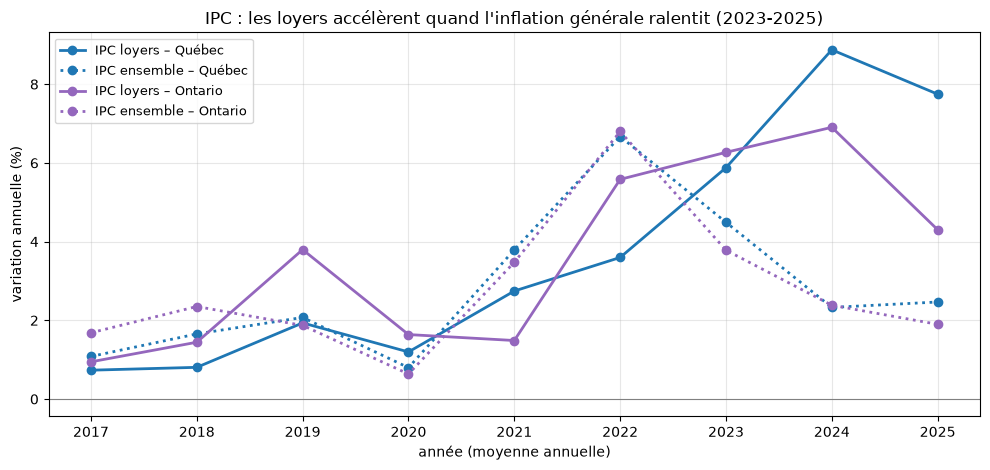

In [43]:
# Figure 13.1 : IPC loyers vs IPC d'ensemble, Québec et Ontario.
CPI_PLOT_SPECS = [("qc_rent", "IPC loyers – Québec", "tab:blue", "-"), ("qc_all_items", "IPC ensemble – Québec", "tab:blue", ":"),
                  ("on_rent", "IPC loyers – Ontario", "tab:purple", "-"), ("on_all_items", "IPC ensemble – Ontario", "tab:purple", ":")]
fig, ax = plt.subplots(figsize=(10, 4.8))
for col, label, color, style in CPI_PLOT_SPECS:
    ax.plot(cpi_annual_change.index, cpi_annual_change[col], marker="o", ls=style, lw=2, color=color, label=label)
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="IPC : les loyers accélèrent quand l'inflation générale ralentit (2023-2025)",
       xlabel="année (moyenne annuelle)", ylabel="variation annuelle (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 13.1.**

- **Au Québec, les loyers se détachent de l'inflation générale.** L'IPC loyers passe d'environ 1,2 % en 2020 à près de 9 % en 2024, puis 7,8 % en 2025, alors que l'inflation générale retombe autour de 2,4 %.
- **En Ontario, l'IPC loyers ralentit nettement en 2025** (environ 4,3 %, contre 6,9 % en 2024).
- **Conséquence pour 2026.** La nouvelle méthode du TAL indexe les renouvellements sur l'inflation *générale* (environ 3,1 %), bien en dessous de la hausse des loyers du marché. L'écart entre renouvellements et relocations pourrait donc encore se creuser au Québec.

### 13.3 Paramètres réglementaires : TAL et ligne directrice ontarienne

Les repères annuels sont saisis dans une petite table documentée, `regulatory_parameters`, avec la source de chaque valeur. Le notebook l'écrit dans `data/external_regulatory_parameters.csv`.

- **TAL (Québec), jusqu'en 2025.** On retient l'« estimation moyenne d'augmentation de base » pour un logement non chauffé, le repère le plus cité. Ce n'est **pas un plafond** : les parties peuvent s'entendre sur un autre montant, et le TAL ne fixe le loyer qu'en cas de désaccord.
- **TAL en 2026.** La méthode change : le pourcentage de base devient la moyenne de l'IPC d'ensemble du Québec sur trois ans, soit 3,1 % pour les baux renouvelés entre avril 2026 et avril 2027. C'est une **rupture de série**.
- **Valeur de 2019 du TAL.** Elle n'est publiée que dans une image sur le site officiel. On la laisse manquante plutôt que de la deviner.
- **Qualité des sources.** Les valeurs de 2020 et 2021 viennent d'une source secondaire, qui reprend l'historique du TAL ; les autres viennent des communiqués officiels ou de sources de presse qui les citent.
- **Ontario.** La ligne directrice est plafonnée à 2,5 % de 2023 à 2025. Elle était gelée à 0 % en 2021 et vaut 2,1 % en 2026. Elle **ne s'applique pas** aux unités occupées pour la première fois après le 15 novembre 2018 (section 12.4).

In [44]:
# Paramètres réglementaires annuels (Québec : TAL ; Ontario : ligne directrice), avec leur source.
# TAL : « estimation moyenne d'augmentation de base » pour un logement non chauffé (ancienne méthode, jusqu'en 2025),
# puis pourcentage de base de la nouvelle méthode (2026). Valeur 2019 non retrouvée dans une source textuelle vérifiable.
REGULATORY_PARAMETERS = [
    # (année, série, valeur %, source, note)
    (2019, "tal_reference_pct", np.nan, "https://www.tal.gouv.qc.ca/en/news/calculation-of-the-2019-rent-increase", "tableau publié en image seulement"),
    (2020, "tal_reference_pct", 1.20, "https://www.silo57.ca/2025/01/21/le-tal-revele-la-hausse-moyenne-des-loyers-en-2025-et-confirme-nos-craintes", "source secondaire (historique du TAL)"),
    (2021, "tal_reference_pct", 0.80, "https://www.silo57.ca/2025/01/21/le-tal-revele-la-hausse-moyenne-des-loyers-en-2025-et-confirme-nos-craintes", "source secondaire (historique du TAL)"),
    (2022, "tal_reference_pct", 1.28, "https://www.tal.gouv.qc.ca/sites/default/files/COMMUNIQUE_FIXATION_2022_FR.pdf", "communiqué officiel"),
    (2023, "tal_reference_pct", 2.30, "https://www.tal.gouv.qc.ca/sites/default/files/COMMUNIQUE_FIXATION_2023_FR.pdf", "communiqué officiel"),
    (2024, "tal_reference_pct", 4.00, "https://www.tal.gouv.qc.ca/sites/default/files/COMMUNIQUE_FIXATION_2024_FR.pdf", "communiqué officiel"),
    (2025, "tal_reference_pct", 5.90, "https://www.protegez-vous.ca/nouvelles/argent/le-tal-propose-des-hausses-de-loyer-historiques", "dernière année de l'ancienne méthode"),
    (2026, "tal_reference_pct", 3.10, "https://www.quebec.ca/nouvelles/actualites/details/le-calcul-de-lajustement-des-loyers-en-2026-68053", "nouvelle méthode : moyenne de l'IPC du Québec sur 3 ans"),
    (2019, "ontario_guideline_pct", 1.8, "https://tribunalsontario.ca/2018/07", ""),
    (2020, "ontario_guideline_pct", 2.2, "https://tribunalsontario.ca/2019/06/", ""),
    (2021, "ontario_guideline_pct", 0.0, "https://www.ontario.ca/page/rent-increase-guideline", "gel des loyers (COVID-19)"),
    (2022, "ontario_guideline_pct", 1.2, "https://amp.cbc.ca/lite/story/1.6894097", ""),
    (2023, "ontario_guideline_pct", 2.5, "https://www.ontario.ca/page/rent-increase-guideline", ""),
    (2024, "ontario_guideline_pct", 2.5, "https://www.ontario.ca/page/rent-increase-guideline", ""),
    (2025, "ontario_guideline_pct", 2.5, "https://www.ontario.ca/page/rent-increase-guideline", ""),
    (2026, "ontario_guideline_pct", 2.1, "https://www.ontario.ca/page/rent-increase-guideline", "ne s'applique pas aux unités occupées pour la première fois après le 15 novembre 2018"),
]
REGULATORY_OUTPUT_PATH = DATA_DIR / "external_regulatory_parameters.csv"

regulatory_parameters = pd.DataFrame(REGULATORY_PARAMETERS, columns=["year", "series", "value_pct", "source_url", "note"])
regulatory_parameters.to_csv(REGULATORY_OUTPUT_PATH, index=False)
regulatory_by_year = regulatory_parameters.pivot_table(index="year", columns="series", values="value_pct", dropna=False)

# Vérification : la nouvelle méthode du TAL (2026) se reproduit-elle avec l'IPC d'ensemble du Québec ?
reproduced_tal_2026 = cpi_annual_change.loc[FORECAST_YEAR - 1, "qc_all_items_3y_avg"]
print(regulatory_by_year.to_string())
print(f"\nTAL {FORECAST_YEAR} publié : {regulatory_by_year.loc[FORECAST_YEAR, 'tal_reference_pct']:.1f} % | "
      f"moyenne de l'IPC d'ensemble du Québec {FORECAST_YEAR - TAL_NEW_METHOD_WINDOW_YEARS}-{FORECAST_YEAR - 1} : {reproduced_tal_2026:.2f} %")

series  ontario_guideline_pct  tal_reference_pct
year                                            
2019                      1.8                NaN
2020                      2.2               1.20
2021                      0.0               0.80
2022                      1.2               1.28
2023                      2.5               2.30
2024                      2.5               4.00
2025                      2.5               5.90
2026                      2.1               3.10

TAL 2026 publié : 3.1 % | moyenne de l'IPC d'ensemble du Québec 2023-2025 : 3.09 %


**La nouvelle méthode du TAL se reproduit exactement.** La moyenne de l'inflation générale du Québec de 2023 à 2025 donne 3,09 %, pour un taux publié de 3,1 %. Le repère de renouvellement de 2026 est donc **entièrement déterminé par l'IPC de 2023 à 2025**, une information disponible avant la date de prévision. Ce sera l'ancrage le plus solide de la section 14.

### 13.4 Réconciliation : Équinoxe suit-elle son marché ?

**Alignement des calendriers.**
- Notre année est celle du **début du bail**, et la plupart des baux québécois commencent en juillet.
- L'enquête SCHL de l'année *t* mesure la variation d'octobre *t − 1* à octobre *t*, ce qui encadre juillet *t*.
- La moyenne annuelle de l'IPC de *t* est centrée sur le milieu de l'année.
- Le taux du TAL de *t*, publié en janvier, s'applique aux renouvellements de *t*.

On associe donc toutes ces séries à la **même année *t***. Pour la SCHL, on prend la première publication de chaque année d'enquête (13.1).

Comme le prévoit la règle d'usage de la section 8, on compare le **loyer contractuel** à unité constante, en médiane des paires comparables, avec des repères publics qui portent eux aussi sur le loyer. Chaque segment interne est comparé au repère qui lui correspond. Cette étape crée la table `market_reconciliation`, qui contient une ligne par année de 2019 à 2026. Pour 2026, seuls les repères réglementaires sont connus.

In [45]:
# Table de réconciliation : une ligne par année, séries internes (contractuel, médiane des paires comparables) et externes.
# Alignement : notre année = année de début du bail (surtout juillet au Québec). L'enquête SCHL d'octobre t (oct. t-1 → oct. t),
# la moyenne annuelle de l'IPC de t et le taux du TAL publié en janvier t couvrent la même période : on les associe à l'année t.
QUEBEC_PROVINCE = "Quebec"


def first_release_value(market, measure, geography, bedroom_type="total"):
    # Valeur de la première publication de chaque année d'enquête (date de coupure de l'information, 13.1).
    rows = market[(market.measure == measure) & (market.geography == geography) & (market.bedroom_type == bedroom_type)
                  & market.value.notna()].sort_values("release_year")
    return rows.drop_duplicates("survey_year", keep="first").set_index("survey_year").value


def internal_median(pairs_table, mask):
    return pairs_table[mask].groupby("lease_start_year")["contract_growth_pct"].median()


is_quebec = growth_pairs.province == QUEBEC_PROVINCE
vacant_rent = {cma: first_release_value(schl_market, "vacant_unit_rent", f"{cma} CMA") for cma in SCHL_CITIES.values()}
occupied_rent = {cma: first_release_value(schl_market, "occupied_unit_rent", f"{cma} CMA") for cma in SCHL_CITIES.values()}

market_reconciliation = pd.DataFrame({
    # Internes (contractuel, section 12)
    "equinoxe_qc_all": internal_median(growth_pairs, is_quebec),
    "equinoxe_qc_renewal": internal_median(growth_pairs, is_quebec & growth_pairs.is_renewal),
    "equinoxe_qc_turnover": internal_median(growth_pairs, is_quebec & ~growth_pairs.is_renewal),
    "equinoxe_met_all": internal_median(growth_pairs, ~is_quebec),
    # SCHL : variation à échantillon constant
    "schl_montreal_cma": first_release_value(schl_market, "fixed_sample_rent_change_pct", "Montréal CMA"),
    "schl_laval": first_release_value(schl_market, "fixed_sample_rent_change_pct", "Laval (Zones 19-24)"),
    "schl_ottawa_cma": first_release_value(schl_market, "fixed_sample_rent_change_pct", "Ottawa CMA"),
    # SCHL : contexte
    "schl_montreal_vacancy": first_release_value(schl_market, "vacancy_rate_pct", "Montréal CMA"),
    "schl_ottawa_vacancy": first_release_value(schl_market, "vacancy_rate_pct", "Ottawa CMA"),
    "schl_montreal_vacant_premium_pct": (vacant_rent["Montréal"] / occupied_rent["Montréal"] - 1) * TO_PERCENT,
    "schl_ottawa_vacant_premium_pct": (vacant_rent["Ottawa"] / occupied_rent["Ottawa"] - 1) * TO_PERCENT,
    # IPC et réglementation
    "cpi_rent_qc": cpi_annual_change.qc_rent,
    "cpi_rent_on": cpi_annual_change.on_rent,
    "tal_reference": regulatory_by_year.tal_reference_pct,
    "ontario_guideline": regulatory_by_year.ontario_guideline_pct,
}).loc[FIRST_ANALYSIS_YEAR:FORECAST_YEAR]
print(market_reconciliation.round(2).T.to_string())

                                  2019   2020   2021   2022   2023   2024   2025  2026
equinoxe_qc_all                   2.26   3.31   4.60   5.64   2.33   3.53   7.19   NaN
equinoxe_qc_renewal               2.60   3.59   4.84   5.86   2.59   3.04   6.61   NaN
equinoxe_qc_turnover              1.37   2.19   3.63   4.33   1.84   5.04   9.21   NaN
equinoxe_met_all                   NaN    NaN    NaN    NaN    NaN   3.32   7.06   NaN
schl_montreal_cma                 3.60   4.20   3.70   5.10   7.70   6.40   7.40   NaN
schl_laval                        2.40   2.20   2.70    NaN    NaN   6.30   8.00   NaN
schl_ottawa_cma                   8.20   4.50   2.20   3.80   4.30   5.20   3.50   NaN
schl_montreal_vacancy             1.50   2.70   3.00   2.00   1.50   2.10   2.90   NaN
schl_ottawa_vacancy               1.80   3.90   3.40   2.10   2.10   2.60   3.00   NaN
schl_montreal_vacant_premium_pct   NaN  34.84  10.00  28.23  21.29  43.52  27.09   NaN
schl_ottawa_vacant_premium_pct     NaN  20.

La figure 13.2 compare d'abord les **renouvellements** au TAL et à l'IPC loyers, puis **l'ensemble des baux** à la variation à échantillon constant de la SCHL, pour la RMR de Montréal et pour le sous-marché de Laval, où se trouvent trois des cinq immeubles québécois.

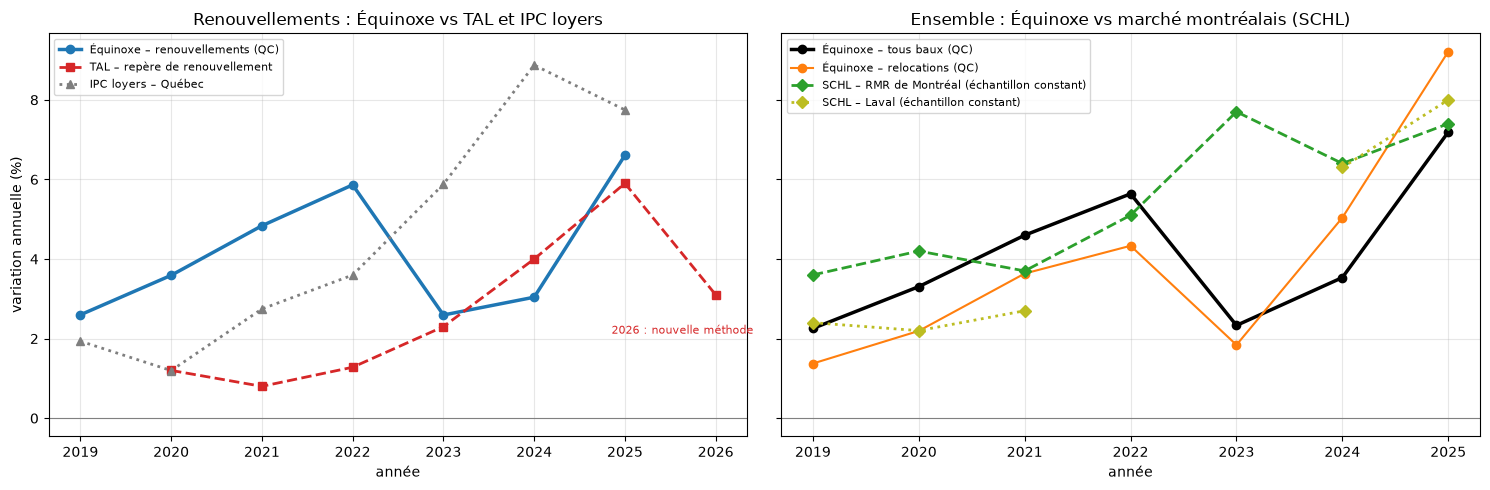

In [46]:
# Figure 13.2 : Québec, renouvellements et relocations d'Équinoxe face aux repères publics (variation annuelle, %).
fig, (ax_renew, ax_market) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
observed = market_reconciliation.loc[:LAST_OBSERVED_YEAR]

ax_renew.plot(observed.index, observed.equinoxe_qc_renewal, "o-", lw=2.5, color="tab:blue", label="Équinoxe – renouvellements (QC)")
ax_renew.plot(market_reconciliation.index, market_reconciliation.tal_reference, "s--", lw=2, color="tab:red", label="TAL – repère de renouvellement")
ax_renew.plot(observed.index, observed.cpi_rent_qc, "^:", lw=2, color="tab:grey", label="IPC loyers – Québec")
ax_renew.annotate("2026 : nouvelle méthode", (FORECAST_YEAR, market_reconciliation.loc[FORECAST_YEAR, "tal_reference"]),
                  textcoords="offset points", xytext=(-75, -28), fontsize=8, color="tab:red")
ax_renew.set(title="Renouvellements : Équinoxe vs TAL et IPC loyers", xlabel="année", ylabel="variation annuelle (%)")

ax_market.plot(observed.index, observed.equinoxe_qc_all, "o-", lw=2.5, color="black", label="Équinoxe – tous baux (QC)")
ax_market.plot(observed.index, observed.equinoxe_qc_turnover, "o-", lw=1.5, color="tab:orange", label="Équinoxe – relocations (QC)")
ax_market.plot(observed.index, observed.schl_montreal_cma, "D--", lw=2, color="tab:green", label="SCHL – RMR de Montréal (échantillon constant)")
ax_market.plot(observed.index, observed.schl_laval, "D:", lw=2, color="tab:olive", label="SCHL – Laval (échantillon constant)")
ax_market.set(title="Ensemble : Équinoxe vs marché montréalais (SCHL)", xlabel="année")
for ax in (ax_renew, ax_market):
    ax.axhline(0, color="grey", lw=0.8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Lecture de la figure 13.2.**
- **Renouvellements et TAL.** De 2020 à 2022, Équinoxe dépasse largement le TAL (3,6 % à 5,9 % pour un repère de 1,3 % au plus) : le TAL n'est qu'une référence, et un marché qui se resserre permet de s'entendre au-dessus. **Depuis 2023, l'écart moyen est nul** (+0,3, −1,0 et +0,7 point).
- **Ensemble et marché.** Équinoxe suit le marché montréalais jusqu'en 2022, puis décroche en 2023 et en 2024 (2,3 % contre 7,7 % en 2023), avant de le rejoindre en 2025 (7,2 % contre 7,4 %). Laval, où se trouvent trois immeubles, est encore plus fort en 2025 (8,0 %).
- **Relocations.** À 9,2 % en 2025, elles dépassent le marché, ce qui est cohérent avec la prime des unités vacantes mesurée par la SCHL à Montréal (environ 27 %).

Une variation annuelle ne dit pas tout : un écart d'une année peut se rattraper l'année suivante. La figure 13.3 cumule donc chaque série depuis 2019 (base 100), pour comparer les **niveaux**.

Indice cumulé 2019 = 100 (le TAL 2019 manque : sa série part de 2020) :
      equinoxe_qc_all  schl_montreal_cma  cpi_rent_qc  tal_reference
2019            100.0              100.0        100.0          100.0
2020            103.3              104.2        101.2          101.2
2021            108.1              108.1        104.0          102.0
2022            114.1              113.6        107.7          103.3
2023            116.8              122.3        114.0          105.7
2024            120.9              130.1        124.2          109.9
2025            129.6              139.8        133.8          116.4


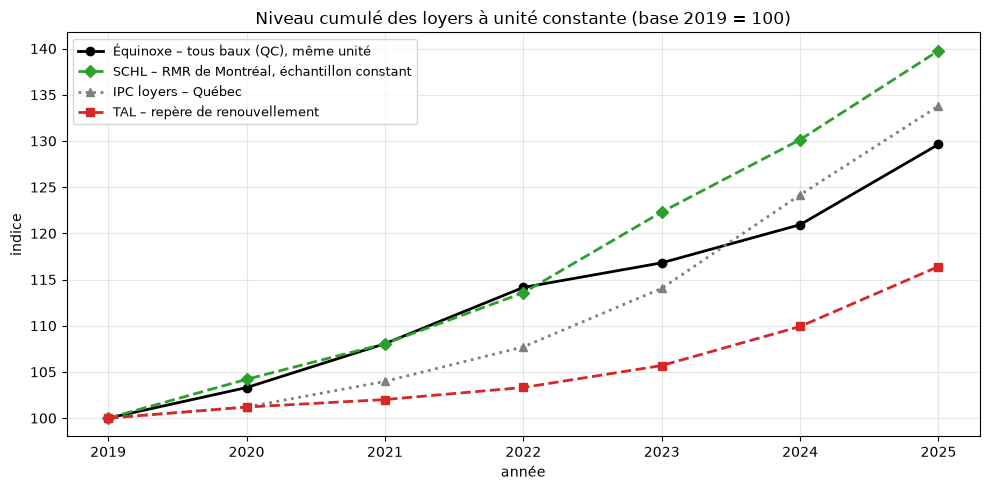

In [47]:
# Figure 13.3 : niveau cumulé depuis 2019 (base 100) – Équinoxe suit-elle son marché sur la durée ?
CUMULATIVE_BASE_YEAR = FIRST_ANALYSIS_YEAR
CUMULATIVE_BASE_LEVEL = 100
CUMULATIVE_SERIES = {"equinoxe_qc_all": ("Équinoxe – tous baux (QC), même unité", "black", "o-"),
                     "schl_montreal_cma": ("SCHL – RMR de Montréal, échantillon constant", "tab:green", "D--"),
                     "cpi_rent_qc": ("IPC loyers – Québec", "tab:grey", "^:"),
                     "tal_reference": ("TAL – repère de renouvellement", "tab:red", "s--")}
growth_window = market_reconciliation.loc[CUMULATIVE_BASE_YEAR + 1:LAST_OBSERVED_YEAR, list(CUMULATIVE_SERIES)]
cumulative_index = CUMULATIVE_BASE_LEVEL * (1 + growth_window / TO_PERCENT).cumprod()
cumulative_index.loc[CUMULATIVE_BASE_YEAR] = CUMULATIVE_BASE_LEVEL
cumulative_index = cumulative_index.sort_index()
print(f"Indice cumulé {CUMULATIVE_BASE_YEAR} = {CUMULATIVE_BASE_LEVEL} (le TAL 2019 manque : sa série part de {CUMULATIVE_BASE_YEAR + 1}) :")
print(cumulative_index.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
for col, (label, color, style) in CUMULATIVE_SERIES.items():
    ax.plot(cumulative_index.index, cumulative_index[col], style, lw=2, color=color, label=label)
ax.set(title=f"Niveau cumulé des loyers à unité constante (base {CUMULATIVE_BASE_YEAR} = {CUMULATIVE_BASE_LEVEL})",
       xlabel="année", ylabel="indice")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 13.3.**

- **De 2019 à 2025, les loyers d'Équinoxe à unité constante augmentent d'environ 30 %**, contre environ 40 % pour le marché montréalais (SCHL) et 34 % pour l'IPC loyers du Québec. Le repère du TAL, cumulé depuis 2020, n'augmente que d'environ 16 %.
- **Équinoxe suit exactement le marché jusqu'en 2022, puis prend environ 10 points de retard** en 2023 et en 2024, les années où ses hausses s'alignent sur le TAL plutôt que sur le marché. En 2025, elle ne rattrape qu'une partie de cet écart.
- **Les loyers des locataires en place se situent donc probablement sous le marché.** Ce retard explique que les relocations rapportent davantage que les renouvellements depuis 2024 : chaque départ permet de ramener une unité au prix du marché. C'est un potentiel de rattrapage, mais il se réalise surtout à la relocation, au rythme des départs.
- **Une nuance :** la SCHL couvre tout le parc locatif d'initiative privée de la RMR, surtout ancien. Équinoxe compte des immeubles récents et haut de gamme, dont la dynamique peut différer.

Pour juger quels repères peuvent servir à prévoir, on mesure, pour chaque comparaison, l'écart moyen et la corrélation entre la série interne et le repère. On le fait sur la même année et avec un an de décalage, puisque l'enquête SCHL et l'IPC de l'année *t − 1* sont les seules informations de marché disponibles au moment de prévoir *t*.

In [48]:
# Écarts moyens et corrélations entre chaque série interne et son repère public (années où les deux existent).
RECONCILIATION_PAIRS = [
    ("equinoxe_qc_renewal", "tal_reference", "Renouvellements QC vs TAL"),
    ("equinoxe_qc_renewal", "cpi_rent_qc", "Renouvellements QC vs IPC loyers QC"),
    ("equinoxe_qc_all", "schl_montreal_cma", "Tous baux QC vs SCHL Montréal"),
    ("equinoxe_qc_all", "cpi_rent_qc", "Tous baux QC vs IPC loyers QC"),
    ("equinoxe_met_all", "schl_ottawa_cma", "The Met vs SCHL Ottawa"),
]
LAG_YEARS = 1   # le repère de l'année précédente : seule information disponible au moment de prévoir pour la SCHL et l'IPC

reconciliation_rows = []
for internal_col, external_col, label in RECONCILIATION_PAIRS:
    internal = market_reconciliation[internal_col].loc[:LAST_OBSERVED_YEAR]
    for lag in (0, LAG_YEARS):
        external = market_reconciliation[external_col].shift(lag).loc[:LAST_OBSERVED_YEAR]
        both = pd.concat([internal, external], axis=1).dropna()
        reconciliation_rows.append({
            "comparaison": label, "repère": "même année" if lag == 0 else f"année précédente (t-{lag})",
            "années": f"{both.index.min()}-{both.index.max()}", "n": len(both),
            "écart moyen (pts)": (both.iloc[:, 0] - both.iloc[:, 1]).mean(),
            "écart des 3 dernières années (pts)": (both.iloc[:, 0] - both.iloc[:, 1]).tail(3).mean(),
            "corrélation": both.iloc[:, 0].corr(both.iloc[:, 1]) if len(both) > 2 else np.nan,
        })
reconciliation_summary = pd.DataFrame(reconciliation_rows)
print(reconciliation_summary.round(2).to_string(index=False))

                        comparaison                 repère    années  n  écart moyen (pts)  écart des 3 dernières années (pts)  corrélation
          Renouvellements QC vs TAL             même année 2020-2025  6               1.84                                0.01         0.27
          Renouvellements QC vs TAL année précédente (t-1) 2021-2025  5               2.67                                1.55         0.37
Renouvellements QC vs IPC loyers QC             même année 2019-2025  7              -0.41                               -3.42         0.14
Renouvellements QC vs IPC loyers QC année précédente (t-1) 2020-2025  6               0.38                               -2.04         0.33
      Tous baux QC vs SCHL Montréal             même année 2019-2025  7              -1.32                               -2.82         0.24
      Tous baux QC vs SCHL Montréal année précédente (t-1) 2020-2025  6              -0.68                               -2.05         0.08
      Tous baux QC v

**Lecture du tableau de réconciliation.**

- **Les corrélations sont faibles** (0,5 au plus) et reposent sur 5 à 7 années seulement. Aucun repère ne permet d'estimer de façon fiable une relation statistique, comme une régression, entre l'année *t* du marché et l'année *t* d'Équinoxe. La prévision s'appuiera donc sur des **ancrages et des écarts**, pas sur des coefficients ajustés. C'est aussi ce qui écarte un modèle de type XGBoost avec si peu d'années.
- **L'ancrage le plus stable : les renouvellements québécois et le TAL de la même année.** L'écart moyen est **nul sur les trois dernières années**. Le TAL de l'année *t* est publié en janvier *t*, avant la saison des renouvellements : il est connu au moment de prévoir.
- **Les repères de marché de l'année précédente (SCHL et IPC loyers *t − 1*) ont des écarts instables**, d'environ −2 points en moyenne sur les trois dernières années. Ils servent de signal de direction et de scénario haut, plutôt que de prévision ponctuelle.
- **Pour The Met, il n'y a que deux années**, trop peu pour mesurer quoi que ce soit.

The Met relève d'un autre marché et d'une autre réglementation. La figure 13.4 le compare au marché d'Ottawa et à la ligne directrice ontarienne. Cette dernière ne s'applique probablement pas à l'immeuble (section 12.4).

The Met (médiane contractuelle par type) :
pair_type         renewal  turnover
lease_start_year                   
2024                 2.99      4.96
2025                 6.41      9.47

Contexte ontarien :
      schl_ottawa_cma  cpi_rent_on  ontario_guideline  schl_ottawa_vacancy
2019              8.2         3.80                1.8                  1.8
2020              4.5         1.64                2.2                  3.9
2021              2.2         1.49                0.0                  3.4
2022              3.8         5.58                1.2                  2.1
2023              4.3         6.27                2.5                  2.1
2024              5.2         6.90                2.5                  2.6
2025              3.5         4.30                2.5                  3.0


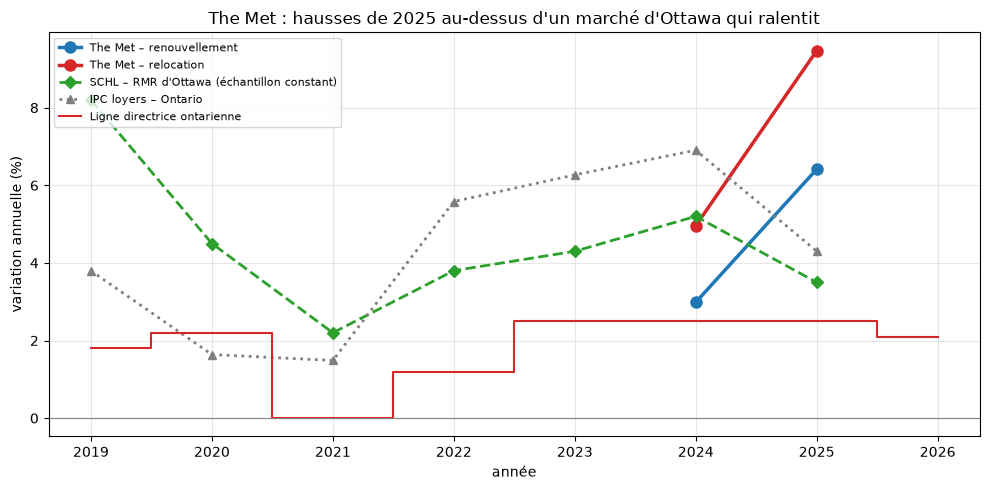

In [49]:
# Figure 13.4 : The Met face au marché d'Ottawa et à la ligne directrice ontarienne.
met_pairs = growth_pairs[~is_quebec]
met_by_type = met_pairs.pivot_table(index="lease_start_year", columns="pair_type", values="contract_growth_pct", aggfunc="median")
ottawa_context = market_reconciliation.loc[:LAST_OBSERVED_YEAR, ["schl_ottawa_cma", "cpi_rent_on", "ontario_guideline", "schl_ottawa_vacancy"]]
print("The Met (médiane contractuelle par type) :"); print(met_by_type.round(2).to_string())
print("\nContexte ontarien :"); print(ottawa_context.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
for pair_type, label in PAIR_TYPE_LABELS.items():
    ax.plot(met_by_type.index, met_by_type[pair_type], "o-", lw=2.5, ms=8, color=PAIR_TYPE_COLORS[pair_type], label=f"The Met – {label}")
ax.plot(ottawa_context.index, ottawa_context.schl_ottawa_cma, "D--", lw=2, color="tab:green", label="SCHL – RMR d'Ottawa (échantillon constant)")
ax.plot(ottawa_context.index, ottawa_context.cpi_rent_on, "^:", lw=2, color="tab:grey", label="IPC loyers – Ontario")
ax.step(market_reconciliation.index, market_reconciliation.ontario_guideline, where="mid", color="tab:red", lw=1.5, label="Ligne directrice ontarienne")
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="The Met : hausses de 2025 au-dessus d'un marché d'Ottawa qui ralentit", xlabel="année", ylabel="variation annuelle (%)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la figure 13.4.**
- **En 2024, The Met est proche du marché d'Ottawa** : ses relocations (5,0 %) correspondent à la SCHL (5,2 %).
- **En 2025, il accélère pendant que le marché ralentit** : 6,4 % en renouvellement et 9,5 % en relocation, contre 3,5 % pour la SCHL et 4,3 % pour l'IPC loyers de l'Ontario, avec une inoccupation remontée à 3,0 %. The Met suit la politique de prix du portefeuille plutôt que son marché local, ce qui est un **risque pour 2026**.
- **Note sur les données** : en 2023, la SCHL publie le même loyer pour les unités vacantes et occupées à Ottawa (1 537 $, différence non significative). La prime de 0 % n'est pas une erreur de lecture.

**Bilan de la section 13.** Trois ancrages publics, connus à la date de prévision, se dégagent :
- le **TAL de l'année** pour les renouvellements québécois : écart nul depuis 2023, et 3,1 % en 2026, reproduit exactement par l'IPC ;
- l'**IPC loyers de l'année précédente** pour les relocations québécoises, dans un marché encore fort et alors que les loyers en place d'Équinoxe ont pris environ 10 points de retard ;
- le **marché ontarien** pour The Met, non plafonné mais exposé au ralentissement d'Ottawa.

Les relations année par année étant trop faibles pour une régression, la section 14 combine ces ancrages par segment.

## 14. Prévision 2026 et backtest

La prévision suit la structure établie aux sections 12 et 13. Elle se fait en **deux étages** :

1. **Hausse contractuelle, par segment**, ancrée sur l'information publique disponible au début de 2026 :

   | Segment | Ancrage | Justification |
   |---|---|---|
   | Québec – renouvellements | Taux du **TAL de l'année cible** (3,1 % en 2026) | Depuis 2023, l'écart moyen avec le TAL est nul (13.4). Le taux est publié en janvier, avant la saison des renouvellements. |
   | Québec – relocations | **IPC loyers du Québec de l'année précédente** | Une relocation se fait au prix du marché, et l'IPC loyers mesure ce marché. L'année précédente est la dernière connue. |
   | The Met (Ontario) | **IPC loyers de l'Ontario de l'année précédente** | L'immeuble est exempté de la ligne directrice (12.4) et suit le marché, sans plafond. On n'applique jamais le TAL à l'Ontario. |

   Les segments sont pondérés par leur part dans les paires de l'année précédente.

2. **Passage à l'effectif** par l'identité exacte de la section 12.2 : `1 + g_eff = (1 + g_contr) × (1 − s_nouveau) / (1 − s_précédent)`. La part en concessions *s* du bail précédent est connue, puisque ce sont les baux de 2025. Celle du nouveau bail fait l'objet d'une **hypothèse explicite, déclinée en scénarios**.

**Règle d'information.** Pour prévoir l'année *T*, la méthode n'utilise que :
- les baux ayant commencé jusqu'en *T − 1* ;
- l'IPC jusqu'en décembre *T − 1* ;
- la SCHL jusqu'à l'enquête d'octobre *T − 1* ;
- les paramètres réglementaires de *T*, publiés avant la saison de renouvellement.

Le backtest applique exactement la même règle à 2023, 2024 et 2025.

### 14.1 Préparation

Chaque paire comparable reçoit son **segment** : renouvellement au Québec, relocation au Québec, ou The Met. On ajoute aussi la part implicite des concessions pour la mesure « loyer seulement », calculée comme en 12.2, pour pouvoir prévoir cette variante avec la même méthode. Cette étape ajoute des colonnes à `growth_pairs`.

In [50]:
# Préparation : segment de chaque paire et part implicite des concessions « loyer seulement » (en plus de celle de 12.2).
QC_RENEWAL, QC_TURNOVER, ONTARIO_SEGMENT = "qc_renewal", "qc_turnover", "ontario"
SEGMENTS = [QC_RENEWAL, QC_TURNOVER, ONTARIO_SEGMENT]
SEGMENT_LABELS = {QC_RENEWAL: "Québec – renouvellements", QC_TURNOVER: "Québec – relocations", ONTARIO_SEGMENT: "The Met (Ontario)"}

growth_pairs["segment"] = np.select(
    [~is_quebec, growth_pairs.is_renewal], [ONTARIO_SEGMENT, QC_RENEWAL], default=QC_TURNOVER)
for prefix in ("", "prev_"):
    growth_pairs[f"{prefix}implied_rent_only_share"] = (
        1 - growth_pairs[f"{prefix}rent_only_effective_rent"] / growth_pairs[f"{prefix}{CONTRACT_RENT_COL}"])
print(pd.crosstab(growth_pairs.lease_start_year, growth_pairs.segment).reindex(columns=SEGMENTS).to_string())

segment           qc_renewal  qc_turnover  ontario
lease_start_year                                  
2019                      89           66        0
2020                     193          128        0
2021                     216          132        0
2022                     217          122        0
2023                     228          169        0
2024                     340          229      108
2025                     399          241      115


### 14.2 Méthode de prévision

`forecast_rent_increase()` applique les deux étages pour une année cible et un scénario de concessions. Trois scénarios sont définis :

| Scénario | Variation de la part en concessions | Lecture |
|---|---|---|
| **haut** : `stabilisation` | 0 point : la part reste au niveau de 2025 | La hausse effective rejoint la hausse contractuelle. |
| **central** : `tendance` | Moyenne des 3 dernières années | La tendance récente se poursuit, sans s'accélérer. |
| **bas** : `poursuite` | Variation de la dernière année | Le saut de 2025 se répète. |

Une année ne compte dans la tendance des concessions que si elle repose sur au moins `MIN_PAIRS_PER_YEAR` paires. Sinon, un petit échantillon peut fausser la tendance d'un immeuble récent.

In [51]:
# Méthode de prévision pour une année cible T, avec la seule information disponible au début de T.
CONCESSION_TREND_WINDOW_YEARS = 3
MIN_PAIRS_PER_YEAR = 30   # une année ne compte (tendance des concessions, groupe rapporté) que si elle repose sur assez de paires
CENTRAL_SCENARIO = "tendance"
CONCESSION_SCENARIOS = {
    # nom -> règle donnant la variation de la part en concessions (points) à partir de l'historique annuel
    "stabilisation": lambda changes: 0.0,                                                   # la part reste au niveau de T-1
    "tendance": lambda changes: changes.tail(CONCESSION_TREND_WINDOW_YEARS).mean(),        # tendance moyenne récente (central)
    "poursuite": lambda changes: changes.iloc[-1],                                          # la hausse de T-1 se répète
}
CONCESSION_SCENARIO_LABELS = {"stabilisation": "haut : concessions stabilisées",
                              "tendance": "central : tendance des 3 dernières années",
                              "poursuite": "bas : la hausse de 2025 se répète"}
MEASURE_SHARE_COLS = {   # mesure -> (part implicite du nouveau bail, part implicite du bail précédent)
    "effective": ("implied_concession_share", "prev_implied_concession_share"),
    "rent_only": ("implied_rent_only_share", "prev_implied_rent_only_share"),
}


def market_anchors(target_year, external):
    # Ancrage contractuel de chaque segment, limité à l'information publiée avant la saison de renouvellement de T.
    info_year = target_year - 1
    return pd.Series({
        QC_RENEWAL: external.loc[target_year, "tal_reference"],   # TAL de T, publié en janvier T (13.3-13.4)
        QC_TURNOVER: external.loc[info_year, "cpi_rent_qc"],       # loyers du marché québécois, année T-1
        ONTARIO_SEGMENT: external.loc[info_year, "cpi_rent_on"],   # The Met : exempté, suit le marché ontarien T-1
    })


def forecast_rent_increase(target_year, pairs_table, external, scenario=CENTRAL_SCENARIO, measure="effective"):
    # 1) hausse contractuelle par segment, pondérée par la composition des paires de T-1 ;
    # 2) passage à la mesure de concessions choisie par l'identité de 12.2, avec l'hypothèse de concessions du scénario.
    info_year = target_year - 1
    history = pairs_table[pairs_table.lease_start_year <= info_year]
    last_year = history[history.lease_start_year == info_year]

    segment_weights = last_year.segment.value_counts(normalize=True).reindex(SEGMENTS, fill_value=0)
    anchors = market_anchors(target_year, external)
    contract_pct = (segment_weights * anchors).sum()

    new_share_col, prev_share_col = MEASURE_SHARE_COLS[measure]
    previous_share = last_year[new_share_col].mean()             # baux de T-1 = baux précédents des paires de T
    by_year = history.groupby("lease_start_year")
    share_changes = (by_year[new_share_col].mean() - by_year[prev_share_col].mean())[by_year.size() >= MIN_PAIRS_PER_YEAR]
    share_change = CONCESSION_SCENARIOS[scenario](share_changes)
    net_pct = ((1 + contract_pct / TO_PERCENT) * (1 - (previous_share + share_change)) / (1 - previous_share) - 1) * TO_PERCENT
    return {"target_year": target_year, "scenario": scenario, "measure": measure,
            "contract_pct": contract_pct, f"{measure}_pct": net_pct,
            "previous_concession_share_pct": previous_share * TO_PERCENT, "share_change_pts": share_change * TO_PERCENT,
            **{f"weight_{s}": segment_weights[s] for s in SEGMENTS}, **{f"anchor_{s}": anchors[s] for s in SEGMENTS}}

### 14.3 Fonctions demandées : `estimate_2026()` et `backtest()`

Le gabarit de départ est complété ici. `estimate_2026()` renvoie la hausse 2026 au sens de la section 8, et vérifie au passage qu'aucune donnée n'est postérieure à la date de prévision. `backtest()` applique la méthode comme si l'on était à la fin de l'année précédant l'année cible, puis la compare avec la hausse réellement observée.

La table `asking` n'entre pas dans le calcul, et c'est un choix assumé. Elle précède chaque bail de 0 à 4 mois, avec un loyer signé d'environ 98 % du loyer affiché (9.4), et ne contient aucun affichage pour un bail de 2026. Elle n'apporte donc aucune information sur 2026 que les baux n'apportent déjà.

In [52]:
# Gabarit de départ complété : estimate_2026() et backtest().
# Les tables brutes `leases` et `asking` servent à vérifier qu'aucune donnée n'est postérieure à la date de prévision ;
# le calcul s'appuie sur les tables de travail construites à partir d'elles (sections 9 à 13).
# `asking` n'entre pas dans le calcul : il précède chaque bail de 0 à 4 mois et ne contient aucun affichage pour 2026 (9.4).


def estimate_2026(leases, asking, external=None, scenario=CENTRAL_SCENARIO, measure="effective"):
    """Hausse 2026 du loyer effectif à unité constante, en % (définition de la section 8)."""
    forecast_start = pd.Timestamp(year=FORECAST_YEAR, month=1, day=1)
    if leases.sLeaseFrom.max() >= forecast_start or asking.date.max() >= forecast_start:
        raise ValueError("Données postérieures à la date de prévision")
    external = market_reconciliation if external is None else external
    return forecast_rent_increase(FORECAST_YEAR, growth_pairs, external, scenario, measure)[f"{measure}_pct"]


def backtest(leases, target_year, external=None, scenario=CENTRAL_SCENARIO, measure="effective"):
    """Applique la méthode comme à la fin de target_year - 1, puis compare avec la hausse réellement observée en target_year."""
    external = market_reconciliation if external is None else external
    forecast = forecast_rent_increase(target_year, growth_pairs, external, scenario, measure)
    actual_col = {"effective": "effective_median_pct", "rent_only": "rent_only_median_pct"}[measure]
    actual = same_unit_growth.loc[target_year, actual_col]
    return {"target_year": target_year, "predicted_pct": forecast[f"{measure}_pct"], "actual_pct": actual,
            "error_pts": forecast[f"{measure}_pct"] - actual,
            "predicted_contract_pct": forecast["contract_pct"],
            "actual_contract_pct": same_unit_growth.loc[target_year, "contract_median_pct"]}


BACKTEST_YEARS = [FORECAST_YEAR - 3, FORECAST_YEAR - 2, FORECAST_YEAR - 1]   # 2023, 2024, 2025
for year in BACKTEST_YEARS:
    result = backtest(leases, year)
    print(year, {key: round(value, 2) for key, value in result.items() if key != "target_year"})

2023 {'predicted_pct': np.float64(2.2), 'actual_pct': np.float64(2.08), 'error_pts': np.float64(0.12), 'predicted_contract_pct': np.float64(2.77), 'actual_contract_pct': np.float64(2.33)}
2024 {'predicted_pct': np.float64(4.32), 'actual_pct': np.float64(1.86), 'error_pts': np.float64(2.46), 'predicted_contract_pct': np.float64(4.8), 'actual_contract_pct': np.float64(3.49)}
2025 {'predicted_pct': np.float64(6.12), 'actual_pct': np.float64(3.71), 'error_pts': np.float64(2.41), 'predicted_contract_pct': np.float64(7.07), 'actual_contract_pct': np.float64(7.18)}


### 14.4 Backtest sur 2023, 2024 et 2025

On compare la méthode retenue à quatre méthodes de référence, toutes limitées à l'information disponible à la fin de *T − 1* :

| Méthode de référence | Prévision |
|---|---|
| persistance | la hausse à unité constante de l'année précédente |
| moyenne sur 3 ans | la moyenne des hausses à unité constante des trois années précédentes |
| médiane naïve | la variation de la médiane de tous les baux l'année précédente (section 3) |
| marché seul | la variation à échantillon constant de la SCHL pour Montréal l'année précédente |

On évalue la **mesure effective**, qui est la réponse, et la **mesure contractuelle**, pour juger chaque étage séparément.

In [53]:
# Backtest complet : méthode retenue vs méthodes de référence simples, pour la mesure effective et la mesure contractuelle.
naive_median_change = (leases.groupby("year").sRent.median().pct_change() * TO_PERCENT)   # médiane naïve (section 3)


def reference_forecasts(target_year, series):
    # Méthodes de référence n'utilisant que l'historique interne jusqu'à T-1.
    past = series.loc[:target_year - 1]
    return {"persistance (T-1)": past.iloc[-1],
            "moyenne 3 ans": past.tail(CONCESSION_TREND_WINDOW_YEARS).mean()}


backtest_rows = []
for year in BACKTEST_YEARS:
    result = backtest(leases, year)
    for measure, predicted, actual, series in [
            ("effectif", result["predicted_pct"], result["actual_pct"], same_unit_growth.effective_median_pct),
            ("contractuel", result["predicted_contract_pct"], result["actual_contract_pct"], same_unit_growth.contract_median_pct)]:
        row = {"mesure": measure, "année": year, "observé": actual, "méthode retenue": predicted,
               **reference_forecasts(year, series),
               "médiane naïve (T-1)": naive_median_change.loc[year - 1],
               "SCHL Montréal (T-1)": market_reconciliation.loc[year - 1, "schl_montreal_cma"]}
        backtest_rows.append(row)
backtest_table = pd.DataFrame(backtest_rows).set_index(["mesure", "année"])

METHOD_COLS = ["méthode retenue", "persistance (T-1)", "moyenne 3 ans", "médiane naïve (T-1)", "SCHL Montréal (T-1)"]
backtest_errors = backtest_table[METHOD_COLS].sub(backtest_table["observé"], axis=0)
mean_absolute_error = backtest_errors.abs().groupby(level="mesure").mean()
print("Prévisions et valeurs observées (%) :"); print(backtest_table.round(2).to_string())
print("\nErreur absolue moyenne sur 2023-2025 (points) :"); print(mean_absolute_error.round(2).to_string())

Prévisions et valeurs observées (%) :
                   observé  méthode retenue  persistance (T-1)  moyenne 3 ans  médiane naïve (T-1)  SCHL Montréal (T-1)
mesure      année                                                                                                      
effectif    2023      2.08             2.20               4.72           3.83                 3.38                  5.1
contractuel 2023      2.33             2.77               5.64           4.51                 3.38                  5.1
effectif    2024      1.86             4.32               2.08           3.48                10.85                  7.7
contractuel 2024      3.49             4.80               2.33           4.19                10.85                  7.7
effectif    2025      3.71             6.12               1.86           2.89                 4.48                  6.4
contractuel 2025      7.18             7.07               3.49           3.82                 4.48                  6.4

E

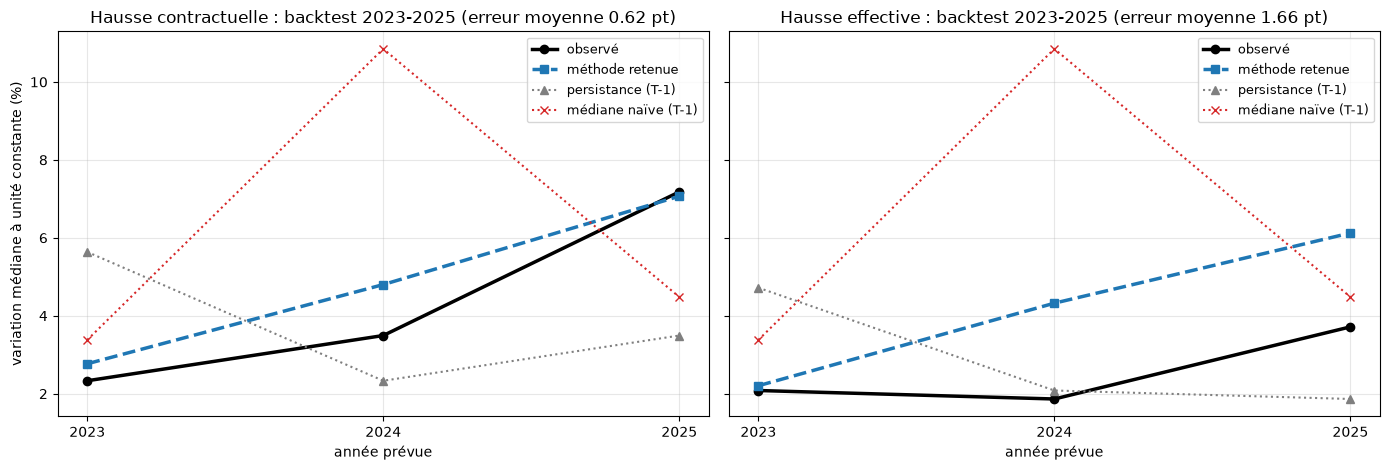

In [54]:
# Figure 14.1 : backtest – prévisions de la méthode retenue vs valeurs observées, pour les deux étages.
BACKTEST_TITLES = {"contractuel": "Hausse contractuelle", "effectif": "Hausse effective"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, measure in zip(axes, ["contractuel", "effectif"]):
    table = backtest_table.xs(measure, level="mesure")
    ax.plot(table.index, table["observé"], "o-", lw=2.5, color="black", label="observé")
    ax.plot(table.index, table["méthode retenue"], "s--", lw=2.5, color="tab:blue", label="méthode retenue")
    ax.plot(table.index, table["persistance (T-1)"], "^:", lw=1.5, color="tab:grey", label="persistance (T-1)")
    ax.plot(table.index, table["médiane naïve (T-1)"], "x:", lw=1.5, color="tab:red", label="médiane naïve (T-1)")
    mae = mean_absolute_error.loc[measure, "méthode retenue"]
    ax.set(title=f"{BACKTEST_TITLES[measure]} : backtest 2023-2025 (erreur moyenne {mae:.2f} pt)",
           xlabel="année prévue", xticks=BACKTEST_YEARS)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
axes[0].set_ylabel("variation médiane à unité constante (%)")
plt.tight_layout()
plt.show()

Pour comprendre d'où vient l'erreur, on sépare deux sources. **L'erreur d'agrégation** est celle qu'aurait la méthode si on lui donnait les vraies valeurs de l'année cible (médianes par segment, poids, concessions). **L'erreur de concessions** compare la variation de la part en concessions prévue à celle observée. On compare enfin les trois règles de concessions.

In [55]:
# Diagnostic : d'où viennent les erreurs de l'étage effectif ?
# (a) Erreur d'agrégation : la méthode alimentée par les VRAIES valeurs de T (médianes par segment, poids, concessions).
# (b) Erreur de concessions : la variation de la part en concessions prévue vs observée.
diagnostic_rows = []
for year in BACKTEST_YEARS:
    current = growth_pairs[growth_pairs.lease_start_year == year]
    true_weights = current.segment.value_counts(normalize=True).reindex(SEGMENTS, fill_value=0)
    true_segment_medians = current.groupby("segment").contract_growth_pct.median().reindex(SEGMENTS).fillna(0)
    oracle_contract = (true_weights * true_segment_medians).sum()
    previous_share = current.prev_implied_concession_share.mean()
    true_change = current.implied_concession_share.mean() - previous_share
    oracle_effective = ((1 + oracle_contract / TO_PERCENT) * (1 - previous_share - true_change) / (1 - previous_share) - 1) * TO_PERCENT
    forecast = forecast_rent_increase(year, growth_pairs, market_reconciliation)
    diagnostic_rows.append({
        "année": year,
        "contractuel : erreur d'agrégation (pts)": oracle_contract - same_unit_growth.loc[year, "contract_median_pct"],
        "effectif : erreur d'agrégation (pts)": oracle_effective - same_unit_growth.loc[year, "effective_median_pct"],
        "concessions : variation prévue (pts)": forecast["share_change_pts"],
        "concessions : variation observée (pts)": true_change * TO_PERCENT,
    })
print(pd.DataFrame(diagnostic_rows).set_index("année").round(2).to_string())

# Erreur absolue moyenne de chaque règle de concessions sur 2023-2025 (étage contractuel identique).
scenario_errors = pd.DataFrame({
    scenario: [forecast_rent_increase(year, growth_pairs, market_reconciliation, scenario)["effective_pct"]
               - same_unit_growth.loc[year, "effective_median_pct"] for year in BACKTEST_YEARS]
    for scenario in CONCESSION_SCENARIOS}, index=BACKTEST_YEARS)
print("\nErreur de la mesure effective selon la règle de concessions (points) :")
print(scenario_errors.round(2).to_string())
print("Erreur absolue moyenne :", scenario_errors.abs().mean().round(2).to_dict())

       contractuel : erreur d'agrégation (pts)  effectif : erreur d'agrégation (pts)  concessions : variation prévue (pts)  concessions : variation observée (pts)
année                                                                                                                                                             
2023                                     -0.06                                  0.15                                  0.53                                    0.04
2024                                      0.27                                 -0.07                                  0.44                                    1.83
2025                                      0.33                                 -0.20                                  0.83                                    3.50

Erreur de la mesure effective selon la règle de concessions (points) :
      stabilisation  tendance  poursuite
2023           0.69      0.12       0.01
2024           2.94      2.46  

**Lecture du backtest.**
- **L'étage contractuel est fortement validé** : 0,62 point d'erreur moyenne, contre 2,1 à 3,7 points pour toutes les méthodes de référence (7,1 % prévu pour 7,2 % observé en 2025). Les ancrages publics captent ce qu'aucune méthode purement interne ne capte. La médiane naïve est la pire méthode : en 2024, elle aurait annoncé 10,9 %.
- **L'étage effectif fait à peine moins bien que les références internes** (1,66 point, contre 1,40 et 1,57). L'erreur d'agrégation est négligeable (0,3 point au plus) : **toute l'erreur vient des concessions**, qui ont bondi de 1,8 et 3,5 points en 2024 et 2025, alors que leur tendance annonçait environ 0,4 et 0,8 point. Ce sont des décisions commerciales, imprévisibles à partir de l'historique. Les références internes font un peu mieux seulement parce que la hausse effective est restée basse de 2023 à 2025.
- **La règle `poursuite` a une erreur un peu plus faible** (1,40 contre 1,66), mais on ne la retient pas comme scénario central : choisir sur trois points serait du surajustement, et elle suppose des concessions qui s'accélèrent sans fin. Elle sert de scénario bas.

### 14.5 Prévision 2026

On applique la méthode à 2026 pour les trois scénarios de concessions, puis à la variante « loyer seulement ». On mesure aussi la **précision de la mesure elle-même** : un rééchantillonnage des paires de 2025 (bootstrap) indique de combien la médiane observée pourrait varier par le seul hasard de l'échantillon.

In [56]:
# Prévision 2026 : scénarios de concessions, variante « loyer seulement » et incertitude d'échantillonnage.
BOOTSTRAP_SAMPLES = 2000
BOOTSTRAP_SEED = 2026
INTERVAL_QUANTILES = [0.05, 0.95]

forecast_2026 = pd.DataFrame([forecast_rent_increase(FORECAST_YEAR, growth_pairs, market_reconciliation, scenario)
                              for scenario in CONCESSION_SCENARIOS]).set_index("scenario")
forecast_2026["libellé"] = forecast_2026.index.map(CONCESSION_SCENARIO_LABELS)
rent_only_2026 = forecast_rent_increase(FORECAST_YEAR, growth_pairs, market_reconciliation, CENTRAL_SCENARIO, "rent_only")
central_2026 = estimate_2026(leases, asking)

# Incertitude d'échantillonnage : rééchantillonnage des paires de 2025 (précision de la mesure elle-même).
rng = np.random.default_rng(BOOTSTRAP_SEED)
pairs_2025 = growth_pairs.loc[growth_pairs.lease_start_year == LAST_OBSERVED_YEAR, "effective_growth_pct"].to_numpy()
bootstrap_medians = np.median(rng.choice(pairs_2025, size=(BOOTSTRAP_SAMPLES, len(pairs_2025)), replace=True), axis=1)
sampling_interval = np.quantile(bootstrap_medians, INTERVAL_QUANTILES)

print(forecast_2026[["libellé", "contract_pct", "effective_pct", "previous_concession_share_pct", "share_change_pts"]].round(2).to_string())
print(f"\nPondération des segments (paires de 2025) : " + ", ".join(f"{SEGMENT_LABELS[s]} {forecast_2026.loc[CENTRAL_SCENARIO, f'weight_{s}']:.0%}" for s in SEGMENTS))
print("Ancrages contractuels 2026 : " + ", ".join(f"{SEGMENT_LABELS[s]} {forecast_2026.loc[CENTRAL_SCENARIO, f'anchor_{s}']:.2f} %" for s in SEGMENTS))
print(f"\nestimate_2026() – hausse 2026 du loyer effectif à unité constante (central) : {central_2026:.2f} %")
print(f"Variante « loyer seulement » (central) : {rent_only_2026['rent_only_pct']:.2f} % | hausse contractuelle : {rent_only_2026['contract_pct']:.2f} %")
print(f"Précision de la mesure (médiane effective 2025, intervalle bootstrap 90 %) : "
      f"{sampling_interval[0]:.2f} % à {sampling_interval[1]:.2f} %, autour de {np.median(pairs_2025):.2f} %")

                                                 libellé  contract_pct  effective_pct  previous_concession_share_pct  share_change_pts
scenario                                                                                                                              
stabilisation             haut : concessions stabilisées          4.77           4.77                           9.28              0.00
tendance       central : tendance des 3 dernières années          4.77           2.70                           9.28              1.79
poursuite              bas : la hausse de 2025 se répète          4.77           0.72                           9.28              3.50

Pondération des segments (paires de 2025) : Québec – renouvellements 53%, Québec – relocations 32%, The Met (Ontario) 15%
Ancrages contractuels 2026 : Québec – renouvellements 3.10 %, Québec – relocations 7.75 %, The Met (Ontario) 4.30 %

estimate_2026() – hausse 2026 du loyer effectif à unité constante (central) : 2.70 %


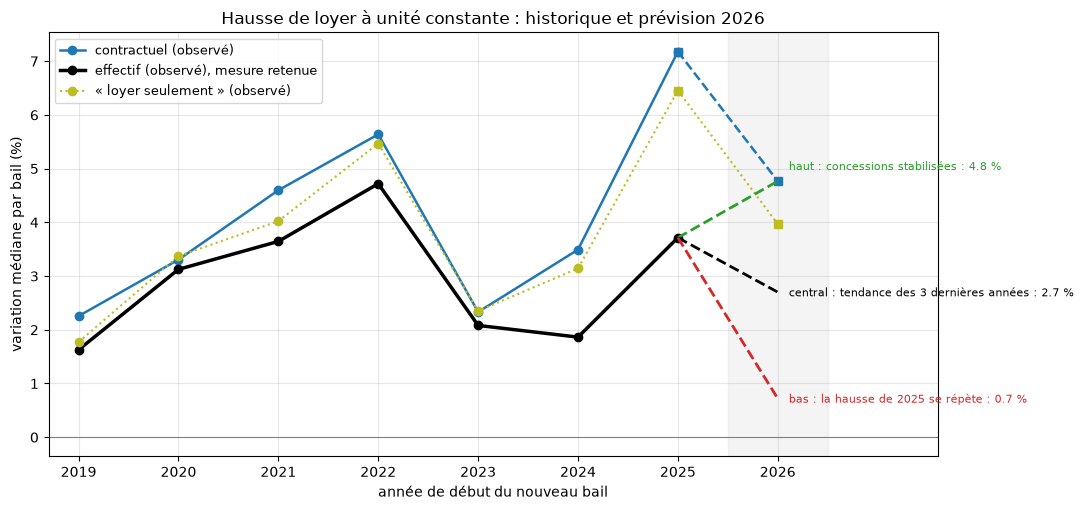

In [57]:
# Figure 14.2 : historique et prévision 2026 (scénarios), pour les mesures effective, contractuelle et « loyer seulement ».
SCENARIO_COLORS = {"stabilisation": "tab:green", "tendance": "black", "poursuite": "tab:red"}
ANNOTATION_OFFSETS = {"stabilisation": (8, 8), "tendance": (8, -3), "poursuite": (8, -3)}   # décalage des étiquettes (points)
fig, ax = plt.subplots(figsize=(11, 5.2))
history_years = same_unit_growth.index
ax.plot(history_years, same_unit_growth.contract_median_pct, "o-", color="tab:blue", lw=1.8, label="contractuel (observé)")
ax.plot(history_years, same_unit_growth.effective_median_pct, "o-", color="black", lw=2.5, label="effectif (observé), mesure retenue")
ax.plot(history_years, same_unit_growth.rent_only_median_pct, "o:", color="tab:olive", lw=1.5, label="« loyer seulement » (observé)")
ax.plot([LAST_OBSERVED_YEAR, FORECAST_YEAR], [same_unit_growth.contract_median_pct.iloc[-1], forecast_2026.loc[CENTRAL_SCENARIO, "contract_pct"]],
        "s--", color="tab:blue", lw=1.8)
ax.plot([LAST_OBSERVED_YEAR, FORECAST_YEAR], [same_unit_growth.rent_only_median_pct.iloc[-1], rent_only_2026["rent_only_pct"]],
        "s:", color="tab:olive", lw=1.5)
for scenario, color in SCENARIO_COLORS.items():
    value = forecast_2026.loc[scenario, "effective_pct"]
    ax.plot([LAST_OBSERVED_YEAR, FORECAST_YEAR], [same_unit_growth.effective_median_pct.iloc[-1], value], "--", color=color, lw=2)
    ax.annotate(f"{CONCESSION_SCENARIO_LABELS[scenario]} : {value:.1f} %", (FORECAST_YEAR, value),
                textcoords="offset points", xytext=ANNOTATION_OFFSETS[scenario], fontsize=8, color=color)
ax.axvspan(LAST_OBSERVED_YEAR + 0.5, FORECAST_YEAR + 0.5, color="tab:grey", alpha=0.08)
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Hausse de loyer à unité constante : historique et prévision 2026", xlabel="année de début du nouveau bail",
       ylabel="variation médiane par bail (%)", xlim=(FIRST_ANALYSIS_YEAR - 0.3, FORECAST_YEAR + 1.6))
ax.set_xticks([*history_years, FORECAST_YEAR])
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la prévision 2026.**
- **Hausse contractuelle : environ 4,8 %**, soit 53 % de renouvellements québécois au TAL (3,1 %), 32 % de relocations québécoises à l'IPC loyers du Québec de 2025 (7,7 %) et 15 % pour The Met à l'IPC loyers de l'Ontario de 2025 (4,3 %).
- **Hausse effective, scénario central : environ 2,7 %**, avec une part en concessions qui passerait d'environ 9,3 % à 11,1 % du loyer. La fourchette va de 0,7 % (le saut de 2025 se répète) à 4,8 % (concessions stabilisées) : c'est la principale incertitude, et elle dépend de la politique commerciale d'Équinoxe.
- **La variante « loyer seulement » donne environ 4,0 %**, plus proche du contractuel puisque ce sont surtout les accessoires qui ont augmenté (12.6).
- **La mesure elle-même est précise** (intervalle bootstrap à 90 % d'environ ±0,2 point), et le scénario central se situe entre les deux références internes (3,7 % et 2,6 %).

### 14.6 Prévision par immeuble et par nombre de chambres

La même méthode est appliquée à chaque groupe. Le poids des segments, la part en concessions et sa tendance sont propres au groupe, et les ancrages sont ceux de sa province. Seuls les groupes d'au moins `MIN_PAIRS_PER_YEAR` paires en 2025 sont rapportés ; les 3 chambres et plus n'en ont pas assez. La figure 14.3 sert de petit tableau de bord par immeuble.

In [58]:
# Prévision 2026 par immeuble et par nombre de chambres (bonus) : même méthode, appliquée à chaque groupe.
# Poids des segments, part en concessions et tendance des concessions sont propres au groupe ; les ancrages sont ceux de sa province.

def forecast_by_group(group_col):
    rows = []
    for group, group_pairs in growth_pairs.groupby(group_col):
        last_year_count = (group_pairs.lease_start_year == LAST_OBSERVED_YEAR).sum()
        if last_year_count < MIN_PAIRS_PER_YEAR:
            continue
        row = {group_col: group, "paires 2025": last_year_count,
               "observé 2025 – effectif": group_pairs.loc[group_pairs.lease_start_year == LAST_OBSERVED_YEAR, "effective_growth_pct"].median()}
        for scenario in CONCESSION_SCENARIOS:
            forecast = forecast_rent_increase(FORECAST_YEAR, group_pairs, market_reconciliation, scenario)
            row[f"2026 – {scenario}"] = forecast["effective_pct"]
        row["2026 – contractuel"] = forecast["contract_pct"]
        rows.append(row)
    return pd.DataFrame(rows).set_index(group_col)


forecast_by_building = forecast_by_group("building").reindex([b for b in BUILDING_ORDER if b in growth_pairs.building.unique()])
forecast_by_bedrooms = forecast_by_group("bedrooms")
print("Par immeuble (%) :"); print(forecast_by_building.round(2).to_string())
print("\nPar nombre de chambres (%) :"); print(forecast_by_bedrooms.round(2).to_string())

Par immeuble (%) :
                paires 2025  observé 2025 – effectif  2026 – stabilisation  2026 – tendance  2026 – poursuite  2026 – contractuel
building                                                                                                                         
Saint-Elzear            144                     4.19                  4.71             3.00              1.38                4.71
Levesque                 74                     3.40                  4.92             2.84              0.43                4.92
Daniel-Johnson          126                     3.92                  5.09             3.02              1.50                5.09
Le Carlyle              171                     3.57                  4.76             1.26              0.43                4.76
The Met                 115                     3.39                  4.30             0.96             -0.40                4.30
Westpark                125                     3.78                  4

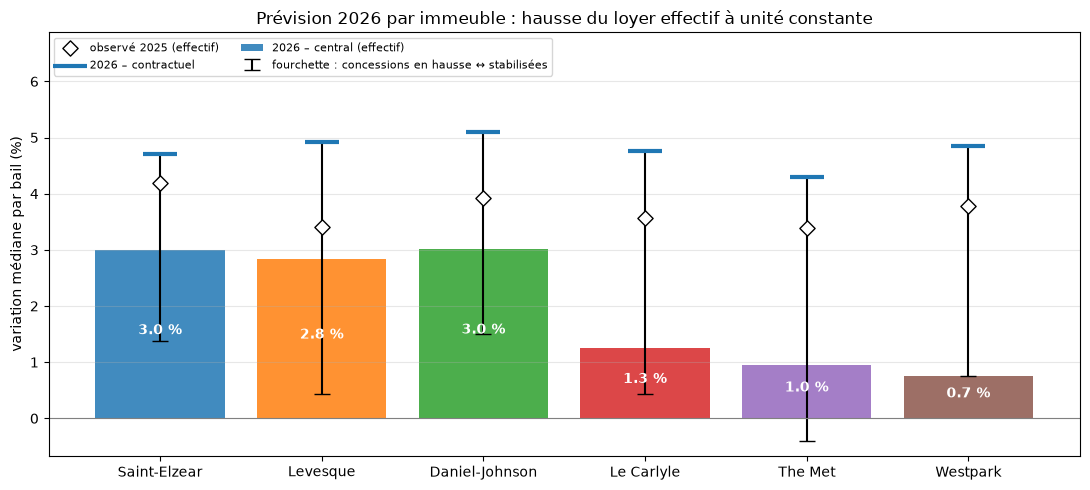

In [59]:
# Figure 14.3 : tableau de bord de la prévision 2026 par immeuble (central et fourchette des scénarios de concessions).
fig, ax = plt.subplots(figsize=(11, 5))
positions = np.arange(len(forecast_by_building))
low, central, high = (forecast_by_building[f"2026 – {s}"] for s in ("poursuite", "tendance", "stabilisation"))
ax.bar(positions, central, color=[BUILDING_COLORS[b] for b in forecast_by_building.index], alpha=0.85, label="2026 – central (effectif)")
ax.errorbar(positions, central, yerr=[central - low, high - central], fmt="none", ecolor="black", capsize=6, lw=1.5,
            label="fourchette : concessions en hausse ↔ stabilisées")
ax.scatter(positions, forecast_by_building["observé 2025 – effectif"], marker="D", color="white", edgecolor="black", zorder=3, s=60,
           label="observé 2025 (effectif)")
ax.scatter(positions, forecast_by_building["2026 – contractuel"], marker="_", color="tab:blue", s=600, lw=3, zorder=3,
           label="2026 – contractuel")
for position, value in zip(positions, central):
    ax.text(position, value / 2, f"{value:.1f} %", ha="center", color="white", fontsize=10, fontweight="bold")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(positions)
ax.set_xticklabels(forecast_by_building.index)
ax.set(title="Prévision 2026 par immeuble : hausse du loyer effectif à unité constante", ylabel="variation médiane par bail (%)")
DASHBOARD_HEADROOM_FACTOR = 1.35   # marge pour la légende au-dessus des barres
ax.set_ylim(top=high.max() * DASHBOARD_HEADROOM_FACTOR)
ax.legend(fontsize=8, loc="upper left", ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture du tableau de bord.**
- **Les trois immeubles de Laval se ressemblent** : environ 2,8 % à 3,0 % en scénario central, leurs concessions progressant moins vite.
- **Les immeubles récents sont nettement plus bas** : environ 1,3 % pour Le Carlyle, 1,0 % pour The Met et 0,7 % pour Westpark, leur part en concessions ayant augmenté de 3,5 à 4 points en 2025. Pour Westpark, la tendance repose sur la seule année 2025 (2024 n'avait que 7 paires). The Met cumule ces concessions et un marché d'Ottawa qui ralentit.
- **Par nombre de chambres**, les 1 et 2 chambres sont proches de la moyenne (environ 2,7 % à 2,8 %), et les studios plus bas (environ 1,3 %, petit échantillon).

Ces prévisions par groupe sont plus fragiles que la prévision globale : elles servent à repérer où se concentre le risque, pas à budgéter immeuble par immeuble.

### 14.7 Hypothèses et limites

**Hypothèses**, en plus des ancrages par segment présentés au début de la section :
1. **TAL 2026** : c'est la première année de la nouvelle méthode, et les renouvellements de début d'année dont l'avis a été donné avant le 1er janvier 2026 relèvent encore de l'ancienne.
2. **Composition** : les segments pèsent en 2026 comme en 2025 (53 % / 32 % / 15 %).
3. **Concessions** : leur part progresse au rythme moyen des trois dernières années, accessoires compris (section 8).
4. **Périmètre** : seules les unités ayant un bail précédent de 12 mois comptent ; les nouvelles unités (`stelz3`) n'influencent pas la hausse.

**Limites :**
- Trois années de backtest : l'étage contractuel est nettement validé, mais les règles de concessions ne peuvent pas être départagées finement.
- La médiane globale est approchée par la moyenne pondérée des segments (erreur d'agrégation sous 0,35 point).
- **La hausse effective dépend d'abord de la politique de concessions d'Équinoxe** : la prévision est conditionnelle à cette décision, et les scénarios en donnent directement la conséquence.

## Estimation finale

> **Hausse de loyer 2026 de Collection Équinoxe : 2,7 %** (scénario central).
>
> **Définition (section 8)** : croissance médiane du **loyer effectif** (`sRentEffective`, concessions accessoires comprises), à **unité constante**. Chaque bail débutant en 2026 est comparé au bail précédent de 12 mois de la même unité (`sPropCode` + `sUnitCode`).

| Mesure 2026 | Bas | **Central** | Haut |
|---|---|---|---|
| Loyer effectif (réponse) | 0,7 % | **2,7 %** | 4,8 % |
| Loyer contractuel | — | 4,8 % | — |
| Loyer effectif « loyer seulement » (scénario alternatif) | — | 4,0 % | — |

Le bas, le central et le haut correspondent respectivement à des concessions en hausse au rythme de 2025, à la tendance des trois dernières années, et à des concessions stabilisées. Backtest 2023-2025 : erreur moyenne de 0,62 point sur l'étage contractuel et de 1,66 point sur l'étage effectif.

## Références

**Données**
- Collection Équinoxe : extrait du CRM Yardi fourni par la Corporation JADCO pour CodeML 2026. Données confidentielles, non redistribuées.
- SCHL, *Enquête sur les logements locatifs*, tableaux de données des rapports sur le marché locatif, RMR de Montréal et d'Ottawa, enquêtes 2019 à 2025. https://www.cmhc-schl.gc.ca
- Statistique Canada, tableau 18-10-0004-01, *Indice des prix à la consommation mensuel, non désaisonnalisé*. https://www150.statcan.gc.ca/t1/tbl1/fr/tv.action?pid=1810000401
- Tribunal administratif du logement, paramètres annuels de fixation de loyer. https://www.tal.gouv.qc.ca
- Gouvernement de l'Ontario, *Rent increase guideline*. https://www.ontario.ca/page/rent-increase-guideline

La source précise de chaque taux du TAL et de chaque ligne directrice ontarienne (communiqué officiel ou source secondaire) figure dans `data/external_regulatory_parameters.csv` (section 13.3).

**Outils d'IA**
- Claude (Anthropic), modèle Claude Opus 5.5, via claude.ai. Utilisé comme assistant tout au long du projet : exploration des données, rédaction et vérification du code, recherche et citation des paramètres réglementaires, rédaction des cellules Markdown. Les choix de méthode ont été discutés et validés par l'équipe, et chaque résultat a été vérifié par l'exécution du notebook.

## Ce qui rapporte des points

La méthode avant la proximité du résultat. Une équipe qui énonce sa définition, associe les mêmes unités sur
la bonne clé, traite les concessions explicitement et tombe un peu à côté
obtiendra une meilleure note qu'une équipe qui tombe plus près en faisant la moyenne de quelque chose qu'elle n'a jamais
examiné.

Plus précisément, rapportent des points :

- Nommer la définition à laquelle vous répondez
- Comparer les mêmes unités plutôt que des médianes d'une année à l'autre
- Repérer et expliquer le problème de composition
- Utiliser `sRentEffective`, ou justifier pourquoi vous avez utilisé le loyer contractuel
- Séparer les renouvellements des relocations
- Concilier les données de marché externes avec la tendance interne
- Valider votre propre méthode sur l'historique (backtest)

## Ce qui fait perdre des points :

- Les nombres magiques et les variables mal nommées. Restez cohérent dans votre logique de nommage.
- Utiliser `sSite` + `sUnitCode` comme clé pour comparer les mêmes unités
- Une mauvaise utilisation des variables (features).
- Citer un taux d'occupation, d'inoccupation ou d'absorption tiré de cet extrait
- Aucune cellule markdown

### Ce qui donne des points bonus :

- Traiter l'immeuble The Met selon les règles de l'Ontario.